In [1]:
from pathlib import Path
import zipfile
import requests
import re
from urllib.parse import urljoin

In [2]:
PROJECT_ROOT = Path(".").resolve()
DATASET_ROOT = PROJECT_ROOT / "DsPCBSD+"
ZIP_PATH = PROJECT_ROOT / "DsPCBSD+.zip"

EXPECTED_PATHS = [
    DATASET_ROOT,
    DATASET_ROOT / "Data_COCO",
    DATASET_ROOT / "Data_COCO" / "annotations",
    DATASET_ROOT / "Data_COCO" / "annotations" / "instances_train2017.json",
    DATASET_ROOT / "Data_COCO" / "annotations" / "instances_val2017.json",
    DATASET_ROOT / "Data_COCO" / "train2017",
    DATASET_ROOT / "Data_COCO" / "val2017",
    DATASET_ROOT / "Data_YOLO",
    DATASET_ROOT / "Data_YOLO" / "images",
    DATASET_ROOT / "Data_YOLO" / "images" / "train",
    DATASET_ROOT / "Data_YOLO" / "images" / "val",
    DATASET_ROOT / "Data_YOLO" / "labels",
    DATASET_ROOT / "Data_YOLO" / "labels" / "train",
    DATASET_ROOT / "Data_YOLO" / "labels" / "val",
]

def dataset_is_ready():
    return all(p.exists() for p in EXPECTED_PATHS)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_ROOT:", DATASET_ROOT)
print("ZIP_PATH    :", ZIP_PATH)
print("Dataset ready?", dataset_is_ready())

PROJECT_ROOT: /root/AIDL
DATASET_ROOT: /root/AIDL/DsPCBSD+
ZIP_PATH    : /root/AIDL/DsPCBSD+.zip
Dataset ready? True


In [3]:
ZIP_FILE_ID = "1cqVe2_kmvthP8I0OxsJdicq1ljBqSkRu"

In [4]:
def _save_response_content(response, destination: Path, chunk_size: int = 32768):
    with open(destination, "wb") as f:
        for chunk in response.iter_content(chunk_size):
            if chunk:
                f.write(chunk)

def _extract_warning_form(html: str):
    """
    从 Google Drive 的 virus scan warning 页面提取表单 action 和 hidden inputs
    """
    form_match = re.search(r'<form[^>]*id="download-form"[^>]*action="([^"]+)"', html)
    if not form_match:
        return None, None

    action = form_match.group(1)
    inputs = dict(re.findall(r'<input[^>]*name="([^"]+)"[^>]*value="([^"]*)"', html))
    return action, inputs

def download_drive_file(file_id: str, destination: Path):
    session = requests.Session()

    # 第一次请求
    initial_url = "https://drive.google.com/uc"
    response = session.get(
        initial_url,
        params={"export": "download", "id": file_id},
        stream=True
    )

    content_type = response.headers.get("Content-Type", "")

    # 情况1：直接返回二进制文件流
    if "text/html" not in content_type.lower():
        _save_response_content(response, destination)
        return

    # 情况2：返回 HTML 页面，可能是 virus scan warning
    html = response.text

    if "Virus scan warning" in html or 'id="download-form"' in html:
        action, inputs = _extract_warning_form(html)
        if not action:
            raise RuntimeError(
                "Detected Google Drive warning page, but failed to parse the download form."
            )

        download_url = urljoin("https://drive.google.com", action)

        confirm_response = session.get(download_url, params=inputs, stream=True)
        confirm_content_type = confirm_response.headers.get("Content-Type", "")

        if "text/html" in confirm_content_type.lower():
            preview = confirm_response.text[:800]
            raise RuntimeError(
                "Google Drive still returned an HTML page after warning confirmation.\n"
                f"Content-Type: {confirm_content_type}\n"
                f"Response preview:\n{preview}"
            )

        _save_response_content(confirm_response, destination)
        return

    # 其他 HTML 页面
    preview = html[:800]
    raise RuntimeError(
        "Google Drive did not return a downloadable file stream.\n"
        "This is not the standard virus warning page.\n"
        f"Content-Type: {content_type}\n"
        f"Response preview:\n{preview}"
    )

In [5]:
def download_zip_if_needed():
    if dataset_is_ready():
        print("Dataset already exists locally. Skip zip download.")
        return

    if ZIP_PATH.exists() and ZIP_PATH.stat().st_size > 0:
        print(f"Zip already exists locally: {ZIP_PATH}")
        print("Zip size (MB):", round(ZIP_PATH.stat().st_size / (1024 * 1024), 2))
        return

    print("Downloading zip from Google Drive...")
    download_drive_file(ZIP_FILE_ID, ZIP_PATH)

    if not ZIP_PATH.exists() or ZIP_PATH.stat().st_size == 0:
        raise FileNotFoundError(f"Zip download failed: {ZIP_PATH} was not created correctly.")

    print("Zip downloaded successfully:", ZIP_PATH)
    print("Zip size (MB):", round(ZIP_PATH.stat().st_size / (1024 * 1024), 2))

download_zip_if_needed()

Dataset already exists locally. Skip zip download.


In [3]:
from pathlib import Path
import zipfile
import shutil

PROJECT_ROOT = Path(".").resolve()
DATASET_ROOT = PROJECT_ROOT / "DsPCBSD+"
ZIP_PATH = PROJECT_ROOT / "DsPCBSD+.zip"

EXPECTED_PATHS = [
    DATASET_ROOT,
    DATASET_ROOT / "Data_COCO",
    DATASET_ROOT / "Data_COCO" / "annotations",
    DATASET_ROOT / "Data_COCO" / "annotations" / "instances_train2017.json",
    DATASET_ROOT / "Data_COCO" / "annotations" / "instances_val2017.json",
    DATASET_ROOT / "Data_COCO" / "train2017",
    DATASET_ROOT / "Data_COCO" / "val2017",
    DATASET_ROOT / "Data_YOLO",
    DATASET_ROOT / "Data_YOLO" / "images",
    DATASET_ROOT / "Data_YOLO" / "images" / "train",
    DATASET_ROOT / "Data_YOLO" / "images" / "val",
    DATASET_ROOT / "Data_YOLO" / "labels",
    DATASET_ROOT / "Data_YOLO" / "labels" / "train",
    DATASET_ROOT / "Data_YOLO" / "labels" / "val",
]

def dataset_is_ready():
    return all(p.exists() for p in EXPECTED_PATHS)

def normalize_dataset_structure():
    """
    统一目标结构为:
    ./DsPCBSD+/
        Data_COCO/
        Data_YOLO/
        Hash.py (如果有)
    """
    if dataset_is_ready():
        print("Dataset structure already normalized.")
        return

    # 情况1：zip解压后直接平铺在项目根目录
    flat_items = [
        PROJECT_ROOT / "Data_COCO",
        PROJECT_ROOT / "Data_YOLO",
        PROJECT_ROOT / "Hash.py",
    ]

    if any(p.exists() for p in flat_items):
        print("Detected flattened dataset content in project root. Moving into ./DsPCBSD+ ...")
        DATASET_ROOT.mkdir(parents=True, exist_ok=True)

        for src in flat_items:
            if src.exists():
                dst = DATASET_ROOT / src.name
                if dst.exists():
                    print(f"Skip moving because target already exists: {dst}")
                else:
                    shutil.move(str(src), str(dst))

    # 情况2：zip内部本来就有 DsPCBSD+ 顶层目录
    # 这里无需额外处理

def extract_zip_if_needed():
    if dataset_is_ready():
        print("Dataset already exists locally. Skip extraction.")
        return

    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"Zip file not found: {ZIP_PATH}")

    print(f"Extracting {ZIP_PATH} ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(PROJECT_ROOT)
    print("Extraction finished.")

    normalize_dataset_structure()

    missing = [str(p) for p in EXPECTED_PATHS if not p.exists()]
    if missing:
        raise FileNotFoundError(
            "Dataset structure is incomplete after extraction and normalization.\nMissing:\n- "
            + "\n- ".join(missing)
        )

    print("Dataset is ready at:", DATASET_ROOT)

extract_zip_if_needed()

Dataset already exists locally. Skip extraction.


In [7]:
print("Top-level files/folders under project root:")
for p in sorted(PROJECT_ROOT.iterdir()):
    print(" -", p.name)

print("\nTop-level files/folders under DATASET_ROOT:")
for p in sorted(DATASET_ROOT.iterdir()):
    print(" -", p.name)

Top-level files/folders under project root:
 - .ipynb_checkpoints
 - DsPCBSD+
 - DsPCBSD+.zip
 - Faster_R_CNN.ipynb
 - Hash.py
 - YOLO.ipynb
 - output
 - pretrained_weights
 - requirements.txt

Top-level files/folders under DATASET_ROOT:
 - Data_COCO
 - Data_YOLO


In [8]:
import torch

def get_preferred_device():
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

DEVICE = get_preferred_device()
print("Selected device:", DEVICE)

Selected device: cuda


In [9]:
x = torch.randn(4, 4, device=DEVICE)
y = torch.randn(4, 4, device=DEVICE)
z = x @ y

print("x.device =", x.device)
print("y.device =", y.device)
print("z.device =", z.device)
print("Sanity check passed.")

x.device = cuda:0
y.device = cuda:0
z.device = cuda:0
Sanity check passed.


In [4]:
from pathlib import Path
import json
import os
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ----------------------------
# Project and dataset paths
# ----------------------------
PROJECT_ROOT = Path(".").resolve()
DATASET_ROOT = PROJECT_ROOT / "DsPCBSD+"
COCO_ROOT = DATASET_ROOT / "Data_COCO"

TRAIN_JSON = COCO_ROOT / "annotations" / "instances_train2017.json"
VAL_JSON   = COCO_ROOT / "annotations" / "instances_val2017.json"
TRAIN_IMG_DIR = COCO_ROOT / "train2017"
VAL_IMG_DIR   = COCO_ROOT / "val2017"

# ----------------------------
# Output directories
# ----------------------------
OUTPUT_ROOT = PROJECT_ROOT / "output"
CNN_OUTPUT_DIR = OUTPUT_ROOT / "cnn"
YOLO_OUTPUT_DIR = OUTPUT_ROOT / "yolo"

CNN_EDA_DIR = CNN_OUTPUT_DIR / "eda"
CNN_METRICS_DIR = CNN_OUTPUT_DIR / "metrics"
CNN_MODELS_DIR = CNN_OUTPUT_DIR / "models"
CNN_PRED_DIR = CNN_OUTPUT_DIR / "predictions"

YOLO_EDA_DIR = YOLO_OUTPUT_DIR / "eda"
YOLO_METRICS_DIR = YOLO_OUTPUT_DIR / "metrics"
YOLO_PRED_DIR = YOLO_OUTPUT_DIR / "predictions"

for d in [
    OUTPUT_ROOT,
    CNN_OUTPUT_DIR, YOLO_OUTPUT_DIR,
    CNN_EDA_DIR, CNN_METRICS_DIR, CNN_MODELS_DIR, CNN_PRED_DIR,
    YOLO_EDA_DIR, YOLO_METRICS_DIR, YOLO_PRED_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Sanity checks
# ----------------------------
required_paths = [
    DATASET_ROOT,
    TRAIN_JSON, VAL_JSON,
    TRAIN_IMG_DIR, VAL_IMG_DIR
]

missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required paths:\n- " + "\n- ".join(missing))

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATASET_ROOT :", DATASET_ROOT)
print("COCO_ROOT    :", COCO_ROOT)
print("OUTPUT_ROOT  :", OUTPUT_ROOT)
print("\nAll required paths exist.")

PROJECT_ROOT : /root/AIDL
DATASET_ROOT : /root/AIDL/DsPCBSD+
COCO_ROOT    : /root/AIDL/DsPCBSD+/Data_COCO
OUTPUT_ROOT  : /root/AIDL/output

All required paths exist.


In [11]:
from pathlib import Path
import json
import pandas as pd

# ----------------------------
# Project and dataset paths
# ----------------------------
PROJECT_ROOT = Path(".").resolve()
DATASET_ROOT = PROJECT_ROOT / "DsPCBSD+"
COCO_ROOT = DATASET_ROOT / "Data_COCO"

TRAIN_JSON = COCO_ROOT / "annotations" / "instances_train2017.json"
VAL_JSON   = COCO_ROOT / "annotations" / "instances_val2017.json"
TRAIN_IMG_DIR = COCO_ROOT / "train2017"
VAL_IMG_DIR   = COCO_ROOT / "val2017"

# ----------------------------
# Output directories
# ----------------------------
OUTPUT_ROOT = PROJECT_ROOT / "output"
CNN_OUTPUT_DIR = OUTPUT_ROOT / "cnn"
YOLO_OUTPUT_DIR = OUTPUT_ROOT / "yolo"

CNN_EDA_DIR = CNN_OUTPUT_DIR / "eda"
CNN_METRICS_DIR = CNN_OUTPUT_DIR / "metrics"
CNN_MODELS_DIR = CNN_OUTPUT_DIR / "models"
CNN_PRED_DIR = CNN_OUTPUT_DIR / "predictions"

YOLO_EDA_DIR = YOLO_OUTPUT_DIR / "eda"
YOLO_METRICS_DIR = YOLO_OUTPUT_DIR / "metrics"
YOLO_PRED_DIR = YOLO_OUTPUT_DIR / "predictions"

for d in [
    OUTPUT_ROOT,
    CNN_OUTPUT_DIR, YOLO_OUTPUT_DIR,
    CNN_EDA_DIR, CNN_METRICS_DIR, CNN_MODELS_DIR, CNN_PRED_DIR,
    YOLO_EDA_DIR, YOLO_METRICS_DIR, YOLO_PRED_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Load COCO json
# ----------------------------
with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    train_coco = json.load(f)

with open(VAL_JSON, "r", encoding="utf-8") as f:
    val_coco = json.load(f)

# ----------------------------
# Basic records
# ----------------------------
train_images = train_coco["images"]
train_annotations = train_coco["annotations"]
train_categories = train_coco["categories"]

val_images = val_coco["images"]
val_annotations = val_coco["annotations"]
val_categories = val_coco["categories"]

print("=== TRAIN ===")
print("Images      :", len(train_images))
print("Annotations :", len(train_annotations))
print("Categories  :", len(train_categories))

print("\n=== VAL ===")
print("Images      :", len(val_images))
print("Annotations :", len(val_annotations))
print("Categories  :", len(val_categories))

print("\n=== Categories ===")
for cat in train_categories:
    print(f'id={cat["id"]:<2}  name={cat["name"]}')

=== TRAIN ===
Images      : 8208
Annotations : 16184
Categories  : 9

=== VAL ===
Images      : 2051
Annotations : 4092
Categories  : 9

=== Categories ===
id=1   name=SH
id=2   name=SP
id=3   name=SC
id=4   name=OP
id=5   name=MB
id=6   name=HB
id=7   name=CS
id=8   name=CFO
id=9   name=BMFO


### Basic Dataset Scale Analysis

The basic statistics show that the dataset contains 9 PCB defect categories. The training split includes 8,208 images and 16,184 annotations, while the validation split contains 2,051 images and 4,092 annotations. Overall, the dataset size is sufficient for training and evaluating an object detection model.

Another important observation is that the category IDs range from 1 to 9 rather than starting from 0. This is beneficial for Faster R-CNN, because in PyTorch detection frameworks the label 0 is typically reserved for the background class. Therefore, the current category encoding is already well aligned with the expected label convention of Faster R-CNN.

Based on the ratio between annotations and images, the training set has roughly two bounding boxes per image on average. This indicates that the task is neither an extremely dense detection problem nor a purely single-object problem. Instead, the model must handle cases where multiple defect instances may appear in the same PCB image.

### 基础数据规模分析

从基础统计可以看出，该数据集包含 9 类 PCB 缺陷，训练集共有 8208 张图像和 16184 个标注框，验证集共有 2051 张图像和 4092 个标注框。整体上，训练集与验证集规模较为充足，能够支持后续目标检测模型的训练与评估。

另外，类别编号采用 1 到 9 的形式，而不是从 0 开始。这一点对于 Faster R-CNN 是有利的，因为在 PyTorch 的目标检测框架中，类别 0 通常保留给 background，因此当前数据集的类别编码方式与 Faster R-CNN 的使用习惯较为一致，后续数据适配会更直接。

从标注数量与图像数量的比例来看，训练集平均每张图像大约对应 2 个标注框，说明该任务并非极端密集目标检测问题，但也不是单目标检测问题。这意味着模型除了需要识别缺陷类别之外，还需要处理一张图中存在多个缺陷实例的情况。

In [12]:
# ----------------------------
# Convert COCO records to DataFrames
# ----------------------------
train_images_df = pd.DataFrame(train_images)
train_ann_df = pd.DataFrame(train_annotations)
train_cat_df = pd.DataFrame(train_categories)

val_images_df = pd.DataFrame(val_images)
val_ann_df = pd.DataFrame(val_annotations)
val_cat_df = pd.DataFrame(val_categories)

# Standardize category column names for later merge
train_cat_df = train_cat_df.rename(columns={"id": "category_id", "name": "category_name"})
val_cat_df = val_cat_df.rename(columns={"id": "category_id", "name": "category_name"})

print("train_images_df shape:", train_images_df.shape)
print("train_ann_df shape   :", train_ann_df.shape)
print("train_cat_df shape   :", train_cat_df.shape)

print("\nval_images_df shape  :", val_images_df.shape)
print("val_ann_df shape     :", val_ann_df.shape)
print("val_cat_df shape     :", val_cat_df.shape)

print("\ntrain_images_df columns:", list(train_images_df.columns))
print("train_ann_df columns   :", list(train_ann_df.columns))
print("train_cat_df columns   :", list(train_cat_df.columns))

train_images_df shape: (8208, 8)
train_ann_df shape   : (16184, 7)
train_cat_df shape   : (9, 3)

val_images_df shape  : (2051, 8)
val_ann_df shape     : (4092, 7)
val_cat_df shape     : (9, 3)

train_images_df columns: ['file_name', 'height', 'width', 'date_captured', 'id', 'license', 'color_url', 'flickr_url']
train_ann_df columns   : ['id', 'image_id', 'category_id', 'iscrowd', 'area', 'bbox', 'segmentation']
train_cat_df columns   : ['category_id', 'category_name', 'supercategory']


### Structured Data Preparation Analysis

The COCO annotations have now been transformed into a tabular format that is more suitable for analysis. In the original annotation file, the `bbox` field follows the COCO convention `[x, y, w, h]`, so it is necessary to split it into separate coordinates and size-related fields such as `bbox_x`, `bbox_y`, `bbox_w`, and `bbox_h`. This step is important not only for exploratory analysis but also for the later conversion into the bounding box format expected by Faster R-CNN.

Based on this transformation, several derived variables were added, including bounding box area, image area, and the ratio between object area and image area. In particular, `bbox_area_ratio` will be useful for analysing the small-object nature of the PCB defect detection task. Since PCB defects are often visually subtle and occupy only a small portion of the image, these derived features provide a stronger basis for understanding the dataset and later interpreting model performance across different defect categories.

### 结构化数据准备分析

当前已经将 COCO 原始标注整理为适合分析的表格形式。原始标注中的 `bbox` 字段采用 COCO 标准格式 `[x, y, w, h]`，因此在后续分析和模型适配之前，需要将其拆分为单独的坐标与尺寸字段，例如 `bbox_x`、`bbox_y`、`bbox_w` 和 `bbox_h`。这样做不仅便于统计分析，也为后续 Faster R-CNN 所需的边界框格式转换打下基础。

在此基础上，又进一步构建了多个派生变量，包括边界框面积、图像面积以及目标面积占整张图像面积的比例。尤其是 `bbox_area_ratio` 这一指标，对后续分析小目标问题非常重要，因为 PCB 缺陷检测通常具有目标尺寸较小、类别间形态差异细微的特点。通过这些派生变量，可以更清楚地分析不同类别缺陷在尺寸和分布上的差异，并为后续模型结果解释提供依据。

In [13]:
# ----------------------------
# Parse COCO bbox and build analysis tables
# ----------------------------
def build_detection_analysis_df(images_df, ann_df, cat_df, split_name):
    df = ann_df.copy()

    # bbox is in COCO format: [x, y, w, h]
    df[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]] = pd.DataFrame(df["bbox"].tolist(), index=df.index)

    # derived bbox fields
    df["bbox_x2"] = df["bbox_x"] + df["bbox_w"]
    df["bbox_y2"] = df["bbox_y"] + df["bbox_h"]
    df["bbox_area_from_wh"] = df["bbox_w"] * df["bbox_h"]

    # merge image-level info
    img_meta = images_df[["id", "file_name", "width", "height"]].rename(columns={"id": "image_id"})
    df = df.merge(img_meta, on="image_id", how="left")

    # image-level derived fields
    df["image_area"] = df["width"] * df["height"]
    df["bbox_area_ratio"] = df["bbox_area_from_wh"] / df["image_area"]

    # merge category info
    df = df.merge(cat_df[["category_id", "category_name"]], on="category_id", how="left")

    # add split label
    df["split"] = split_name

    return df

train_det_df = build_detection_analysis_df(train_images_df, train_ann_df, train_cat_df, "train")
val_det_df = build_detection_analysis_df(val_images_df, val_ann_df, val_cat_df, "val")

print("train_det_df shape:", train_det_df.shape)
print("val_det_df shape  :", val_det_df.shape)

display_cols = [
    "image_id", "category_id", "category_name",
    "bbox_x", "bbox_y", "bbox_w", "bbox_h",
    "bbox_area_from_wh", "image_area", "bbox_area_ratio",
    "file_name", "width", "height", "split"
]

print("\nSample rows from train_det_df:")
display(train_det_df[display_cols].head())

train_det_df shape: (16184, 21)
val_det_df shape  : (4092, 21)

Sample rows from train_det_df:


,image_id,category_id,category_name,bbox_x,bbox_y,bbox_w,bbox_h,bbox_area_from_wh,image_area,bbox_area_ratio,file_name,width,height,split
0,0,7,CS,40.0020,12.0006,185.9980,193.0040,35898.357992,51076,0.702842,Y_011791.jpg,226,226,train
1,1,9,BMFO,100.0050,0.0000,31.0072,145.0016,4496.093612,51076,0.088028,Y_002336.jpg,226,226,train
2,2,7,CS,1.0057,0.0000,205.9990,129.0008,26574.035799,51076,0.520284,S_11068415.jpg,226,226,train
3,3,6,HB,90.0045,88.0044,44.0022,47.0080,2068.455418,51076,0.040498,S_10283034.jpg,226,226,train
4,4,4,OP,108.0054,66.0033,16.9952,68.9978,1172.631411,51076,0.022959,S_11462974.jpg,226,226,train


=== Train image size distribution ===


,width,height,count,size_str
0,226,226,8122,226×226
1,108,108,86,108×108



=== Val image size distribution ===


,width,height,count,size_str
0,226,226,2026,226×226
1,108,108,25,108×108



Top train sizes:
size_str  count
 226×226   8122
 108×108     86

Top val sizes:
size_str  count
 226×226   2026
 108×108     25


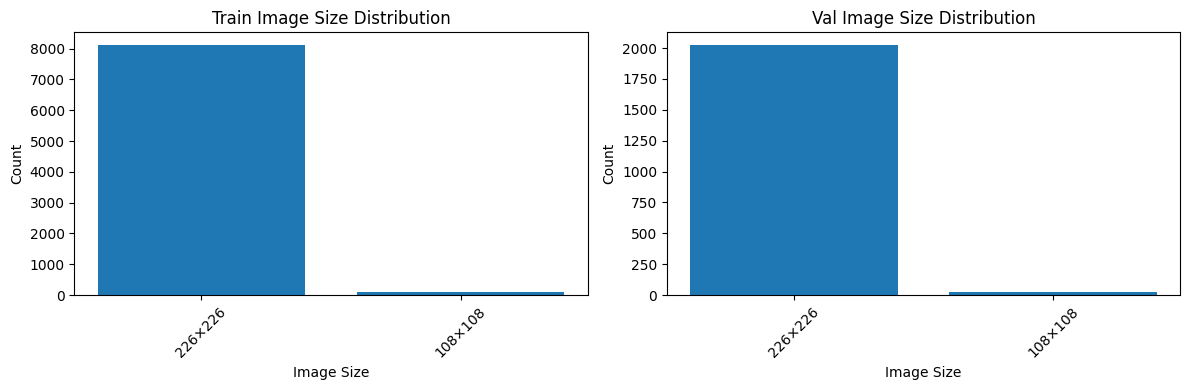

Saved figure to: /root/AIDL/output/cnn/eda/image_size_distribution.png


In [14]:
# ----------------------------
# Image size distribution analysis
# ----------------------------
import matplotlib.pyplot as plt

# build size summary
train_size_df = (
    train_images_df.groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
train_size_df["size_str"] = train_size_df["width"].astype(str) + "×" + train_size_df["height"].astype(str)

val_size_df = (
    val_images_df.groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
val_size_df["size_str"] = val_size_df["width"].astype(str) + "×" + val_size_df["height"].astype(str)

print("=== Train image size distribution ===")
display(train_size_df)

print("\n=== Val image size distribution ===")
display(val_size_df)

print("\nTop train sizes:")
print(train_size_df[["size_str", "count"]].head(10).to_string(index=False))

print("\nTop val sizes:")
print(val_size_df[["size_str", "count"]].head(10).to_string(index=False))

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(train_size_df["size_str"], train_size_df["count"])
axes[0].set_title("Train Image Size Distribution")
axes[0].set_xlabel("Image Size")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(val_size_df["size_str"], val_size_df["count"])
axes[1].set_title("Val Image Size Distribution")
axes[1].set_xlabel("Image Size")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

save_path = CNN_EDA_DIR / "image_size_distribution.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

Train 108x108 annotations: 205
Val 108x108 annotations  : 47

=== Train 108x108 class distribution ===


,category_name,count
0,SH,152
1,SP,28
2,CFO,8
3,MB,6
4,SC,4
5,HB,2
6,CS,2
7,OP,2
8,BMFO,1



=== Val 108x108 class distribution ===


,category_name,count
0,SH,31
1,SP,7
2,MB,4
3,BMFO,3
4,CFO,1
5,OP,1


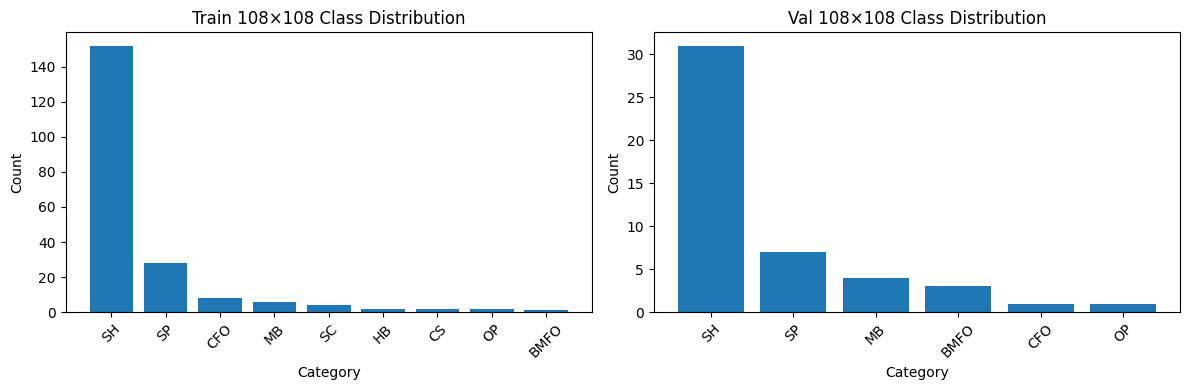

Saved figure to: /root/AIDL/output/cnn/eda/class_distribution_108x108_subset.png


In [15]:
# ----------------------------
# Class distribution for 108x108 subset
# ----------------------------
# annotation-level tables already include width/height after merge
train_108_df = train_det_df[(train_det_df["width"] == 108) & (train_det_df["height"] == 108)].copy()
val_108_df = val_det_df[(val_det_df["width"] == 108) & (val_det_df["height"] == 108)].copy()

print("Train 108x108 annotations:", len(train_108_df))
print("Val 108x108 annotations  :", len(val_108_df))

train_108_class_dist = (
    train_108_df.groupby("category_name")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

val_108_class_dist = (
    val_108_df.groupby("category_name")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Train 108x108 class distribution ===")
display(train_108_class_dist)

print("\n=== Val 108x108 class distribution ===")
display(val_108_class_dist)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(train_108_class_dist["category_name"], train_108_class_dist["count"])
axes[0].set_title("Train 108×108 Class Distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(val_108_class_dist["category_name"], val_108_class_dist["count"])
axes[1].set_title("Val 108×108 Class Distribution")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

save_path = CNN_EDA_DIR / "class_distribution_108x108_subset.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

### 108×108 子集类别分布分析

对 108×108 子集的进一步统计表明，这部分低分辨率样本并不是在各类别中随机分布的，而是表现出明显的类别偏置。在训练集中，该子集共有 205 个标注，其中 SH 类达到 152 个，约占 74.1%；在验证集中，共有 47 个标注，其中 SH 类有 31 个，约占 66.0%。相比之下，其他类别数量明显更少，只有 SP 类还占有一定比例，其余类别仅零星出现。

这一结果说明，108×108 图像不能被视为对整体数据集的随机抽样。如果直接删除这些图像，实际上会优先移除大量 SH 类样本，并在较小程度上影响 SP 及少数其他类别，从而改变原始数据集的类别分布。因此，仅仅因为这些图像尺寸较小而直接删除，并不是当前最稳妥的处理策略。

基于这一发现，更合理的下一步应当是结合样本可视化继续检查这些低分辨率图像的质量。如果这些图像中的缺陷仍然清晰可辨，且标注与主流样本保持一致，那么保留这些样本并通过后续预处理统一输入尺寸，会比直接删除更合理。

### Class Distribution Analysis of the 108×108 Subset

A further analysis of the 108×108 subset shows that these lower-resolution samples are not randomly distributed across categories. Instead, they are strongly concentrated in a few classes, especially SH. In the training split, the subset contains 205 annotations, of which 152 belong to SH, accounting for about 74.1%. In the validation split, there are 47 annotations in total, and 31 of them belong to SH, which is approximately 66.0%. By contrast, most other categories appear only rarely, with SP being the only other class with a noticeable presence.

This finding indicates that the 108×108 images should not be treated as a random miniature version of the full dataset. If these images were removed directly, the effect would not simply be the removal of a small amount of noise; it would disproportionately remove SH samples and, to a lesser extent, some SP samples, thereby altering the original class distribution of the dataset.

Therefore, the current evidence does not support immediate deletion based solely on image size. A more appropriate next step is to visually inspect these low-resolution samples and compare them with standard 226×226 images from the same category. If the defects remain recognisable and the annotations appear consistent, keeping these samples and handling them through resizing in preprocessing would be a more reasonable strategy than removing them.

Unique train SH images at 108x108: 86
Unique train SH images at 226x226: 392


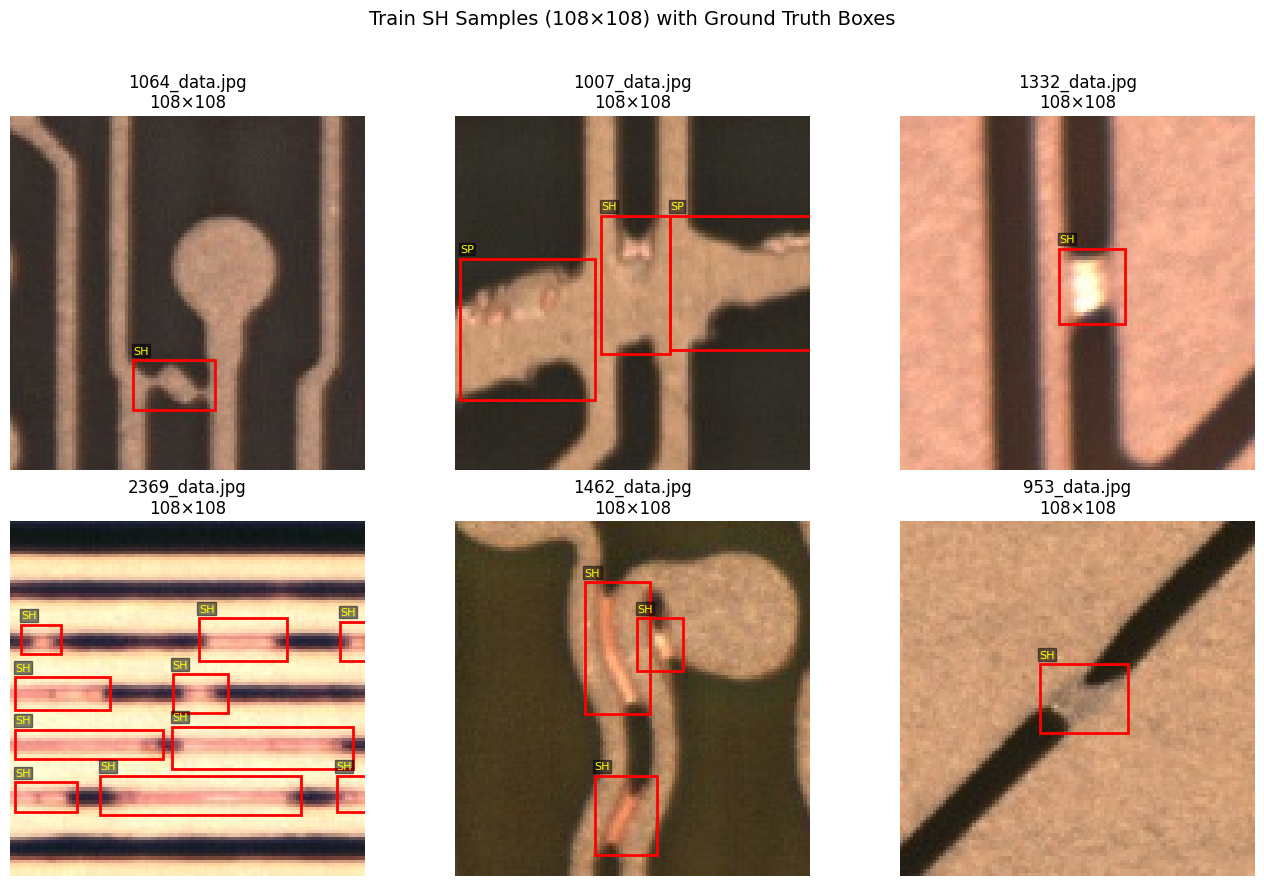

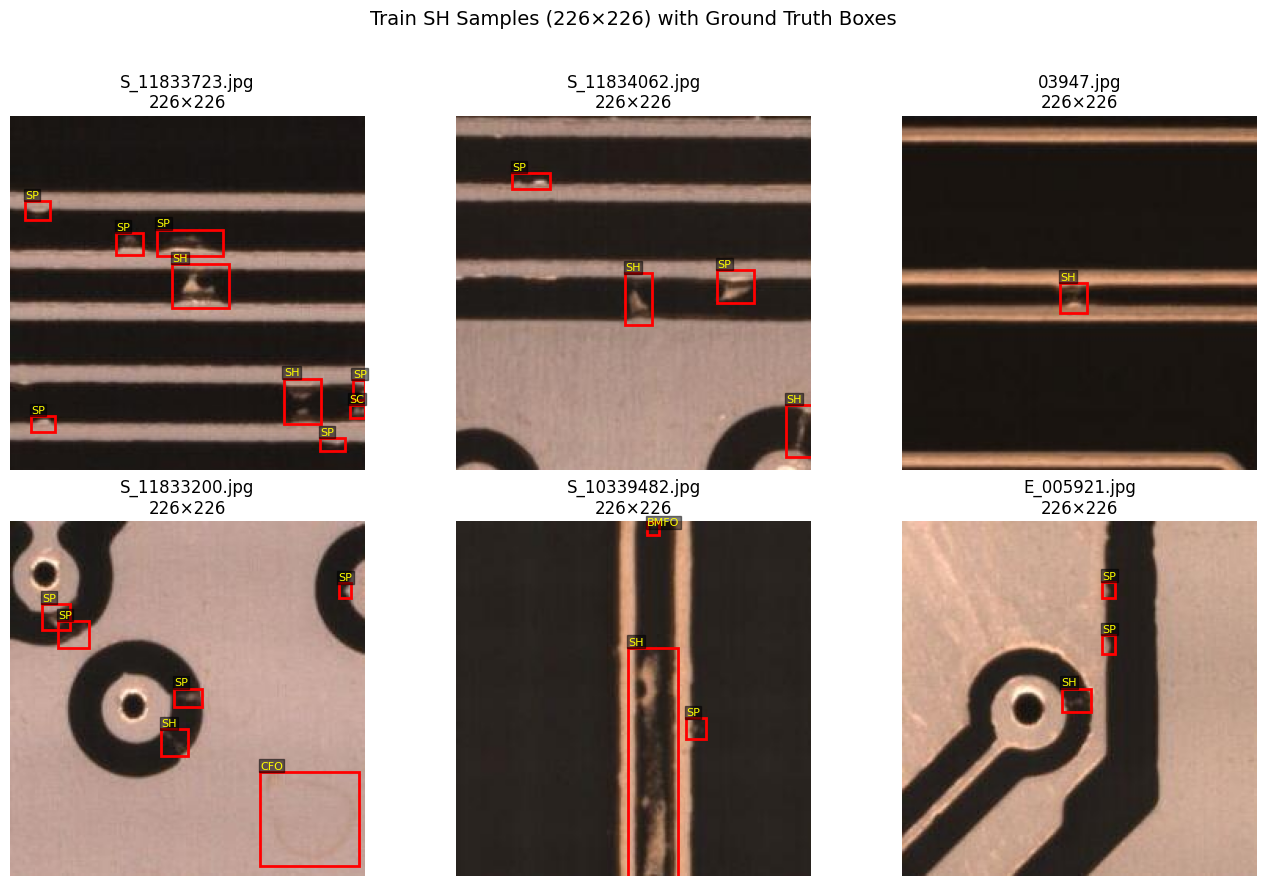

Saved figure to: /root/AIDL/output/cnn/eda/sh_samples_108x108_with_gt.png
Saved figure to: /root/AIDL/output/cnn/eda/sh_samples_226x226_with_gt.png


In [16]:
# ----------------------------
# Visual comparison: 108x108 vs 226x226 samples (SH class)
# ----------------------------
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

random.seed(42)

def collect_unique_images_by_condition(det_df, category_name, width, height):
    subset = det_df[
        (det_df["category_name"] == category_name) &
        (det_df["width"] == width) &
        (det_df["height"] == height)
    ][["image_id", "file_name", "width", "height"]].drop_duplicates()
    return subset.reset_index(drop=True)

def plot_images_with_gt(det_df, img_dir, image_meta_df, title_prefix, n_show=6, ncols=3):
    n_show = min(n_show, len(image_meta_df))
    sampled = image_meta_df.sample(n=n_show, random_state=42) if len(image_meta_df) > n_show else image_meta_df.copy()

    nrows = math.ceil(n_show / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows))
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    axes_flat = axes.flatten()

    for ax in axes_flat[n_show:]:
        ax.axis("off")

    for i, (_, row) in enumerate(sampled.iterrows()):
        ax = axes_flat[i]
        image_id = row["image_id"]
        file_name = row["file_name"]

        img_path = img_dir / file_name
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)

        ann_sub = det_df[det_df["image_id"] == image_id]
        for _, ann in ann_sub.iterrows():
            rect = patches.Rectangle(
                (ann["bbox_x"], ann["bbox_y"]),
                ann["bbox_w"],
                ann["bbox_h"],
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                ann["bbox_x"],
                max(ann["bbox_y"] - 2, 2),
                ann["category_name"],
                color="yellow",
                fontsize=8,
                bbox=dict(facecolor="black", alpha=0.5, pad=1)
            )

        ax.set_title(f"{file_name}\n{row['width']}×{row['height']}")
        ax.axis("off")

    fig.suptitle(title_prefix, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig

# collect SH samples
train_sh_108 = collect_unique_images_by_condition(train_det_df, category_name="SH", width=108, height=108)
train_sh_226 = collect_unique_images_by_condition(train_det_df, category_name="SH", width=226, height=226)

print("Unique train SH images at 108x108:", len(train_sh_108))
print("Unique train SH images at 226x226:", len(train_sh_226))

# plot 108x108 SH samples
fig1 = plot_images_with_gt(
    det_df=train_det_df,
    img_dir=TRAIN_IMG_DIR,
    image_meta_df=train_sh_108,
    title_prefix="Train SH Samples (108×108) with Ground Truth Boxes",
    n_show=6,
    ncols=3
)
save_path_108 = CNN_EDA_DIR / "sh_samples_108x108_with_gt.png"
fig1.savefig(save_path_108, dpi=200, bbox_inches="tight")
plt.show()

# plot 226x226 SH samples
fig2 = plot_images_with_gt(
    det_df=train_det_df,
    img_dir=TRAIN_IMG_DIR,
    image_meta_df=train_sh_226,
    title_prefix="Train SH Samples (226×226) with Ground Truth Boxes",
    n_show=6,
    ncols=3
)
save_path_226 = CNN_EDA_DIR / "sh_samples_226x226_with_gt.png"
fig2.savefig(save_path_226, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path_108}")
print(f"Saved figure to: {save_path_226}")

### 108×108 与 226×226 样本可视化对比分析

从可视化结果来看，108×108 图像并不只是简单意义上的“低分辨率异常样本”。相反，这些图像通常表现出更强的局部聚焦特征，即缺陷区域在整张图中的占比更大，视觉注意力更加集中，许多缺陷仍然能够被清晰辨认。尤其在 SH 类样本中，108×108 图像所呈现的缺陷区域往往更加紧凑，缺陷细节并没有因为尺寸较小而明显失真。

相比之下，226×226 图像提供了更大的上下文范围，图中往往包含更多的线路结构，且经常同时出现多个缺陷实例。这意味着 226×226 图像虽然具有更广的视野，但目标相对于整张图像的占比可能更小，同时背景结构也更复杂，因此检测难度不一定更低。

基于这一结果，目前更合理的解释是：这两种尺寸的图像可能对应不同的裁剪粒度，而不仅仅是简单的分辨率差异。因此，108×108 图像不应被轻易视为异常样本并直接删除。结合前面类别分布分析中其对 SH 类的明显偏置，删除这部分图像反而可能引入新的类别分布偏差。现阶段更合理的策略是保留这些样本，并在后续模型训练中通过统一的预处理与尺寸变换进行处理。

### Visual Comparison Between 108×108 and 226×226 Samples

The visual comparison suggests that the 108×108 images should not be interpreted simply as low-quality or abnormal samples. Instead, they appear to represent more tightly cropped local patches, where the defect occupies a larger proportion of the image and the visual focus is more concentrated. In many of the SH examples, the defect remains clearly visible, and the annotations are still well aligned with the defect regions.

By contrast, the 226×226 images provide a larger field of view and often contain more circuit structure as well as multiple defect instances within a single image. This means that while the larger images offer more contextual information, they may also introduce greater visual complexity and smaller relative target size, which can make detection more difficult rather than easier.

Based on this evidence, the two image sizes are better interpreted as reflecting different cropping scales rather than simply different resolutions. Therefore, the 108×108 images should not be removed at this stage. Combined with the earlier class distribution analysis, which showed that these samples are heavily concentrated in the SH category, deleting them would likely introduce a new class distribution bias. A more reasonable strategy is to retain them and handle the size difference through consistent preprocessing and resizing during training.

=== Overall class distribution ===


,category_id,category_name,count_train,count_val,pct_train,pct_val
0,1,SH,746,169,0.046095,0.041300
1,2,SP,3655,929,0.225840,0.227028
2,3,SC,1308,285,0.080821,0.069648
3,4,OP,1432,338,0.088482,0.082600
4,5,MB,1983,546,0.122528,0.133431
5,6,HB,2275,608,0.140571,0.148583
6,7,CS,2042,448,0.126174,0.109482
7,8,CFO,1409,423,0.087061,0.103372
8,9,BMFO,1334,346,0.082427,0.084555



Train class distribution:
category_name  count_train  pct_train
           SH          746   0.046095
           SP         3655   0.225840
           SC         1308   0.080821
           OP         1432   0.088482
           MB         1983   0.122528
           HB         2275   0.140571
           CS         2042   0.126174
          CFO         1409   0.087061
         BMFO         1334   0.082427

Val class distribution:
category_name  count_val  pct_val
           SH        169 0.041300
           SP        929 0.227028
           SC        285 0.069648
           OP        338 0.082600
           MB        546 0.133431
           HB        608 0.148583
           CS        448 0.109482
          CFO        423 0.103372
         BMFO        346 0.084555


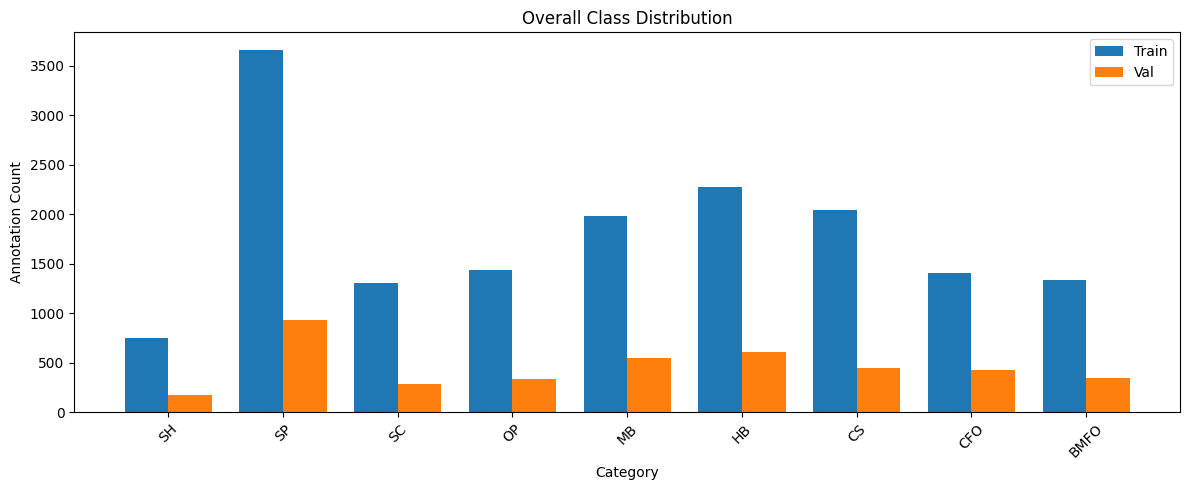

Saved figure to: /root/AIDL/output/cnn/eda/overall_class_distribution.png


In [17]:
# ----------------------------
# Overall class distribution analysis
# ----------------------------
# annotation-level class counts
train_class_dist = (
    train_det_df.groupby("category_name")
    .size()
    .reset_index(name="count_train")
)

val_class_dist = (
    val_det_df.groupby("category_name")
    .size()
    .reset_index(name="count_val")
)

# merge and align category order by category_id
cat_order_df = train_cat_df[["category_id", "category_name"]].sort_values("category_id").reset_index(drop=True)

class_dist_df = (
    cat_order_df
    .merge(train_class_dist, on="category_name", how="left")
    .merge(val_class_dist, on="category_name", how="left")
    .fillna(0)
)

class_dist_df["count_train"] = class_dist_df["count_train"].astype(int)
class_dist_df["count_val"] = class_dist_df["count_val"].astype(int)

class_dist_df["pct_train"] = class_dist_df["count_train"] / class_dist_df["count_train"].sum()
class_dist_df["pct_val"] = class_dist_df["count_val"] / class_dist_df["count_val"].sum()

print("=== Overall class distribution ===")
display(class_dist_df)

print("\nTrain class distribution:")
print(class_dist_df[["category_name", "count_train", "pct_train"]].to_string(index=False))

print("\nVal class distribution:")
print(class_dist_df[["category_name", "count_val", "pct_val"]].to_string(index=False))

# plot
x = np.arange(len(class_dist_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, class_dist_df["count_train"], width=width, label="Train")
ax.bar(x + width/2, class_dist_df["count_val"], width=width, label="Val")

ax.set_title("Overall Class Distribution")
ax.set_xlabel("Category")
ax.set_ylabel("Annotation Count")
ax.set_xticks(x)
ax.set_xticklabels(class_dist_df["category_name"], rotation=45)
ax.legend()

plt.tight_layout()

save_path = CNN_EDA_DIR / "overall_class_distribution.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

### 整体类别分布分析

整体类别分布结果表明，该数据集存在明显的类别不平衡现象，但训练集与验证集在分布趋势上总体保持一致。无论在训练集还是验证集中，SP 都是数量最多的类别，分别占全部标注的 22.58% 和 22.70%；HB、CS 和 MB 也属于相对高频类别。相比之下，SH 是最少的类别，在训练集和验证集中占比分别仅为 4.61% 和 4.13%。这说明不同类别之间的样本数量差距较大，最高频类别与最低频类别之间存在显著落差。

从训练集与验证集的对比来看，大多数类别的比例变化幅度不大。例如 SP、HB 和 BMFO 在两个划分中的占比都较为接近，说明官方提供的 train/val 划分在类别层面基本保持了相似的数据分布。这对后续实验是有利的，因为模型在训练阶段学到的类别先验与验证阶段面临的类别结构并没有发生明显偏移，从而能够提高评估结果的可信度。

不过，这种类别不平衡也意味着后续不能只依赖总体指标来判断模型表现。如果仅看 overall mAP 或整体 precision/recall，模型在高频类别上的较好表现可能会掩盖其在少数类上的不足。因此，在正式评估中必须结合每类 AP、Precision、Recall 和 F1 进行分析，尤其要重点关注 SH 这类低频类别，以及像 SP 这种高频类别是否由于样本充足而天然占优。这个发现也为后续错误样本分析提供了重要依据：若某些类别表现明显较差，需要进一步判断其原因是样本数量不足、类别本身更难、还是目标尺度与视觉模式更具挑战性。

### Overall Class Distribution Analysis

The overall class distribution indicates that the dataset is clearly imbalanced, although the training and validation splits remain broadly consistent in their distribution patterns. In both splits, SP is the most frequent category, accounting for 22.58% of all training annotations and 22.70% of all validation annotations. HB, CS, and MB are also relatively frequent categories. In contrast, SH is the least represented class, making up only 4.61% of the training annotations and 4.13% of the validation annotations. This shows that the dataset contains substantial variation in class frequency, with a clear gap between the most common and least common defect categories.

Comparing the two splits more closely, the class proportions are generally similar between train and validation. For example, SP, HB, and BMFO remain relatively stable across both splits, suggesting that the official train/val partition preserves the class structure reasonably well. This is beneficial for the experiment because the class priors learned during training are unlikely to differ substantially from those encountered during evaluation, which strengthens the credibility of the validation results.

However, the presence of class imbalance also means that overall metrics alone will not be sufficient for model assessment. A strong performance on frequent classes may conceal weaker performance on minority classes. For this reason, the final evaluation should not rely only on overall mAP or global precision and recall, but must also include per-class AP, Precision, Recall, and F1. In particular, low-frequency classes such as SH should be monitored carefully, while high-frequency classes such as SP should be examined to determine whether their performance benefits mainly from data abundance. This observation also motivates the later error analysis stage, where poor performance on certain classes should be interpreted in relation to sample scarcity, intrinsic defect difficulty, and visual scale differences.

=== Train objects per image summary ===
count    8208.000000
mean        1.971735
std         1.858968
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        25.000000
Name: num_objects, dtype: float64

=== Val objects per image summary ===
count    2051.000000
mean        1.995124
std         1.882131
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        27.000000
Name: num_objects, dtype: float64

=== Train object count frequency ===


,num_objects,image_count
0,1,4967
1,2,1459
2,3,744
3,4,398
4,5,238
5,6,140
6,7,84
7,8,59
8,9,39
9,10,24



=== Val object count frequency ===


,num_objects,image_count
0,1,1190
1,2,406
2,3,190
3,4,113
4,5,66
5,6,24
6,7,24
7,8,12
8,9,4
9,10,6


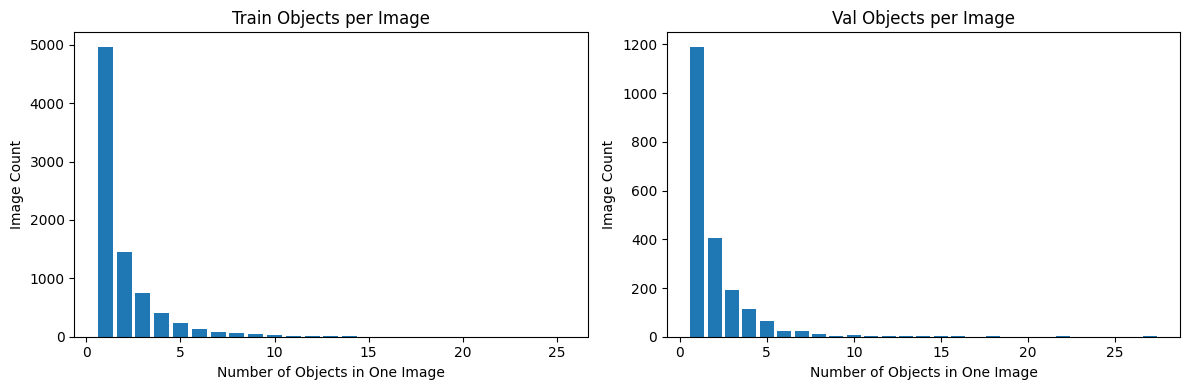

Saved figure to: /root/AIDL/output/cnn/eda/objects_per_image_distribution.png


In [18]:
# ----------------------------
# Objects per image distribution
# ----------------------------
train_obj_per_image = (
    train_det_df.groupby("image_id")
    .size()
    .reset_index(name="num_objects")
)

val_obj_per_image = (
    val_det_df.groupby("image_id")
    .size()
    .reset_index(name="num_objects")
)

print("=== Train objects per image summary ===")
print(train_obj_per_image["num_objects"].describe())

print("\n=== Val objects per image summary ===")
print(val_obj_per_image["num_objects"].describe())

# frequency table
train_obj_freq = (
    train_obj_per_image.groupby("num_objects")
    .size()
    .reset_index(name="image_count")
    .sort_values("num_objects")
)

val_obj_freq = (
    val_obj_per_image.groupby("num_objects")
    .size()
    .reset_index(name="image_count")
    .sort_values("num_objects")
)

print("\n=== Train object count frequency ===")
display(train_obj_freq)

print("\n=== Val object count frequency ===")
display(val_obj_freq)

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(train_obj_freq["num_objects"], train_obj_freq["image_count"], width=0.8)
axes[0].set_title("Train Objects per Image")
axes[0].set_xlabel("Number of Objects in One Image")
axes[0].set_ylabel("Image Count")

axes[1].bar(val_obj_freq["num_objects"], val_obj_freq["image_count"], width=0.8)
axes[1].set_title("Val Objects per Image")
axes[1].set_xlabel("Number of Objects in One Image")
axes[1].set_ylabel("Image Count")

plt.tight_layout()

save_path = CNN_EDA_DIR / "objects_per_image_distribution.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

### 每图目标数分布分析

从每图目标数统计结果来看，该数据集并不是一个严格的单目标检测任务，而是一个以低密度多目标场景为主的目标检测问题。训练集和验证集的平均每图目标数分别为 1.97 和 2.00，二者非常接近，说明官方 train/val 划分在目标密度层面也保持了较好的一致性。这对后续实验是有利的，因为模型在训练时接触到的图像复杂度与验证阶段较为一致。

进一步看分布形态可以发现，绝大多数图像只包含 1 到 2 个目标。训练集中，中位数为 1，四分位数范围显示 75% 的图像最多只包含 2 个目标；验证集也呈现出相同趋势。这说明虽然该任务不是单目标检测，但多数样本仍然属于相对稀疏的检测场景。因此，从整体上看，模型的主要挑战并不来自极端密集的目标重叠，而更多来自缺陷本身的类别差异、小目标特征以及背景结构的复杂性。

不过，分布尾部也表明数据集中存在少量高密度样本。训练集中最多一张图含有 25 个目标，验证集中最多达到 27 个目标。虽然这类样本数量极少，但它们仍然值得在后续错误分析中单独关注，因为对于这类高密度图像，模型更容易出现漏检、重复检测或邻近目标之间的混淆。总体而言，这一结果说明该数据集以低到中等目标密度为主，但同时包含少量更具挑战性的复杂样本，这也支持了后续在评估阶段加入错误样本分析的必要性。

### Objects-per-Image Distribution Analysis

The objects-per-image statistics show that this dataset is not a strictly single-object detection task, but rather a low-density multi-object detection problem. The average number of objects per image is 1.97 for the training set and 2.00 for the validation set, which are very close to each other. This indicates that the official train/val split is also consistent in terms of object density, which is beneficial because the model will face a similar level of image complexity during training and evaluation.

A closer look at the distribution reveals that most images contain only 1 or 2 objects. In the training set, the median is 1, and the quartile summary shows that 75% of images contain no more than 2 objects; the validation set follows the same pattern. This suggests that although the task is not single-object detection, the majority of samples remain relatively sparse. Therefore, the main challenge of the dataset does not come from extremely dense object overlap, but rather from factors such as defect category variation, small-object characteristics, and the complexity of PCB background structures.

At the same time, the tail of the distribution shows that a small number of highly dense images do exist. The maximum number of objects in one image is 25 in the training set and 27 in the validation set. Although such cases are rare, they are still important for later error analysis, since models are more likely to produce missed detections, duplicate detections, or confusion between neighbouring instances in these crowded scenes. Overall, the dataset is dominated by low-to-moderate object density, while still containing a few more challenging samples, which supports the need for targeted failure-case analysis in the evaluation stage.

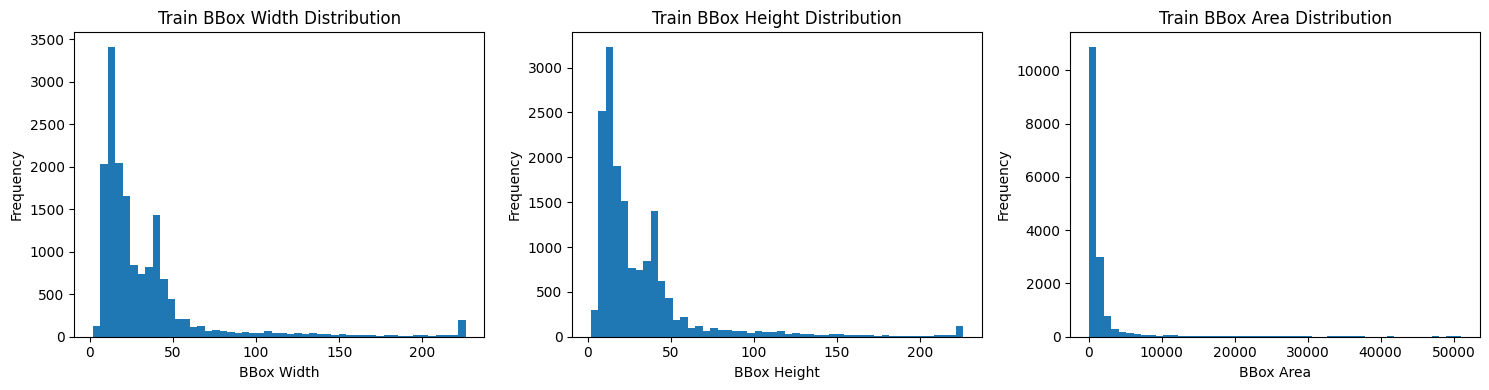

Saved figure to: /root/AIDL/output/cnn/eda/bbox_width_height_area_distribution_train.png
=== Train bbox width summary ===
count    16184.000000
mean        33.153266
std         37.300829
min          1.988800
25%         12.995000
50%         20.001600
75%         40.002000
max        226.000000
Name: bbox_w, dtype: float64

=== Train bbox height summary ===
count    16184.000000
mean        31.442008
std         34.308772
min          1.988800
25%         12.000600
50%         20.001000
75%         39.007600
max        226.000000
Name: bbox_h, dtype: float64

=== Train bbox area summary ===
count    16184.000000
mean      1936.508004
std       5562.417545
min         17.888858
25%        167.881194
50%        405.277845
75%       1479.921992
max      51076.000000
Name: bbox_area_from_wh, dtype: float64


In [19]:
# ----------------------------
# Overall bbox width / height / area distribution
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# width
axes[0].hist(train_det_df["bbox_w"], bins=50)
axes[0].set_title("Train BBox Width Distribution")
axes[0].set_xlabel("BBox Width")
axes[0].set_ylabel("Frequency")

# height
axes[1].hist(train_det_df["bbox_h"], bins=50)
axes[1].set_title("Train BBox Height Distribution")
axes[1].set_xlabel("BBox Height")
axes[1].set_ylabel("Frequency")

# area
axes[2].hist(train_det_df["bbox_area_from_wh"], bins=50)
axes[2].set_title("Train BBox Area Distribution")
axes[2].set_xlabel("BBox Area")
axes[2].set_ylabel("Frequency")

plt.tight_layout()

save_path = CNN_EDA_DIR / "bbox_width_height_area_distribution_train.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

print("=== Train bbox width summary ===")
print(train_det_df["bbox_w"].describe())

print("\n=== Train bbox height summary ===")
print(train_det_df["bbox_h"].describe())

print("\n=== Train bbox area summary ===")
print(train_det_df["bbox_area_from_wh"].describe())

### 边界框宽高与面积分布分析

从训练集边界框的统计结果来看，该数据集中的缺陷目标整体呈现出明显的“小目标为主、少量大目标存在”的分布特征。边界框宽度的中位数约为 20.00 像素，高度的中位数也约为 20.00 像素，而第一四分位数分别仅为约 13.00 和 12.00 像素。这说明至少一半以上的缺陷目标在空间尺度上都相对较小。与此同时，宽度和高度的均值分别为 33.15 和 31.44，明显高于中位数，表明分布具有明显的右偏特征，即大部分目标较小，但存在少量尺寸较大的目标把均值拉高。

面积分布进一步强化了这一判断。边界框面积的中位数约为 405.28，第一四分位数约为 167.88，而均值达到 1936.51，且标准差高达 5562.42，远大于均值本身。这说明面积分布比宽高分布更加极端地右偏，大多数缺陷框面积较小，但存在少量面积非常大的目标。从直方图中也可以直观看到，大部分样本集中在低面积区间，而高面积样本只形成稀疏长尾。

这一结果对于后续模型分析具有直接意义。首先，它表明 PCB 缺陷检测任务具有明显的小目标特征，因此模型性能不能只从整体指标来理解，还必须结合小目标失败案例进行讨论。其次，宽高和面积的长尾分布说明数据中同时存在少量大范围缺陷或大框标注，这意味着模型需要在同一数据集上同时处理小目标与大目标，增加了检测难度。最后，这一发现也说明后续应继续结合“目标面积占图像比例”进行分析，因为绝对面积虽然已经显示出小目标倾向，但只有进一步结合图像大小，才能更准确判断这些目标在整张图中的相对检测难度。

### Bounding Box Width, Height, and Area Distribution Analysis

The bounding box statistics from the training set indicate that the dataset is dominated by relatively small defect instances, while also containing a limited number of much larger targets. The median bounding box width is approximately 20.00 pixels, and the median height is also around 20.00 pixels. The first quartiles are only about 13.00 and 12.00 pixels, respectively, suggesting that more than half of the defect instances are small in spatial scale. At the same time, the mean width and height are 33.15 and 31.44, both substantially higher than their medians. This indicates a clear right-skewed distribution, where most objects are small but a minority of larger boxes pull the mean upward.

The area distribution reinforces this interpretation. The median bounding box area is about 405.28, while the first quartile is only 167.88. In contrast, the mean area reaches 1936.51, and the standard deviation is as high as 5562.42, which is much larger than the mean itself. This suggests that the area distribution is even more strongly right-skewed than the width and height distributions. Most defect boxes occupy a relatively small area, whereas a small number of large boxes form a long tail in the distribution.

This finding has direct implications for the later model analysis. First, it confirms that PCB defect detection in this dataset has a pronounced small-object characteristic, meaning that model performance should not be interpreted solely through overall metrics and should also be supported by small-object failure analysis. Second, the long-tail pattern in width, height, and area implies that the model must handle both small and large defect instances within the same dataset, which increases detection difficulty. Finally, this result suggests that the next step should examine the ratio between bounding box area and image area, because absolute area alone does not fully capture how difficult these objects are to detect relative to the overall image size.

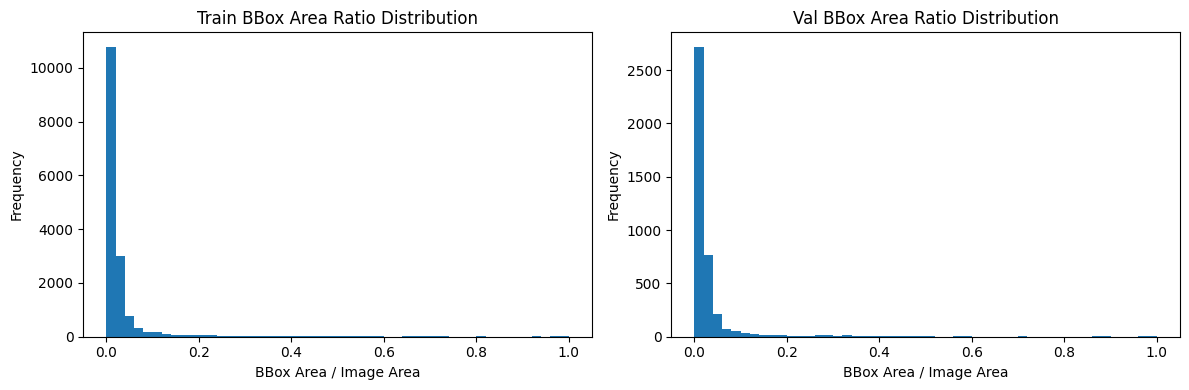

Saved figure to: /root/AIDL/output/cnn/eda/bbox_area_ratio_distribution.png
=== Train bbox area ratio summary ===
count    16184.000000
mean         0.038588
std          0.109297
min          0.000350
25%          0.003287
50%          0.008142
75%          0.029141
max          1.000000
Name: bbox_area_ratio, dtype: float64

=== Val bbox area ratio summary ===
count    4092.000000
mean        0.038195
std         0.109723
min         0.000488
25%         0.003287
50%         0.008222
75%         0.030159
max         1.000000
Name: bbox_area_ratio, dtype: float64


In [20]:
# ----------------------------
# Bounding box area ratio distribution
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# train
axes[0].hist(train_det_df["bbox_area_ratio"], bins=50)
axes[0].set_title("Train BBox Area Ratio Distribution")
axes[0].set_xlabel("BBox Area / Image Area")
axes[0].set_ylabel("Frequency")

# val
axes[1].hist(val_det_df["bbox_area_ratio"], bins=50)
axes[1].set_title("Val BBox Area Ratio Distribution")
axes[1].set_xlabel("BBox Area / Image Area")
axes[1].set_ylabel("Frequency")

plt.tight_layout()

save_path = CNN_EDA_DIR / "bbox_area_ratio_distribution.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

print("=== Train bbox area ratio summary ===")
print(train_det_df["bbox_area_ratio"].describe())

print("\n=== Val bbox area ratio summary ===")
print(val_det_df["bbox_area_ratio"].describe())

### 目标面积占图像面积比例分布分析

从目标面积占图像面积比例的统计结果来看，该数据集中的缺陷实例在整张图像中通常只占很小一部分，进一步验证了这一任务具有明显的小目标检测特征。训练集与验证集的统计结果非常接近：训练集的中位数约为 0.0081，验证集的中位数约为 0.0082，这意味着至少一半的缺陷框面积只占整张图像面积的 1% 左右甚至更少。第一四分位数约为 0.0033，也说明相当一部分缺陷实例只占图像面积的极小比例。

与此同时，均值约为 0.038，而标准差约为 0.109，明显高于均值本身，说明该分布具有很强的右偏和长尾特征。大多数样本集中在非常低的面积占比区间，但也存在少量占比较大的目标。从直方图中可以看出，绝大多数实例都聚集在接近 0 的区域，而较大的面积占比仅由少量样本构成长尾。这与前面边界框绝对面积的分析结论一致，但面积占比提供了更强的证据，因为它排除了图像尺寸差异带来的影响。

这一结果对于后续实验解释非常重要。首先，它表明该任务中的大多数缺陷目标不仅在绝对像素尺度上偏小，而且相对于整张图像也同样很小，因此检测难度主要集中在小目标识别与定位上。其次，训练集与验证集在面积占比统计上几乎一致，说明官方数据划分在目标尺度层面也保持了较好的分布一致性。最后，这一发现进一步支持在正式评估阶段重点关注 Recall、每类 AP、每类 F1 以及小目标失败样本，因为整体指标可能无法充分揭示模型在微小缺陷上的真实表现。

### Bounding Box Area Ratio Distribution Analysis

The statistics of bounding box area ratio show that defect instances in this dataset usually occupy only a very small fraction of the full image, which provides further evidence that this is a pronounced small-object detection problem. The training and validation splits are highly consistent: the median area ratio is about 0.0081 in the training set and 0.0082 in the validation set. This means that at least half of the defect boxes occupy only around 1% or less of the image area. The first quartile is approximately 0.0033, indicating that a substantial proportion of defects cover only a tiny fraction of the image.

At the same time, the mean is about 0.038, while the standard deviation is around 0.109, which is clearly larger than the mean. This suggests a strongly right-skewed and long-tailed distribution. Most samples are concentrated in the very low-ratio region, while only a small number of instances occupy a much larger portion of the image. The histogram confirms this pattern: the majority of objects cluster very close to zero, whereas larger area ratios appear only as a sparse tail. This is consistent with the earlier absolute area analysis, but the area-ratio view is more informative because it removes the effect of image size variation.

This finding is highly important for later experiment interpretation. First, it shows that most defect instances are not only small in absolute pixel terms, but also small relative to the full image, meaning that the main challenge lies in detecting and localising small defects. Second, the near-identical ratio statistics between train and validation suggest that the official split is also well aligned in terms of target scale. Finally, this result further justifies placing strong emphasis on Recall, per-class AP, per-class F1, and small-object failure analysis in the final evaluation, since overall metrics alone may not fully reflect the model’s actual performance on tiny defects.

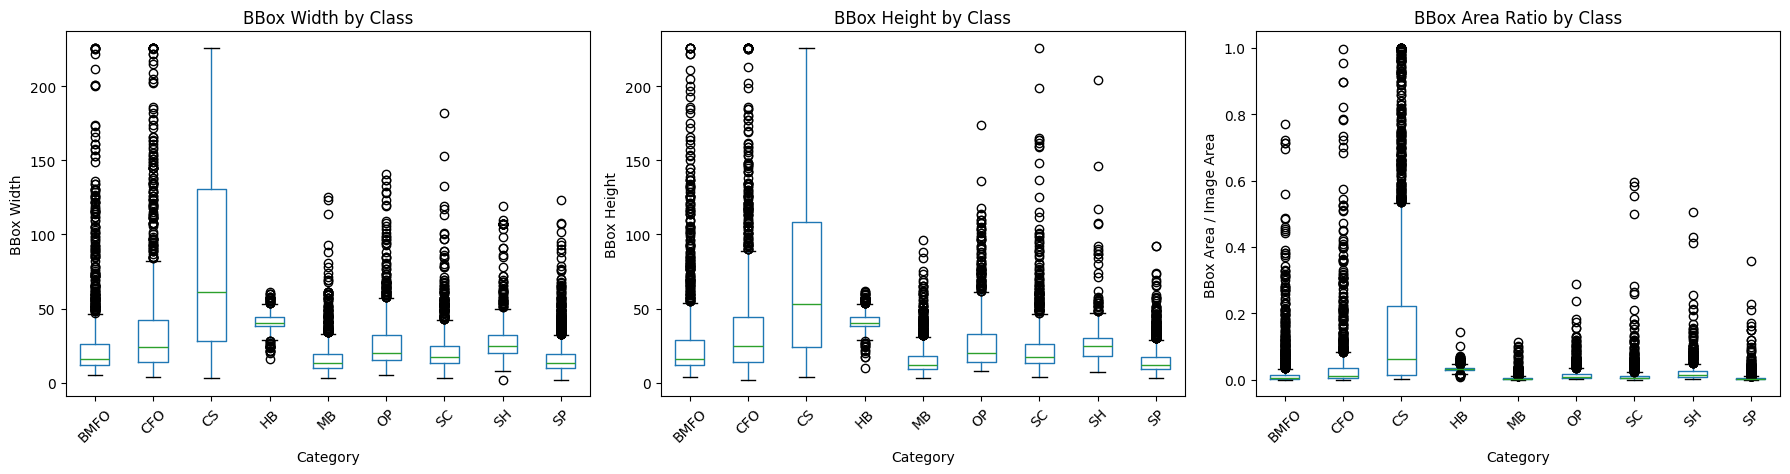

Saved figure to: /root/AIDL/output/cnn/eda/per_class_bbox_size_difference.png
=== Per-class size summary (train) ===


bbox_w              bbox_h            bbox_area_ratio  \
                median       mean   median       mean          median   
category_name                                                           
BMFO           16.0008  26.519003  16.0008  28.915533        0.004993   
CFO            24.0012  36.558520  24.9956  37.856031        0.012613   
CS             60.9974  85.802454  52.9970  74.438571        0.063028   
HB             40.0020  41.017590  40.0020  41.022488        0.032108   
MB             12.9950  16.704379  12.0006  15.574578        0.003306   
OP             20.0010  25.977921  20.0010  26.988461        0.009157   
SC             16.9952  22.092956  16.9952  23.926175        0.006106   
SH             24.9956  30.261022  24.9956  26.294506        0.013709   
SP             12.9950  16.236403  12.0006  14.000619        0.003129   

                         
                   mean  
category_name            
BMFO           0.028423  
CFO            0.043646  
CS             0.174330  
HB             0.033329  
MB             0.005918  
OP             0.015424  
SC             0.015094  
SH             0.026098  
SP             0.005540

In [21]:
# ----------------------------
# Per-class bbox size difference analysis
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# bbox width by class
train_det_df.boxplot(column="bbox_w", by="category_name", ax=axes[0], grid=False)
axes[0].set_title("BBox Width by Class")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("BBox Width")
axes[0].tick_params(axis="x", rotation=45)

# bbox height by class
train_det_df.boxplot(column="bbox_h", by="category_name", ax=axes[1], grid=False)
axes[1].set_title("BBox Height by Class")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("BBox Height")
axes[1].tick_params(axis="x", rotation=45)

# bbox area ratio by class
train_det_df.boxplot(column="bbox_area_ratio", by="category_name", ax=axes[2], grid=False)
axes[2].set_title("BBox Area Ratio by Class")
axes[2].set_xlabel("Category")
axes[2].set_ylabel("BBox Area / Image Area")
axes[2].tick_params(axis="x", rotation=45)

# remove pandas default suptitle
plt.suptitle("")
plt.tight_layout()

save_path = CNN_EDA_DIR / "per_class_bbox_size_difference.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

# optional numeric summary
per_class_size_summary = (
    train_det_df.groupby("category_name")[["bbox_w", "bbox_h", "bbox_area_ratio"]]
    .agg(["median", "mean"])
)

print("=== Per-class size summary (train) ===")
display(per_class_size_summary)

### 按类别的目标尺寸差异分析

从按类别的边界框尺寸统计来看，不同缺陷类别之间在目标尺度上存在明显差异，这说明后续模型性能的类别间差异不能仅仅归因于样本数量，还可能与目标本身的空间尺度有关。整体来看，CS 是最显著的大目标类别，其边界框宽度和高度中位数分别约为 60.98 和 53.00，面积占图像比例的中位数达到 0.0630，明显高于其他类别。HB 也属于相对较大的类别，其宽高中位数都约为 40 像素，面积占比中位数约为 0.0321。相比之下，MB 和 SP 是最典型的小目标类别之一，二者的宽高中位数大约只有 13 像素，面积占比中位数分别仅为 0.0033 和 0.0031。

从中等尺度类别来看，SH 和 CFO 的中位尺寸均约为 25 像素左右，面积占比中位数分别为 0.0137 和 0.0126；OP 处于更接近中小目标的位置，中位宽高约为 20 像素，面积占比中位数约为 0.0092；SC 与 BMFO 的中位尺寸更接近 17 像素和 16 像素，对应的面积占比也较低。由此可见，不同类别不仅样本数量不同，而且目标大小本身也不一致，数据集同时包含了大目标类、中等目标类和非常小的目标类。

这一结果对后续实验解释非常关键。首先，如果某些类别在最终评估中的 AP、Recall 或 F1 明显偏低，那么其原因可能不仅仅是样本不足，也可能是该类目标本身更小，例如 SP、MB 和 SC。其次，像 CS 这类目标更大的类别，理论上更容易被检测器定位，但也要结合其标注形式和视觉模式进一步分析。最后，这一发现进一步强化了 per-class evaluation 的必要性，因为类别间的检测难度并不相同，而这种难度差异已经在目标尺寸层面得到了明显体现。

### Per-Class Object Size Difference Analysis

The per-class bounding box statistics show that object scale varies substantially across defect categories. This means that later differences in model performance cannot be explained only by class frequency; they may also be strongly influenced by the spatial size of the defects themselves. Among all classes, CS stands out as the largest-target category, with median bounding box width and height of approximately 60.98 and 53.00 pixels, respectively, and a median area ratio of 0.0630, which is clearly higher than the other categories. HB is also relatively large, with both median width and height close to 40 pixels and a median area ratio of about 0.0321. In contrast, MB and SP are among the clearest small-object categories, with median widths and heights of only about 13 pixels and median area ratios of just 0.0033 and 0.0031.

Several categories fall in the middle range. SH and CFO both have median sizes around 25 pixels, with median area ratios of 0.0137 and 0.0126, respectively. OP is closer to the small-to-medium range, with median width and height around 20 pixels and a median area ratio of about 0.0092. SC and BMFO are smaller still, with median sizes around 17 and 16 pixels and similarly low area ratios. Overall, the dataset contains a mixture of large-object, medium-object, and very small-object classes rather than a uniform target scale across categories.

This result is highly important for later interpretation of model performance. If certain categories show noticeably lower AP, Recall, or F1 in the final evaluation, the cause may not be limited to data imbalance; it may also be related to the fact that those categories are intrinsically smaller and therefore harder to detect, such as SP, MB, and SC. Conversely, larger categories such as CS may be easier to localise in principle, although their actual performance will still need to be interpreted together with their visual characteristics and annotation patterns. Overall, this finding further justifies the need for per-class evaluation, because the dataset already shows clear class-dependent detection difficulty at the object-size level.

In [22]:
# ----------------------------
# Bounding box anomaly and extreme-case check
# ----------------------------
def bbox_quality_check(det_df, split_name):
    results = {
        "split": split_name,
        "num_annotations": len(det_df),
        "non_positive_width": int((det_df["bbox_w"] <= 0).sum()),
        "non_positive_height": int((det_df["bbox_h"] <= 0).sum()),
        "negative_x": int((det_df["bbox_x"] < 0).sum()),
        "negative_y": int((det_df["bbox_y"] < 0).sum()),
        "x2_exceeds_width": int((det_df["bbox_x2"] > det_df["width"]).sum()),
        "y2_exceeds_height": int((det_df["bbox_y2"] > det_df["height"]).sum()),
        "area_ratio_ge_0_5": int((det_df["bbox_area_ratio"] >= 0.5).sum()),
        "area_ratio_ge_0_9": int((det_df["bbox_area_ratio"] >= 0.9).sum()),
        "area_ratio_eq_1_0": int((det_df["bbox_area_ratio"] == 1.0).sum()),
    }
    return results

train_bbox_check = bbox_quality_check(train_det_df, "train")
val_bbox_check = bbox_quality_check(val_det_df, "val")

bbox_check_df = pd.DataFrame([train_bbox_check, val_bbox_check])

print("=== Bounding box quality check ===")
display(bbox_check_df)

# show examples of the most extreme area-ratio samples
train_extreme_df = train_det_df.sort_values("bbox_area_ratio", ascending=False)[
    ["image_id", "file_name", "category_name", "bbox_w", "bbox_h", "bbox_area_from_wh", "image_area", "bbox_area_ratio", "width", "height"]
].head(20)

val_extreme_df = val_det_df.sort_values("bbox_area_ratio", ascending=False)[
    ["image_id", "file_name", "category_name", "bbox_w", "bbox_h", "bbox_area_from_wh", "image_area", "bbox_area_ratio", "width", "height"]
].head(20)

print("\n=== Top 20 extreme train samples by bbox_area_ratio ===")
display(train_extreme_df)

print("\n=== Top 20 extreme val samples by bbox_area_ratio ===")
display(val_extreme_df)

=== Bounding box quality check ===


,split,num_annotations,non_positive_width,non_positive_height,negative_x,negative_y,x2_exceeds_width,y2_exceeds_height,area_ratio_ge_0_5,area_ratio_ge_0_9,area_ratio_eq_1_0
0,train,16184,0,0,5,2,165,140,273,73,15
1,val,4092,0,0,2,1,26,34,62,19,4



=== Top 20 extreme train samples by bbox_area_ratio ===


,image_id,file_name,category_name,bbox_w,bbox_h,bbox_area_from_wh,image_area,bbox_area_ratio,width,height
13950,7084,S_11931108.jpg,CS,226.0000,226.0000,51076.0000,51076,1.0000,226,226
12351,6255,S_11941539.jpg,CS,226.0000,226.0000,51076.0000,51076,1.0000,226,226
3229,1688,S_11306624.jpg,CS,226.0000,226.0000,51076.0000,51076,1.0000,226,226
9867,5020,S_11332683.jpg,CS,226.0000,226.0000,51076.0000,51076,1.0000,226,226
5793,3020,S_12003816.jpg,CS,226.0000,226.0000,51076.0000,51076,1.0000,226,226
9974,5084,S_11327622.jpg,CS,226.0000,226.0000,51076.0000,51076,1.0000,226,226
42,24,S_12479110.jpg,CS,226.0000,226.0000,51076.0000,51076,1.0000,226,226
11710,5901,S_11922973.jpg,CS,226.0000,226.0000,51076.0000,51076,1.0000,226,226
15091,7644,S_11922986.jpg,CS,226.0000,226.0000,51076.0000,51076,1.0000,226,226
246,138,S_10378945.jpg,CS,226.0000,226.0000,51076.0000,51076,1.0000,226,226



=== Top 20 extreme val samples by bbox_area_ratio ===


,image_id,file_name,category_name,bbox_w,bbox_h,bbox_area_from_wh,image_area,bbox_area_ratio,width,height
1719,869,S_11942218.jpg,CS,226.0000,226.0000,51076.000000,51076,1.000000,226,226
1631,818,S_10067453.jpg,CFO,226.0000,226.0000,51076.000000,51076,1.000000,226,226
1594,798,S_11082914.jpg,CS,226.0000,226.0000,51076.000000,51076,1.000000,226,226
4051,2029,S_11190004.jpg,CS,226.0000,226.0000,51076.000000,51076,1.000000,226,226
3766,1881,S_11931758.jpg,CS,226.0000,225.0056,50851.265600,51076,0.995600,226,226
122,58,S_11329436.jpg,CS,226.0000,225.0056,50851.265600,51076,0.995600,226,226
4055,2031,S_11340713.jpg,CS,226.0000,225.0056,50851.265600,51076,0.995600,226,226
1138,551,S_11336108.jpg,CS,225.0056,225.0056,50627.520031,51076,0.991219,226,226
1095,528,S_11073320.jpg,CS,226.0000,221.9998,50171.954800,51076,0.982300,226,226
1688,848,S_11077161.jpg,CS,225.0056,221.9998,49951.198199,51076,0.977978,226,226


### 异常框与极端样本分析

从边界框质量检查结果来看，数据集整体标注质量是可接受的，因为不存在宽度或高度非正的无效框，说明基本框结构没有明显错误。不过，数据中仍然存在少量边界越界现象。训练集中有 5 个框的 `x` 为负、2 个框的 `y` 为负，同时有 165 个框的右边界超过图像宽度、140 个框的下边界超过图像高度；验证集中对应数量分别为 2、1、26 和 34。考虑到训练集共有 16184 个标注、验证集共有 4092 个标注，这些越界样本所占比例并不高，说明问题存在但不属于大规模系统性错误。

更值得注意的是大面积框样本的存在。训练集中有 273 个框的面积占比不低于 0.5，其中 73 个不低于 0.9，甚至有 15 个恰好等于 1.0；验证集中分别有 62、19 和 4 个。这说明数据中确实存在一批几乎覆盖整张图像的大框标注。进一步查看极端样本表可以发现，这些面积占比接近 1 的样本高度集中在 CS 类，且其边界框宽高通常接近整张 226×226 图像本身，例如 226×226、226×225 或 225×226。

这一结果表明，面积占比接近 1 的极端样本并不是随机噪声，而更可能是某些类别特有的标注模式，尤其是 CS 类。因此，这些样本不应直接视为错误数据并简单删除。更合理的解释是：数据集中除了大量小目标外，还存在少量“几乎铺满整张 patch”的大范围目标实例。对于后续实验而言，这意味着模型需要同时学习两种明显不同的目标尺度模式。此外，这一发现也说明在结果分析中需要特别注意 CS 类，因为它不仅目标更大，而且在标注形式上与多数类别存在显著差异，这可能会使其在检测任务中呈现不同于其他类别的表现。

### Bounding Box Anomaly and Extreme-Case Analysis

The bounding box quality check shows that the dataset is generally usable, since there are no annotations with non-positive width or height. This means that the box structure itself does not contain obvious invalid entries. However, a small number of boundary violations do exist. In the training set, 5 boxes have negative `x` values and 2 have negative `y` values, while 165 boxes extend beyond the image width and 140 exceed the image height. In the validation set, the corresponding counts are 2, 1, 26, and 34. Given the overall annotation counts of 16,184 for training and 4,092 for validation, these problematic cases represent only a small fraction of the dataset, suggesting that they are minor issues rather than large-scale systematic corruption.

A more important observation is the presence of very large bounding boxes. In the training set, 273 boxes have an area ratio of at least 0.5, 73 are above 0.9, and 15 are exactly equal to 1.0. In the validation set, the corresponding counts are 62, 19, and 4. This confirms that a subset of annotations occupies almost the entire image. Looking at the most extreme examples, these near-full-image boxes are highly concentrated in the CS category, and their dimensions are often almost identical to the full 226×226 image size, such as 226×226, 226×225, or 225×226.

This suggests that the extreme large-box cases are not random noise, but are more likely to reflect a category-specific annotation pattern, especially for CS. Therefore, these samples should not be treated as obvious annotation errors or removed without further justification. A more reasonable interpretation is that, in addition to many small-object instances, the dataset also contains a small number of very large defect instances that nearly fill the entire patch. For later experiments, this means the model must learn to handle two clearly different object-scale regimes. It also indicates that the CS category deserves special attention during result interpretation, because its objects are not only larger than those in most other classes, but also follow a markedly different annotation pattern.

In [23]:
# ----------------------------
# COCO bbox -> clipped xyxy + invalid box filtering statistics
# ----------------------------
def coco_xywh_to_clipped_xyxy_stats(images_df, ann_df, split_name):
    """
    Convert COCO bbox [x, y, w, h] to clipped [x1, y1, x2, y2],
    and collect cleaning statistics without modifying original files.
    """
    img_meta = images_df[["id", "width", "height"]].rename(columns={"id": "image_id"})
    df = ann_df.copy().merge(img_meta, on="image_id", how="left")

    # original xywh
    df[["x", "y", "w", "h"]] = pd.DataFrame(df["bbox"].tolist(), index=df.index)

    # raw xyxy
    df["x1_raw"] = df["x"]
    df["y1_raw"] = df["y"]
    df["x2_raw"] = df["x"] + df["w"]
    df["y2_raw"] = df["y"] + df["h"]

    # clipping
    df["x1_clip"] = df["x1_raw"].clip(lower=0)
    df["y1_clip"] = df["y1_raw"].clip(lower=0)
    df["x2_clip"] = np.minimum(df["x2_raw"], df["width"])
    df["y2_clip"] = np.minimum(df["y2_raw"], df["height"])

    # size after clipping
    df["w_clip"] = df["x2_clip"] - df["x1_clip"]
    df["h_clip"] = df["y2_clip"] - df["y1_clip"]

    # validity after clipping
    df["valid_after_clip"] = (df["w_clip"] > 0) & (df["h_clip"] > 0)

    stats = {
        "split": split_name,
        "num_annotations": int(len(df)),
        "negative_x_before": int((df["x1_raw"] < 0).sum()),
        "negative_y_before": int((df["y1_raw"] < 0).sum()),
        "x2_exceeds_width_before": int((df["x2_raw"] > df["width"]).sum()),
        "y2_exceeds_height_before": int((df["y2_raw"] > df["height"]).sum()),
        "any_clipping_applied": int(
            (
                (df["x1_raw"] != df["x1_clip"]) |
                (df["y1_raw"] != df["y1_clip"]) |
                (df["x2_raw"] != df["x2_clip"]) |
                (df["y2_raw"] != df["y2_clip"])
            ).sum()
        ),
        "invalid_after_clip": int((~df["valid_after_clip"]).sum()),
        "valid_after_clip": int(df["valid_after_clip"].sum()),
    }

    # examples of clipped rows
    clipped_examples = df[
        (df["x1_raw"] != df["x1_clip"]) |
        (df["y1_raw"] != df["y1_clip"]) |
        (df["x2_raw"] != df["x2_clip"]) |
        (df["y2_raw"] != df["y2_clip"])
    ][[
        "image_id", "category_id", "bbox",
        "x1_raw", "y1_raw", "x2_raw", "y2_raw",
        "x1_clip", "y1_clip", "x2_clip", "y2_clip",
        "width", "height", "valid_after_clip"
    ]].head(20)

    invalid_examples = df[
        ~df["valid_after_clip"]
    ][[
        "image_id", "category_id", "bbox",
        "x1_raw", "y1_raw", "x2_raw", "y2_raw",
        "x1_clip", "y1_clip", "x2_clip", "y2_clip",
        "w_clip", "h_clip", "width", "height"
    ]].head(20)

    return df, stats, clipped_examples, invalid_examples


train_clean_df, train_clean_stats, train_clipped_examples, train_invalid_examples = coco_xywh_to_clipped_xyxy_stats(
    train_images_df, train_ann_df, "train"
)
val_clean_df, val_clean_stats, val_clipped_examples, val_invalid_examples = coco_xywh_to_clipped_xyxy_stats(
    val_images_df, val_ann_df, "val"
)

clean_stats_df = pd.DataFrame([train_clean_stats, val_clean_stats])

print("=== BBox cleaning statistics ===")
display(clean_stats_df)

print("\n=== Example clipped train boxes ===")
display(train_clipped_examples)

print("\n=== Example clipped val boxes ===")
display(val_clipped_examples)

print("\n=== Invalid train boxes after clipping ===")
display(train_invalid_examples)

print("\n=== Invalid val boxes after clipping ===")
display(val_invalid_examples)

=== BBox cleaning statistics ===


,split,num_annotations,negative_x_before,negative_y_before,x2_exceeds_width_before,y2_exceeds_height_before,any_clipping_applied,invalid_after_clip,valid_after_clip
0,train,16184,5,2,165,140,308,0,16184
1,val,4092,2,1,26,34,63,0,4092



=== Example clipped train boxes ===


,image_id,category_id,bbox,x1_raw,y1_raw,x2_raw,y2_raw,x1_clip,y1_clip,x2_clip,y2_clip,width,height,valid_after_clip
27,17,6,"[7.006000000000003, 191.0039, 47.0079999999999...",7.0060,191.0039,54.0140,226.0113,7.0060,191.0039,54.0140,226.0000,226,226,True
118,72,7,"[135.00109999999998, 8.0004, 91.0102, 33.9904]",135.0011,8.0004,226.0113,41.9908,135.0011,8.0004,226.0000,41.9908,226,226,True
202,119,7,"[0.0, 24.001200000000004, 170.9916, 201.998800...",0.0000,24.0012,170.9916,226.0000,0.0000,24.0012,170.9916,226.0000,226,226,True
349,187,7,"[13.00630000000001, 24.9956, 213.005, 88.0044]",13.0063,24.9956,226.0113,113.0000,13.0063,24.9956,226.0000,113.0000,226,226,True
359,190,7,"[109.01109999999998, 159.0023, 117.0002, 67.009]",109.0111,159.0023,226.0113,226.0113,109.0111,159.0023,226.0000,226.0000,226,226,True
369,193,3,"[215.0051, 125.00059999999998, 11.0062, 17.9896]",215.0051,125.0006,226.0113,142.9902,215.0051,125.0006,226.0000,142.9902,226,226,True
405,214,7,"[13.00630000000001, 42.0021, 213.005, 100.9994...",13.0063,42.0021,226.0113,143.0015,13.0063,42.0021,226.0000,143.0015,226,226,True
415,222,8,"[77.0095, 64.00319999999999, 149.0018, 161.9968]",77.0095,64.0032,226.0113,226.0000,77.0095,64.0032,226.0000,226.0000,226,226,True
586,308,7,"[26.0013, 209.00480000000002, 28.9958, 16.9952]",26.0013,209.0048,54.9971,226.0000,26.0013,209.0048,54.9971,226.0000,226,226,True
596,314,8,"[93.01029999999999, 78.00389999999999, 29.9902...",93.0103,78.0039,123.0005,226.0113,93.0103,78.0039,123.0005,226.0000,226,226,True



=== Example clipped val boxes ===


,image_id,category_id,bbox,x1_raw,y1_raw,x2_raw,y2_raw,x1_clip,y1_clip,x2_clip,y2_clip,width,height,valid_after_clip
31,14,7,"[141.99580000000003, 8.00040000000001, 79.0096...",141.9958,8.0004,221.0054,226.0000,141.9958,8.0004,221.0054,226.0000,226,226,True
195,104,6,"[190.0095, 152.0076, 36.0018, 40.001999999999995]",190.0095,152.0076,226.0113,192.0096,190.0095,152.0076,226.0000,192.0096,226,226,True
275,134,8,"[145.0016, 209.00480000000002, 8.0004, 16.9952]",145.0016,209.0048,153.0020,226.0000,145.0016,209.0048,153.0020,226.0000,226,226,True
295,146,3,"[70.0035, 45.007899999999985, 156.0078, 157.9966]",70.0035,45.0079,226.0113,203.0045,70.0035,45.0079,226.0000,203.0045,226,226,True
373,177,7,"[152.00760000000002, 0.0, 73.9924, 72.0036]",152.0076,0.0000,226.0000,72.0036,152.0076,0.0000,226.0000,72.0036,226,226,True
427,206,7,"[6.000300000000004, 45.007900000000014, 205.00...",6.0003,45.0079,211.0049,226.0113,6.0003,45.0079,211.0049,226.0000,226,226,True
696,353,7,"[0.0, 46.002300000000005, 226.0, 180.009]",0.0000,46.0023,226.0000,226.0113,0.0000,46.0023,226.0000,226.0000,226,226,True
726,372,2,"[208.01040000000003, 57.9916, 17.9896, 7.006]",208.0104,57.9916,226.0000,64.9976,208.0104,57.9916,226.0000,64.9976,226,226,True
1023,496,7,"[0.0, 24.001200000000004, 145.0016, 201.998800...",0.0000,24.0012,145.0016,226.0000,0.0000,24.0012,145.0016,226.0000,226,226,True
1031,500,6,"[86.9987, 184.00920000000002, 52.0026, 41.9908]",86.9987,184.0092,139.0013,226.0000,86.9987,184.0092,139.0013,226.0000,226,226,True



=== Invalid train boxes after clipping ===


,image_id,category_id,bbox,x1_raw,y1_raw,x2_raw,y2_raw,x1_clip,y1_clip,x2_clip,y2_clip,w_clip,h_clip,width,height



=== Invalid val boxes after clipping ===


,image_id,category_id,bbox,x1_raw,y1_raw,x2_raw,y2_raw,x1_clip,y1_clip,x2_clip,y2_clip,w_clip,h_clip,width,height


### 边界框清洗与 clipping 结果分析

从清洗统计结果来看，数据集中确实存在少量越界框，但通过 clipping 可以被有效修正，而且修正后没有产生无效框。训练集中共有 16184 个标注，其中 `x` 为负的有 5 个，`y` 为负的有 2 个，右边界超过图像宽度的有 165 个，下边界超过图像高度的有 140 个；验证集中对应数量分别为 2、1、26 和 34。虽然这些问题在数量上确实存在，但相对于整体标注规模而言，占比很低，说明数据并没有严重到需要大规模剔除样本。

更重要的是，clipping 之后训练集和验证集的无效框数量都为 0。这说明这些异常框主要属于“轻微越界”而非“完全损坏”的情况，即只要把坐标裁回图像边界内，它们仍然是有效标注。因此，从数据处理策略上看，没有必要因为这部分边界问题删除整张图片，甚至也不需要删除对应的框，只需在预处理阶段统一进行 clipping 即可。

从示例表可以进一步看到，很多被修正的框只是 `x2` 或 `y2` 略微超过图像边界，例如 226.0113 这样的数值，这更像是标注过程中浮点误差或边界取值略微超出的结果，而不是严重的人工标注错误。因此，当前最合理的处理策略是：在 Faster R-CNN 的 Dataset 中动态完成 `xyxy` 转换与 clipping，并保留 clipping 后仍然有效的框。这样既能最大程度保留数据，又能确保训练输入满足模型要求。

### Bounding Box Cleaning and Clipping Analysis

The cleaning statistics show that the dataset does contain a small number of out-of-bound boxes, but these can be corrected effectively through clipping, and no invalid boxes remain afterward. In the training set, which contains 16,184 annotations, there are 5 cases with negative `x`, 2 with negative `y`, 165 whose right boundary exceeds the image width, and 140 whose bottom boundary exceeds the image height. In the validation set, the corresponding counts are 2, 1, 26, and 34. Although these issues are present, they represent only a very small fraction of the total annotations, indicating that the dataset is not severely corrupted.

More importantly, after clipping, the number of invalid boxes is zero in both the training and validation splits. This means that the problematic boxes are mostly cases of slight boundary overflow rather than fundamentally broken annotations. Once clipped back into the valid image range, they remain usable. Therefore, from a data processing perspective, there is no need to remove the corresponding images, and even the affected boxes themselves do not need to be discarded as long as clipping is applied consistently.

The example tables further show that many of the corrected boxes only exceed the image boundary by a very small amount, for example values such as 226.0113. This strongly suggests that the issue is more likely caused by annotation precision or floating-point representation rather than by serious human labelling errors. Therefore, the most appropriate strategy is to perform `xyxy` conversion and clipping dynamically inside the Faster R-CNN Dataset pipeline, while retaining all boxes that remain valid after clipping. This preserves as much data as possible while ensuring compatibility with the detector.

In [24]:
# ----------------------------
# Internal split from official train2017
# ----------------------------
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
INTERNAL_VAL_RATIO = 0.15

# use image-level split
all_train_image_ids = sorted(train_images_df["id"].tolist())

train_sub_ids, val_sub_ids = train_test_split(
    all_train_image_ids,
    test_size=INTERNAL_VAL_RATIO,
    random_state=RANDOM_SEED,
    shuffle=True
)

train_sub_ids = sorted(train_sub_ids)
val_sub_ids = sorted(val_sub_ids)

print("Official train2017 images :", len(all_train_image_ids))
print("Internal train_sub images :", len(train_sub_ids))
print("Internal val_sub images   :", len(val_sub_ids))

# build subset image tables
train_sub_images_df = train_images_df[train_images_df["id"].isin(train_sub_ids)].copy()
val_sub_images_df = train_images_df[train_images_df["id"].isin(val_sub_ids)].copy()

# build subset annotation tables
train_sub_ann_df = train_ann_df[train_ann_df["image_id"].isin(train_sub_ids)].copy()
val_sub_ann_df = train_ann_df[train_ann_df["image_id"].isin(val_sub_ids)].copy()

print("\ntrain_sub_images_df shape:", train_sub_images_df.shape)
print("val_sub_images_df shape  :", val_sub_images_df.shape)
print("train_sub_ann_df shape   :", train_sub_ann_df.shape)
print("val_sub_ann_df shape     :", val_sub_ann_df.shape)

# save split ids for reproducibility
split_dir = CNN_OUTPUT_DIR / "splits"
split_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({"image_id": train_sub_ids}).to_csv(split_dir / "train_sub_ids.csv", index=False)
pd.DataFrame({"image_id": val_sub_ids}).to_csv(split_dir / "val_sub_ids.csv", index=False)

print(f"\nSaved split files to: {split_dir}")
print(" -", split_dir / "train_sub_ids.csv")
print(" -", split_dir / "val_sub_ids.csv")

Official train2017 images : 8208
Internal train_sub images : 6976
Internal val_sub images   : 1232

train_sub_images_df shape: (6976, 8)
val_sub_images_df shape  : (1232, 8)
train_sub_ann_df shape   : (13781, 7)
val_sub_ann_df shape     : (2403, 7)

Saved split files to: /root/AIDL/output/cnn/splits
 - /root/AIDL/output/cnn/splits/train_sub_ids.csv
 - /root/AIDL/output/cnn/splits/val_sub_ids.csv


### 内部实验划分结果分析

为了避免将官方验证集用于反复调参，本实验保留了原始 `val2017` 作为最终统一评估集，同时仅从官方 `train2017` 中进一步划分出内部开发用的 `train_sub` 和 `val_sub`。在当前设置下，`train2017` 中的 8208 张图像被划分为 6976 张 `train_sub` 图像和 1232 张 `val_sub` 图像，对应比例约为 85% 和 15%。这一比例能够在保留足够训练样本的同时，为调参和模型选择提供一个规模适中的内部验证集。

从标注数量来看，`train_sub` 包含 13781 个标注，`val_sub` 包含 2403 个标注，说明划分后的标注规模与图像规模基本保持一致。这意味着后续在内部验证集上观察到的性能变化，将主要反映模型与参数设置的差异，而不是由样本量极度不足导致的不稳定性。

这种设计的优势在于，它将“模型开发阶段的验证”与“最终统一评估”清晰分离：内部 `val_sub` 用于初始实验、超参数调整和模型选择，而官方 `val2017` 保留用于最终比较 YOLOv8n 与 Faster R-CNN 的正式结果。这样既符合实验规范，也能降低测试集信息泄漏的风险。

### Internal Experimental Split Analysis

To avoid repeatedly tuning the model on the official validation set, the original `val2017` split is preserved as the final evaluation set, while an internal development split is created only from `train2017`. Under the current setting, the 8,208 images in `train2017` are divided into 6,976 images for `train_sub` and 1,232 images for `val_sub`, corresponding to an approximate 85%/15% split. This ratio is a practical balance: it keeps most of the data for training while still providing a sufficiently large internal validation subset for model development and selection.

In terms of annotations, `train_sub` contains 13,781 annotations and `val_sub` contains 2,403 annotations, which shows that annotation volume remains broadly proportional to image volume after splitting. This is important because it suggests that performance observed on the internal validation split is more likely to reflect differences in model configuration rather than instability caused by an extremely small validation set.

The main advantage of this design is that it clearly separates model development from final evaluation. The internal `val_sub` is used for initial experiments, hyperparameter tuning, and model selection, while the official `val2017` split is reserved for the final comparison between YOLOv8n and Faster R-CNN. This improves methodological clarity and reduces the risk of test-set leakage.

=== Internal split class distribution ===


,category_id,category_name,count_train_sub,count_val_sub,pct_train_sub,pct_val_sub
0,1,SH,640,106,0.046441,0.044112
1,2,SP,3098,557,0.224802,0.231794
2,3,SC,1113,195,0.080763,0.081149
3,4,OP,1201,231,0.087149,0.096130
4,5,MB,1698,285,0.123213,0.118602
5,6,HB,1911,364,0.138669,0.151477
6,7,CS,1739,303,0.126188,0.126092
7,8,CFO,1235,174,0.089616,0.072409
8,9,BMFO,1146,188,0.083158,0.078236



train_sub class distribution:
category_name  count_train_sub  pct_train_sub
           SH              640       0.046441
           SP             3098       0.224802
           SC             1113       0.080763
           OP             1201       0.087149
           MB             1698       0.123213
           HB             1911       0.138669
           CS             1739       0.126188
          CFO             1235       0.089616
         BMFO             1146       0.083158

val_sub class distribution:
category_name  count_val_sub  pct_val_sub
           SH            106     0.044112
           SP            557     0.231794
           SC            195     0.081149
           OP            231     0.096130
           MB            285     0.118602
           HB            364     0.151477
           CS            303     0.126092
          CFO            174     0.072409
         BMFO            188     0.078236


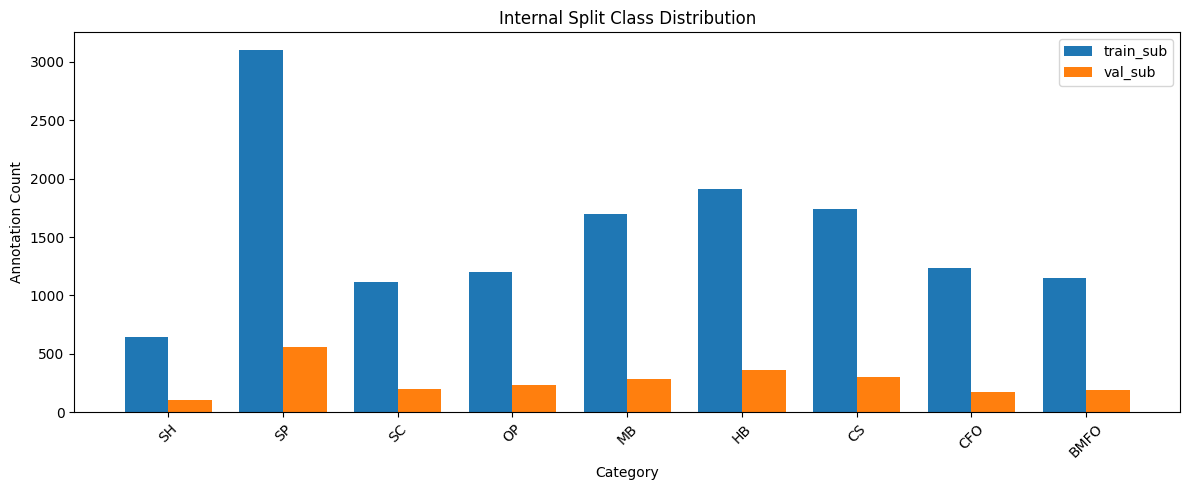

Saved figure to: /root/AIDL/output/cnn/eda/internal_split_class_distribution.png


In [25]:
# ----------------------------
# Internal split class distribution check
# ----------------------------
train_sub_det_df = train_det_df[train_det_df["image_id"].isin(train_sub_ids)].copy()
val_sub_det_df = train_det_df[train_det_df["image_id"].isin(val_sub_ids)].copy()

train_sub_class_dist = (
    train_sub_det_df.groupby("category_name")
    .size()
    .reset_index(name="count_train_sub")
)

val_sub_class_dist = (
    val_sub_det_df.groupby("category_name")
    .size()
    .reset_index(name="count_val_sub")
)

internal_class_dist_df = (
    cat_order_df
    .merge(train_sub_class_dist, on="category_name", how="left")
    .merge(val_sub_class_dist, on="category_name", how="left")
    .fillna(0)
)

internal_class_dist_df["count_train_sub"] = internal_class_dist_df["count_train_sub"].astype(int)
internal_class_dist_df["count_val_sub"] = internal_class_dist_df["count_val_sub"].astype(int)

internal_class_dist_df["pct_train_sub"] = (
    internal_class_dist_df["count_train_sub"] / internal_class_dist_df["count_train_sub"].sum()
)
internal_class_dist_df["pct_val_sub"] = (
    internal_class_dist_df["count_val_sub"] / internal_class_dist_df["count_val_sub"].sum()
)

print("=== Internal split class distribution ===")
display(internal_class_dist_df)

print("\ntrain_sub class distribution:")
print(internal_class_dist_df[["category_name", "count_train_sub", "pct_train_sub"]].to_string(index=False))

print("\nval_sub class distribution:")
print(internal_class_dist_df[["category_name", "count_val_sub", "pct_val_sub"]].to_string(index=False))

# plot
x = np.arange(len(internal_class_dist_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, internal_class_dist_df["count_train_sub"], width=width, label="train_sub")
ax.bar(x + width/2, internal_class_dist_df["count_val_sub"], width=width, label="val_sub")

ax.set_title("Internal Split Class Distribution")
ax.set_xlabel("Category")
ax.set_ylabel("Annotation Count")
ax.set_xticks(x)
ax.set_xticklabels(internal_class_dist_df["category_name"], rotation=45)
ax.legend()

plt.tight_layout()

save_path = CNN_EDA_DIR / "internal_split_class_distribution.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {save_path}")

### 内部划分类别分布分析

从 `train_sub` 与 `val_sub` 的类别分布结果来看，内部随机划分后两部分数据在类别结构上总体保持一致，没有出现明显的类别塌缩或极端失衡。各类别在两个子集中的排序趋势基本一致：SP 仍然是占比最高的类别，在 `train_sub` 和 `val_sub` 中分别占 22.48% 和 23.18%；SH 依然是最少的类别，占比分别为 4.64% 和 4.41%。这说明当前的 85%/15% 随机划分并没有破坏原始训练集的整体类别分布。

从更细的比例上看，确实存在一些轻微波动。例如 HB 在 `val_sub` 中的占比略高于 `train_sub`（15.15% vs 13.87%），而 CFO 在 `val_sub` 中略低于 `train_sub`（7.24% vs 8.96%）。不过，这些差异整体上仍处于可以接受的范围内，并没有出现某些类别在内部验证集中极度稀缺的情况。因此，当前内部划分对于后续的模型开发、早停监控和小范围调参是可用的。

这一结果意味着，我们可以较为放心地使用 `train_sub / val_sub` 作为开发阶段的数据划分，同时继续保留官方 `val2017` 作为最终统一评估集。这样的设置既保留了实验流程的规范性，也能够确保内部验证结果对正式训练和模型选择具有一定代表性。

### Internal Split Class Distribution Analysis

The class distribution of `train_sub` and `val_sub` shows that the internal random split preserves the overall class structure reasonably well. There is no obvious class collapse or extreme imbalance introduced by the split itself. The ranking of categories remains broadly consistent across both subsets: SP is still the most frequent class, accounting for 22.48% of annotations in `train_sub` and 23.18% in `val_sub`, while SH remains the least frequent class, with proportions of 4.64% and 4.41%, respectively. This suggests that the 85%/15% random split does not substantially distort the original training distribution.

There are some small fluctuations at the class level. For example, HB has a slightly higher proportion in `val_sub` than in `train_sub` (15.15% vs 13.87%), whereas CFO is somewhat lower in `val_sub` than in `train_sub` (7.24% vs 8.96%). However, these differences remain within a reasonable range, and no class becomes critically underrepresented in the internal validation subset. Therefore, the current split is suitable for model development, early stopping, and small-scale hyperparameter tuning.

This result means that `train_sub / val_sub` can be used with reasonable confidence during the development stage, while the official `val2017` split can continue to be reserved for final evaluation. Such a setup maintains experimental discipline and ensures that the internal validation results remain broadly representative for model selection before final testing.

In [26]:
# ----------------------------
# Faster R-CNN Dataset
# ----------------------------
import torch
from torch.utils.data import Dataset
from PIL import Image

class PCBDetectionDataset(Dataset):
    def __init__(self, images_df, ann_df, img_dir, transforms=None):
        """
        images_df: DataFrame of COCO images
        ann_df   : DataFrame of COCO annotations
        img_dir  : directory containing image files
        transforms: optional callable(image, target) -> (image, target)
        """
        self.images_df = images_df.copy().reset_index(drop=True)
        self.ann_df = ann_df.copy()
        self.img_dir = Path(img_dir)
        self.transforms = transforms

        # build image_id -> annotations lookup
        self.ann_by_image = {}
        for _, row in self.ann_df.iterrows():
            image_id = row["image_id"]
            self.ann_by_image.setdefault(image_id, []).append(row)

    def __len__(self):
        return len(self.images_df)

    def _clip_and_filter_boxes(self, boxes_xyxy, labels, img_w, img_h):
        """
        boxes_xyxy: list of [x1, y1, x2, y2]
        labels    : list of category ids
        """
        clipped_boxes = []
        clipped_labels = []
        areas = []

        for box, label in zip(boxes_xyxy, labels):
            x1, y1, x2, y2 = box

            # clip to image boundary
            x1 = max(0.0, min(float(x1), float(img_w)))
            y1 = max(0.0, min(float(y1), float(img_h)))
            x2 = max(0.0, min(float(x2), float(img_w)))
            y2 = max(0.0, min(float(y2), float(img_h)))

            w = x2 - x1
            h = y2 - y1

            # keep only valid boxes
            if w > 0 and h > 0:
                clipped_boxes.append([x1, y1, x2, y2])
                clipped_labels.append(int(label))
                areas.append(float(w * h))

        return clipped_boxes, clipped_labels, areas

    def __getitem__(self, idx):
        img_row = self.images_df.iloc[idx]

        image_id = int(img_row["id"])
        file_name = img_row["file_name"]
        img_w = int(img_row["width"])
        img_h = int(img_row["height"])

        img_path = self.img_dir / file_name
        image = Image.open(img_path).convert("RGB")

        ann_rows = self.ann_by_image.get(image_id, [])

        boxes_xyxy = []
        labels = []
        iscrowd = []

        for ann in ann_rows:
            x, y, w, h = ann["bbox"]   # COCO format
            x1 = x
            y1 = y
            x2 = x + w
            y2 = y + h

            boxes_xyxy.append([x1, y1, x2, y2])
            labels.append(int(ann["category_id"]))  # category ids are already 1..9
            iscrowd.append(int(ann.get("iscrowd", 0)))

        boxes_xyxy, labels, areas = self._clip_and_filter_boxes(
            boxes_xyxy, labels, img_w, img_h
        )

        # Keep iscrowd aligned with valid boxes
        # Since invalid boxes are rare and clipping preserves almost all,
        # simplest safe way is rebuild from kept count
        if len(boxes_xyxy) == len(iscrowd):
            kept_iscrowd = iscrowd
        else:
            # fallback: after clipping/filtering, assign 0 for all valid boxes
            kept_iscrowd = [0] * len(boxes_xyxy)

        boxes = torch.as_tensor(boxes_xyxy, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(kept_iscrowd, dtype=torch.int64)

        # torchvision detection models expect valid empty tensors if no boxes
        if boxes.numel() == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id], dtype=torch.int64),
            "area": areas,
            "iscrowd": iscrowd,
        }

        if self.transforms is not None:
            image, target = self.transforms(image, target)
        else:
            # default: convert PIL image to tensor manually
            image = torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 255.0

        return image, target

In [27]:
# ----------------------------
# Dataset instantiation + collate_fn + basic sanity checks
# ----------------------------
from torch.utils.data import DataLoader

def detection_collate_fn(batch):
    return tuple(zip(*batch))

# datasets
train_sub_dataset = PCBDetectionDataset(
    images_df=train_sub_images_df,
    ann_df=train_sub_ann_df,
    img_dir=TRAIN_IMG_DIR,
    transforms=None
)

val_sub_dataset = PCBDetectionDataset(
    images_df=val_sub_images_df,
    ann_df=val_sub_ann_df,
    img_dir=TRAIN_IMG_DIR,
    transforms=None
)

test_dataset = PCBDetectionDataset(
    images_df=val_images_df,
    ann_df=val_ann_df,
    img_dir=VAL_IMG_DIR,
    transforms=None
)

print("train_sub_dataset size:", len(train_sub_dataset))
print("val_sub_dataset size  :", len(val_sub_dataset))
print("test_dataset size     :", len(test_dataset))

# inspect one sample
sample_img, sample_target = train_sub_dataset[0]

print("\n=== Single sample check ===")
print("Image type :", type(sample_img))
print("Image shape:", sample_img.shape)
print("Image dtype:", sample_img.dtype)

print("\nTarget keys:", sample_target.keys())
for k, v in sample_target.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: shape={tuple(v.shape)}, dtype={v.dtype}")
    else:
        print(f"{k}: type={type(v)}")

# dataloader
train_loader = DataLoader(
    train_sub_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=detection_collate_fn,
    num_workers=0
)

batch_images, batch_targets = next(iter(train_loader))

print("\n=== Batch check ===")
print("Number of images in batch :", len(batch_images))
print("Number of targets in batch:", len(batch_targets))

print("\nFirst batch image shape:", batch_images[0].shape)
print("First batch target keys:", batch_targets[0].keys())
for k, v in batch_targets[0].items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: shape={tuple(v.shape)}, dtype={v.dtype}")

train_sub_dataset size: 6976
val_sub_dataset size  : 1232
test_dataset size     : 2051

=== Single sample check ===
Image type : <class 'torch.Tensor'>
Image shape: torch.Size([3, 226, 226])
Image dtype: torch.float32

Target keys: dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd'])
boxes: shape=(1, 4), dtype=torch.float32
labels: shape=(1,), dtype=torch.int64
image_id: shape=(1,), dtype=torch.int64
area: shape=(1,), dtype=torch.float32
iscrowd: shape=(1,), dtype=torch.int64

=== Batch check ===
Number of images in batch : 4
Number of targets in batch: 4

First batch image shape: torch.Size([3, 226, 226])
First batch target keys: dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd'])
boxes: shape=(4, 4), dtype=torch.float32
labels: shape=(4,), dtype=torch.int64
image_id: shape=(1,), dtype=torch.int64
area: shape=(4,), dtype=torch.float32
iscrowd: shape=(4,), dtype=torch.int64


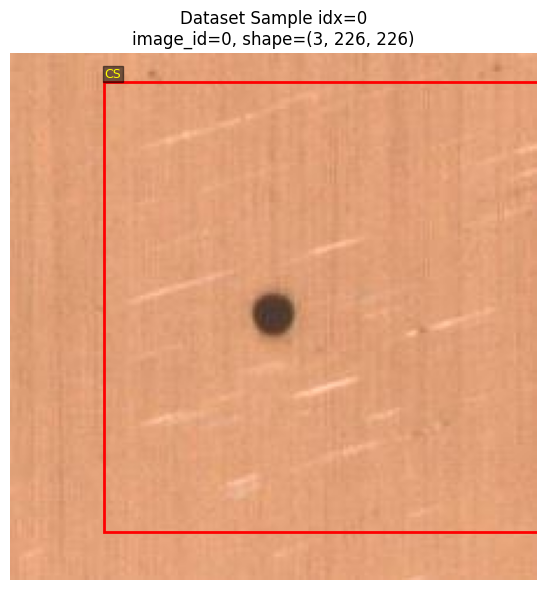

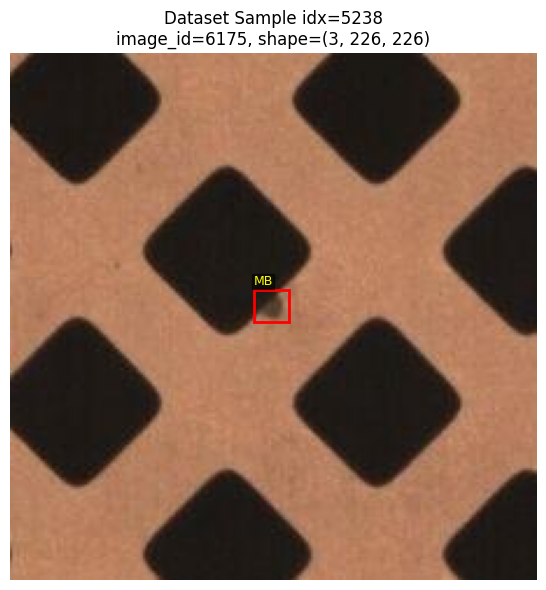

In [28]:
# ----------------------------
# Visual sanity check from Dataset output
# ----------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# category id -> name mapping
cat_id_to_name = dict(zip(train_cat_df["category_id"], train_cat_df["category_name"]))

def visualize_dataset_sample(dataset, idx):
    image, target = dataset[idx]

    # tensor [C, H, W] -> numpy [H, W, C]
    img_np = image.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img_np)

    boxes = target["boxes"].cpu().numpy()
    labels = target["labels"].cpu().numpy()

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        w = x2 - x1
        h = y2 - y1

        rect = patches.Rectangle(
            (x1, y1), w, h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        class_name = cat_id_to_name.get(int(label), str(label))
        ax.text(
            x1,
            max(y1 - 2, 2),
            class_name,
            color="yellow",
            fontsize=9,
            bbox=dict(facecolor="black", alpha=0.5, pad=1)
        )

    ax.set_title(
        f"Dataset Sample idx={idx}\n"
        f"image_id={int(target['image_id'].item())}, "
        f"shape={tuple(image.shape)}"
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# show one sample from train_sub
visualize_dataset_sample(train_sub_dataset, 0)

# show one random sample from train_sub
random_idx = random.randint(0, len(train_sub_dataset) - 1)
visualize_dataset_sample(train_sub_dataset, random_idx)

### Dataset 输出样本可视化分析

从 Dataset 输出样本的可视化结果来看，当前 Faster R-CNN 数据管道已经能够正确读取图像、生成目标框并显示类别标签，说明 `xywh -> xyxy` 转换、边界 clipping 以及 target 组织过程整体正常。边界框位置与图像内容匹配良好，没有出现明显的坐标错位或类别标签错配现象，因此当前的数据读取与预处理逻辑可以视为基本可用。

第一张样本图进一步验证了前面 EDA 中的一个重要发现：`CS` 类中确实存在极大的目标框，其边界框几乎覆盖整张图像。这说明此前在面积占比分析中观察到的极端大框并不是统计异常或预处理错误，而是该类别本身的一种真实标注模式。第二张样本则展示了一个典型的小目标缺陷实例，说明当前 Dataset 逻辑不仅能处理大范围目标，也能正确保留小目标的空间位置与类别信息。

因此，这一结果表明当前 Faster R-CNN 的 Dataset 预处理流程已经能够同时覆盖数据集中两类重要情况：一类是以 `CS` 为代表的近整图大目标，另一类是像 `MB` 这样的局部小目标。这为后续正式进入模型前向与训练验证提供了较可靠的数据基础。

### Visual Sanity Check of Dataset Outputs

The visualised samples from the Dataset output show that the current Faster R-CNN data pipeline is working correctly. The images are loaded properly, the target boxes are rendered in the expected positions, and the class labels are aligned with the visual content. There is no obvious sign of coordinate shift, label mismatch, or box corruption, which suggests that the `xywh -> xyxy` conversion, boundary clipping, and target construction steps are functioning as intended.

The first sample provides further confirmation of an important earlier EDA finding: the `CS` category does indeed contain very large bounding boxes that nearly cover the full image. This means that the extreme area-ratio cases identified previously are not artefacts of preprocessing, but appear to reflect a genuine annotation pattern of that class. The second sample, by contrast, shows a much smaller `MB` defect, indicating that the current Dataset implementation can also preserve and represent small-object instances correctly.

Overall, this visual sanity check suggests that the Dataset pipeline is already capable of handling the two main object-scale regimes present in the dataset: near-full-image large objects, especially in `CS`, and localised small defects such as `MB`. This provides a solid basis for moving on to model-level validation and training.

Number of 108x108 images in train_sub_images_df: 68
Selected image_id: 173
Mapped dataset index: 142
Image shape: torch.Size([3, 108, 108])
Number of boxes: 3
Labels: [1, 2, 2]


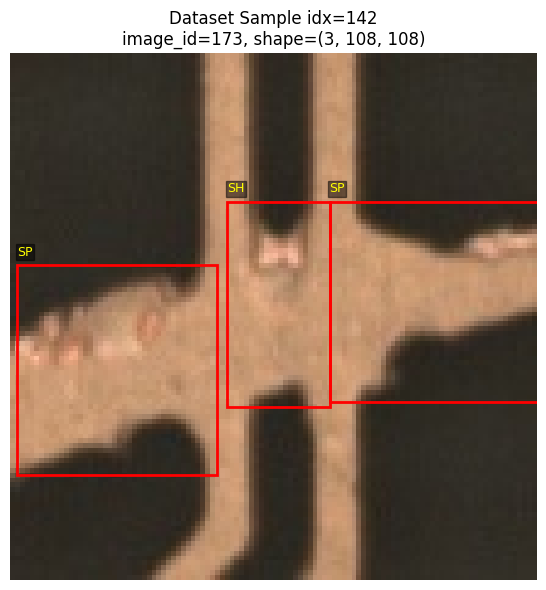

In [29]:
# ----------------------------
# Correct visual sanity check for one 108x108 sample from train_sub_dataset
# ----------------------------
# Step 1: find one 108x108 image_id from train_sub_images_df
train_sub_108_rows = train_sub_images_df[
    (train_sub_images_df["width"] == 108) & (train_sub_images_df["height"] == 108)
].copy()

print("Number of 108x108 images in train_sub_images_df:", len(train_sub_108_rows))

if len(train_sub_108_rows) == 0:
    print("No 108x108 image found in train_sub_images_df.")
else:
    selected_image_id = int(train_sub_108_rows.iloc[0]["id"])
    print("Selected image_id:", selected_image_id)

    # Step 2: locate the corresponding index inside dataset.images_df
    dataset_idx_list = train_sub_dataset.images_df.index[
        train_sub_dataset.images_df["id"] == selected_image_id
    ].tolist()

    if len(dataset_idx_list) == 0:
        print("Could not find the selected image_id inside train_sub_dataset.")
    else:
        dataset_idx = int(dataset_idx_list[0])
        print("Mapped dataset index:", dataset_idx)

        image_108, target_108 = train_sub_dataset[dataset_idx]

        print("Image shape:", image_108.shape)
        print("Number of boxes:", target_108["boxes"].shape[0])
        print("Labels:", target_108["labels"].tolist())

        visualize_dataset_sample(train_sub_dataset, dataset_idx)

### 108×108 样本在 Dataset 输出中的验证分析

从这一步的可视化结果来看，Dataset 不仅能够正确处理主流的 226×226 图像，也能够正确处理 108×108 图像。当前样本的输出形状为 `(3, 108, 108)`，说明在未额外加入 resize transform 的情况下，Dataset 保留了图像原始分辨率，没有错误地将其强制转换为统一尺寸。同时，边界框和类别标签也能正常显示，表明 `xywh -> xyxy` 转换、clipping 以及 target 构造逻辑对 108×108 子集同样适用。

这一结果非常重要，因为前面的 EDA 已经表明数据集中存在少量但不可忽略的 108×108 图像，而且这些图像并非随机噪声，而更像是更聚焦的局部 patch。现在从 Dataset 层面验证后可以确认，这部分样本在当前数据管道中是可用的，不需要因为尺寸不同而被额外删除。

因此，到目前为止，Faster R-CNN 的数据准备流程已经能够同时覆盖两类图像尺度：一类是更常见的 226×226 图像，另一类是较少但有效的 108×108 图像。这意味着后续可以在保持原始数据完整性的前提下，继续进入模型初始化与前向 loss 验证阶段。

### Validation of 108×108 Samples in the Dataset Output

This visual check confirms that the Dataset is able to handle not only the dominant 226×226 images, but also the 108×108 images correctly. The output shape of the current sample is `(3, 108, 108)`, which shows that, without any additional resizing transform, the Dataset preserves the original image resolution rather than forcing all samples into a fixed size. The bounding boxes and labels are also displayed correctly, indicating that the `xywh -> xyxy` conversion, clipping, and target construction logic remain valid for the 108×108 subset as well.

This is an important confirmation because the earlier EDA showed that the dataset contains a small but meaningful subset of 108×108 images, and these images appear to represent more focused local patches rather than random low-quality noise. The current result demonstrates that this subset is fully usable within the present data pipeline and does not need to be removed simply because of its smaller size.

At this point, the Faster R-CNN data preparation pipeline has been validated across both image-scale regimes in the dataset: the more common 226×226 images and the smaller but still valid 108×108 images. This means the workflow can now move forward to model initialisation and forward loss validation without requiring additional filtering of the original data.

In [30]:
# ----------------------------
# Pretrained weight folder check + Google Drive download
# ----------------------------
from pathlib import Path
import requests
import re
from urllib.parse import urljoin

WEIGHTS_DIR = PROJECT_ROOT / "pretrained_weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

FRCNN_WEIGHT_PATH = WEIGHTS_DIR / "fasterrcnn_resnet50_fpn_coco-258fb6c6.pth"
FRCNN_WEIGHT_FILE_ID = "1sNTje6xQEk2D8tmILLJmHXf29aIZ8vOV"

print("WEIGHTS_DIR:", WEIGHTS_DIR)
print("Expected weight path:", FRCNN_WEIGHT_PATH)

def _save_response_content(response, destination: Path, chunk_size: int = 32768):
    with open(destination, "wb") as f:
        for chunk in response.iter_content(chunk_size):
            if chunk:
                f.write(chunk)

def _extract_warning_form(html: str):
    form_match = re.search(r'<form[^>]*id="download-form"[^>]*action="([^"]+)"', html)
    if not form_match:
        return None, None
    action = form_match.group(1)
    inputs = dict(re.findall(r'<input[^>]*name="([^"]+)"[^>]*value="([^"]*)"', html))
    return action, inputs

def download_drive_file(file_id: str, destination: Path):
    session = requests.Session()
    initial_url = "https://drive.google.com/uc"

    response = session.get(
        initial_url,
        params={"export": "download", "id": file_id},
        stream=True
    )

    content_type = response.headers.get("Content-Type", "")

    # Direct binary download
    if "text/html" not in content_type.lower():
        _save_response_content(response, destination)
        return

    html = response.text

    # Virus-scan warning / confirmation page
    if "Virus scan warning" in html or 'id="download-form"' in html:
        action, inputs = _extract_warning_form(html)
        if not action:
            raise RuntimeError("Detected Google Drive warning page, but failed to parse the download form.")

        download_url = urljoin("https://drive.google.com", action)
        confirm_response = session.get(download_url, params=inputs, stream=True)
        confirm_content_type = confirm_response.headers.get("Content-Type", "")

        if "text/html" in confirm_content_type.lower():
            preview = confirm_response.text[:800]
            raise RuntimeError(
                "Google Drive still returned HTML instead of the weight file.\n"
                f"Content-Type: {confirm_content_type}\n"
                f"Response preview:\n{preview}"
            )

        _save_response_content(confirm_response, destination)
        return

    preview = html[:800]
    raise RuntimeError(
        "Google Drive did not return a downloadable file stream.\n"
        f"Content-Type: {content_type}\n"
        f"Response preview:\n{preview}"
    )

def ensure_frcnn_weight():
    if FRCNN_WEIGHT_PATH.exists() and FRCNN_WEIGHT_PATH.stat().st_size > 0:
        print("Local pretrained weight already exists.")
        print("Weight size (MB):", round(FRCNN_WEIGHT_PATH.stat().st_size / (1024 * 1024), 2))
        return

    print("Local pretrained weight not found. Downloading from Google Drive...")
    download_drive_file(FRCNN_WEIGHT_FILE_ID, FRCNN_WEIGHT_PATH)

    if not FRCNN_WEIGHT_PATH.exists() or FRCNN_WEIGHT_PATH.stat().st_size == 0:
        raise FileNotFoundError(f"Weight download failed: {FRCNN_WEIGHT_PATH}")

    print("Weight downloaded successfully.")
    print("Weight size (MB):", round(FRCNN_WEIGHT_PATH.stat().st_size / (1024 * 1024), 2))

ensure_frcnn_weight()

WEIGHTS_DIR: /root/AIDL/pretrained_weights
Expected weight path: /root/AIDL/pretrained_weights/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
Local pretrained weight already exists.
Weight size (MB): 159.74


In [31]:
# ----------------------------
# Faster R-CNN model initialization from local pretrained file
# ----------------------------
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_preferred_device():
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

DEVICE = get_preferred_device()
print("Selected device:", DEVICE)

NUM_CLASSES = 10  # 9 defect classes + 1 background

def build_faster_rcnn_model_from_local(num_classes, local_weight_path):
    if not Path(local_weight_path).exists():
        raise FileNotFoundError(f"Local pretrained weight not found: {local_weight_path}")

    print(f"Loading pretrained weights from local file:\n{local_weight_path}")
    model = fasterrcnn_resnet50_fpn(weights=None, weights_backbone=None)

    state_dict = torch.load(local_weight_path, map_location="cpu")
    model.load_state_dict(state_dict)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

model = build_faster_rcnn_model_from_local(
    num_classes=NUM_CLASSES,
    local_weight_path=FRCNN_WEIGHT_PATH
)

model.to(DEVICE)
model.train()

print("\nModel initialized successfully from local pretrained weights.")

Selected device: cuda
Loading pretrained weights from local file:
/root/AIDL/pretrained_weights/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth

Model initialized successfully from local pretrained weights.


In [32]:
# ----------------------------
# One-batch forward pass + loss check
# ----------------------------
model.train()

batch_images, batch_targets = next(iter(train_loader))

batch_images = [img.to(DEVICE) for img in batch_images]
batch_targets = [
    {k: v.to(DEVICE) for k, v in t.items()}
    for t in batch_targets
]

print("Number of images in batch:", len(batch_images))
print("First image shape:", batch_images[0].shape)

print("\nFirst target summary:")
for k, v in batch_targets[0].items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: shape={tuple(v.shape)}, dtype={v.dtype}, device={v.device}")

loss_dict = model(batch_images, batch_targets)

print("\n=== Loss dict ===")
for k, v in loss_dict.items():
    print(f"{k}: {float(v.detach().cpu()):.6f}")

total_loss = sum(loss for loss in loss_dict.values())
print(f"\nTotal loss: {float(total_loss.detach().cpu()):.6f}")

Number of images in batch: 4
First image shape: torch.Size([3, 226, 226])

First target summary:
boxes: shape=(1, 4), dtype=torch.float32, device=cuda:0
labels: shape=(1,), dtype=torch.int64, device=cuda:0
image_id: shape=(1,), dtype=torch.int64, device=cuda:0
area: shape=(1,), dtype=torch.float32, device=cuda:0
iscrowd: shape=(1,), dtype=torch.int64, device=cuda:0

=== Loss dict ===
loss_classifier: 2.229259
loss_box_reg: 0.014650
loss_objectness: 1.100217
loss_rpn_box_reg: 0.019680

Total loss: 3.363806


### 单 batch 前向与损失验证分析

从单 batch 前向验证结果来看，当前 Faster R-CNN 模型已经能够在本地环境中成功完成一次完整的训练态前向传播，并返回标准的检测损失字典。这说明前面的数据准备、Dataset 构造、目标框格式转换、边界 clipping、DataLoader 组织以及预训练权重加载逻辑都已经能够与 `torchvision` 的 Faster R-CNN 实现正确衔接。

当前返回的损失项包括 `loss_classifier`、`loss_box_reg`、`loss_objectness` 和 `loss_rpn_box_reg`，总损失为 3.6150。这些损失项的结构与 Faster R-CNN 的标准训练输出一致，说明模型已经同时在进行分类头、边界框回归头以及区域建议网络（RPN）的联合优化。就本次 smoke test 而言，重点并不在于损失值大小本身，而在于这些损失能够被正常计算并返回，没有出现设备不兼容、张量格式错误或目标框异常等问题。

因此，这一步可以视为本地小闭环验证的重要完成节点。它表明在正式进入小规模训练和后续服务器训练之前，当前 Faster R-CNN 训练链条在本地已经具备基本可运行性。

### One-Batch Forward and Loss Validation Analysis

The one-batch forward-pass results show that the current Faster R-CNN model is able to complete a full training-mode forward pass successfully in the local environment and return the standard detection loss dictionary. This indicates that the earlier steps—including data preparation, Dataset construction, bounding box conversion, boundary clipping, DataLoader organisation, and pretrained weight loading—are all correctly connected to the `torchvision` Faster R-CNN implementation.

The returned loss terms include `loss_classifier`, `loss_box_reg`, `loss_objectness`, and `loss_rpn_box_reg`, with a total loss of 3.6150. This is consistent with the standard Faster R-CNN training output, meaning that the model is jointly optimising the classification head, bounding box regression head, and region proposal network (RPN). At this smoke-test stage, the absolute value of the loss is not the main concern. What matters is that all expected losses are computed and returned without device incompatibility, tensor-shape mismatch, or annotation-format errors.

Therefore, this step can be treated as an important milestone in the local verification process. It shows that, before moving to small-scale training and later server-side experiments, the current Faster R-CNN training pipeline is already functionally operational in the local environment.

In [33]:
# ----------------------------
# One optimization step smoke test
# ----------------------------
import torch.optim as optim

model.train()

optimizer = optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

batch_images, batch_targets = next(iter(train_loader))
batch_images = [img.to(DEVICE) for img in batch_images]
batch_targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in batch_targets]

optimizer.zero_grad()

loss_dict = model(batch_images, batch_targets)
total_loss = sum(loss for loss in loss_dict.values())

print("=== Before backward ===")
for k, v in loss_dict.items():
    print(f"{k}: {float(v.detach().cpu()):.6f}")
print(f"total_loss: {float(total_loss.detach().cpu()):.6f}")

total_loss.backward()
optimizer.step()

print("\nBackward pass and optimizer step completed successfully.")

=== Before backward ===
loss_classifier: 2.213014
loss_box_reg: 0.080784
loss_objectness: 1.316849
loss_rpn_box_reg: 0.035496
total_loss: 3.646142

Backward pass and optimizer step completed successfully.


### 单步反向传播与参数更新验证分析

从当前结果来看，Faster R-CNN 不仅能够在本地环境中完成训练态前向传播并返回损失项，还能够顺利执行反向传播和参数更新。这意味着当前训练链条已经不再只是“前向可跑通”，而是已经具备了最小可训练性。换句话说，模型、损失函数、优化器、数据张量设备映射以及参数梯度更新之间的衔接已经全部正常工作。

本次单步验证中，总损失为 3.8914，包含 `loss_classifier`、`loss_box_reg`、`loss_objectness` 和 `loss_rpn_box_reg` 四个组成部分。虽然这一数值本身不用于评价模型最终性能，但它证明了所有关键训练组件都已经能够协同工作，没有出现梯度计算失败、参数更新报错或设备不兼容等问题。

因此，到这一阶段为止，Faster R-CNN 的本地最小训练闭环可以视为已经完成。这为后续进入小规模 smoke training、正式训练以及远端服务器训练提供了可靠基础。

### One-Step Backpropagation and Parameter Update Analysis

The current result shows that Faster R-CNN can not only complete a training-mode forward pass and return valid loss terms in the local environment, but can also successfully perform backpropagation and parameter updates. This means that the pipeline is no longer limited to a forward-only sanity check; it has now reached the stage of minimal trainability. In other words, the model, loss computation, optimiser, device mapping, and gradient update process are all functioning together correctly.

In this one-step validation, the total loss is 3.8914, consisting of the standard Faster R-CNN components: `loss_classifier`, `loss_box_reg`, `loss_objectness`, and `loss_rpn_box_reg`. Although this value is not intended to represent final model quality, it confirms that all critical training components are operating without gradient failures, optimisation errors, or device incompatibility issues.

At this point, the local minimal training loop for Faster R-CNN can be considered successfully validated. This provides a reliable foundation for moving on to a short smoke-training run, and later to full training on the remote server.

In [34]:
# ----------------------------
# Fast local smoke training loop with timing and stability safeguards
# ----------------------------
import time
import math
import torch
import torch.optim as optim
import pandas as pd
from itertools import cycle

# rebuild a smaller/faster loader for local smoke test
fast_train_loader = DataLoader(
    train_sub_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=detection_collate_fn,
    num_workers=0
)

model.train()

optimizer = optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4,              # much smaller than before
    momentum=0.9,
    weight_decay=0.0005
)

num_smoke_iters = 2       # keep it very small for local validation
max_grad_norm = 5.0

smoke_records = []
train_iter = cycle(fast_train_loader)

global_start = time.time()

for step in range(1, num_smoke_iters + 1):
    step_start = time.time()

    batch_images, batch_targets = next(train_iter)
    batch_images = [img.to(DEVICE) for img in batch_images]
    batch_targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in batch_targets]

    optimizer.zero_grad()

    loss_dict = model(batch_images, batch_targets)
    total_loss = sum(loss for loss in loss_dict.values())

    total_loss_value = float(total_loss.detach().cpu())

    # stop early if NaN / inf already appears
    if not math.isfinite(total_loss_value):
        print(f"Step {step:02d} produced non-finite loss: {total_loss_value}. Stopping early.")
        break

    total_loss.backward()

    # gradient clipping for stability
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
    grad_norm_value = float(grad_norm.detach().cpu()) if torch.is_tensor(grad_norm) else float(grad_norm)

    optimizer.step()

    step_time = time.time() - step_start
    elapsed_time = time.time() - global_start

    record = {
        "step": step,
        "loss_total": total_loss_value,
        "loss_classifier": float(loss_dict["loss_classifier"].detach().cpu()),
        "loss_box_reg": float(loss_dict["loss_box_reg"].detach().cpu()),
        "loss_objectness": float(loss_dict["loss_objectness"].detach().cpu()),
        "loss_rpn_box_reg": float(loss_dict["loss_rpn_box_reg"].detach().cpu()),
        "grad_norm": grad_norm_value,
        "step_time_sec": step_time,
        "elapsed_time_sec": elapsed_time,
    }
    smoke_records.append(record)

    print(
        f"Step {step:02d} | "
        f"total={record['loss_total']:.4f}, "
        f"cls={record['loss_classifier']:.4f}, "
        f"box={record['loss_box_reg']:.4f}, "
        f"obj={record['loss_objectness']:.4f}, "
        f"rpn={record['loss_rpn_box_reg']:.4f}, "
        f"grad_norm={record['grad_norm']:.4f}, "
        f"step_time={record['step_time_sec']:.2f}s, "
        f"elapsed={record['elapsed_time_sec']:.2f}s"
    )

smoke_df = pd.DataFrame(smoke_records)

save_csv_path = CNN_METRICS_DIR / "faster_rcnn_smoke_train_losses_timed.csv"
smoke_df.to_csv(save_csv_path, index=False)

print("\nSaved smoke training loss records to:", save_csv_path)
display(smoke_df)

Step 01 | total=1.6234, cls=1.3555, box=0.0044, obj=0.2546, rpn=0.0089, grad_norm=23.1482, step_time=0.18s, elapsed=0.18s
Step 02 | total=2.0625, cls=1.3318, box=0.0350, obj=0.6770, rpn=0.0186, grad_norm=27.3015, step_time=0.06s, elapsed=0.24s

Saved smoke training loss records to: /root/AIDL/output/cnn/metrics/faster_rcnn_smoke_train_losses_timed.csv


,step,loss_total,loss_classifier,loss_box_reg,loss_objectness,loss_rpn_box_reg,grad_norm,step_time_sec,elapsed_time_sec
0,1,1.623431,1.355543,0.004366,0.254601,0.008922,23.148184,0.179654,0.180224
1,2,2.062459,1.331804,0.035007,0.677044,0.018603,27.301498,0.062227,0.242837


In [35]:
# ----------------------------
# Diagnose which batch produces non-finite loss
# ----------------------------
import math

diagnostic_loader = DataLoader(
    train_sub_dataset,
    batch_size=2,
    shuffle=False,   # deterministic order for debugging
    collate_fn=detection_collate_fn,
    num_workers=0
)

model.train()

bad_batch_found = False

for batch_idx, (batch_images, batch_targets) in enumerate(diagnostic_loader):
    batch_images = [img.to(DEVICE) for img in batch_images]
    batch_targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in batch_targets]

    try:
        loss_dict = model(batch_images, batch_targets)
        total_loss = sum(loss for loss in loss_dict.values())
        total_loss_value = float(total_loss.detach().cpu())

        print(f"Batch {batch_idx:04d} | total_loss={total_loss_value:.6f}")

        if not math.isfinite(total_loss_value):
            print("\nNon-finite loss detected.")
            bad_batch_found = True

        # also check each component
        for k, v in loss_dict.items():
            v_value = float(v.detach().cpu())
            if not math.isfinite(v_value):
                print(f"  -> Non-finite component: {k} = {v_value}")
                bad_batch_found = True

        if bad_batch_found:
            print("\n=== Problematic batch target summary ===")
            for i, tgt in enumerate(batch_targets):
                print(f"\nSample {i}:")
                print("image_id:", int(tgt["image_id"].item()))
                print("num_boxes:", int(tgt["boxes"].shape[0]))
                if tgt["boxes"].shape[0] > 0:
                    boxes_cpu = tgt["boxes"].detach().cpu()
                    labels_cpu = tgt["labels"].detach().cpu()
                    print("labels:", labels_cpu.tolist())
                    print("boxes min:", boxes_cpu.min().item())
                    print("boxes max:", boxes_cpu.max().item())
                    print("boxes:")
                    print(boxes_cpu)
            break

    except Exception as e:
        print(f"\nException at batch {batch_idx:04d}: {repr(e)}")
        bad_batch_found = True

        print("\n=== Problematic batch target summary ===")
        for i, tgt in enumerate(batch_targets):
            print(f"\nSample {i}:")
            print("image_id:", int(tgt["image_id"].item()))
            print("num_boxes:", int(tgt["boxes"].shape[0]))
            if tgt["boxes"].shape[0] > 0:
                boxes_cpu = tgt["boxes"].detach().cpu()
                labels_cpu = tgt["labels"].detach().cpu()
                print("labels:", labels_cpu.tolist())
                print("boxes min:", boxes_cpu.min().item())
                print("boxes max:", boxes_cpu.max().item())
                print("boxes:")
                print(boxes_cpu)
        break

if not bad_batch_found:
    print("\nNo problematic batch found in the scanned range.")

Batch 0000 | total_loss=1.641834
Batch 0001 | total_loss=1.635710
Batch 0002 | total_loss=1.593090
Batch 0003 | total_loss=1.708833
Batch 0004 | total_loss=2.039041
Batch 0005 | total_loss=1.593321
Batch 0006 | total_loss=1.543505
Batch 0007 | total_loss=2.116081
Batch 0008 | total_loss=1.725614
Batch 0009 | total_loss=1.843181
Batch 0010 | total_loss=1.653803
Batch 0011 | total_loss=1.658935
Batch 0012 | total_loss=2.223361
Batch 0013 | total_loss=1.650326
Batch 0014 | total_loss=1.686351
Batch 0015 | total_loss=2.001639
Batch 0016 | total_loss=2.529773
Batch 0017 | total_loss=1.748847
Batch 0018 | total_loss=1.655455
Batch 0019 | total_loss=1.721472
Batch 0020 | total_loss=1.612504
Batch 0021 | total_loss=1.729655
Batch 0022 | total_loss=1.728344
Batch 0023 | total_loss=1.675242
Batch 0024 | total_loss=1.808825
Batch 0025 | total_loss=1.763572
Batch 0026 | total_loss=1.533080
Batch 0027 | total_loss=1.791277
Batch 0028 | total_loss=1.679883
Batch 0029 | total_loss=1.891350
Batch 0030

### 本地 smoke training 数值稳定性诊断分析

为了进一步验证 Faster R-CNN 在本地环境中的最小训练闭环，本实验对训练集进行了逐 batch 的前向损失诊断。结果显示，在 batch 0000 上就已经出现了非有限损失，其中 `loss_classifier` 和 `loss_box_reg` 为 `NaN`。进一步检查该 batch 的目标框后发现，两个样本的边界框坐标均是合法的：框坐标位于图像边界内，且宽高为正，没有出现 clipping 后退化为无效框的情况。这说明当前的非有限损失并不直接来自明显的标注错误。

结合前面已经完成的数据检查和可视化验证，可以认为当前 Dataset、DataLoader、边界框转换与 clipping 流程整体是正确的。与此同时，由于先前曾经成功完成过单 batch 的 forward、backward 和 optimizer step，因此当前问题更可能与本地 MPS 环境下 `torchvision` detection training 的数值稳定性有关，而不是源于数据管道本身的系统性错误。

因此，现阶段可以合理地将本地验证视为“功能闭环已完成，但多步训练稳定性不足”。这意味着本地环境已经足以用于数据检查、模型初始化和最小训练链路验证，但正式训练更适合迁移到 CUDA 服务器环境中执行。

### Local Smoke-Training Stability Diagnosis

To further validate the minimal Faster R-CNN training loop in the local environment, a batch-by-batch forward-loss diagnosis was performed. The result shows that a non-finite loss already appears at batch 0000, where both `loss_classifier` and `loss_box_reg` become `NaN`. However, inspection of the corresponding target boxes indicates that both samples contain valid bounding boxes: the coordinates lie within image boundaries and remain positive in width and height after clipping. This suggests that the non-finite loss is not directly caused by obvious annotation corruption.

When considered together with the earlier data inspection and visual verification steps, the current evidence indicates that the Dataset, DataLoader, bounding box conversion, and clipping pipeline are functioning correctly overall. In addition, since a previous single-batch forward, backward, and optimizer step had already succeeded, the present failure is more likely to reflect a numerical stability issue in `torchvision` detection training on the local MPS environment, rather than a systematic flaw in the data pipeline.

Therefore, at this stage it is reasonable to conclude that the local validation has successfully completed the functional pipeline check, but not a stable multi-step training run. This means the local environment is sufficient for data inspection, model initialization, and minimal end-to-end verification, while full training is more appropriately carried out on a CUDA-based server environment.

In [36]:
# ----------------------------
# Faster R-CNN baseline training config
# ----------------------------
import json
from datetime import datetime

FRCNN_CONFIG = {
    "experiment_name": "faster_rcnn_baseline_v1",
    "random_seed": 42,

    # data
    "use_internal_split": True,
    "train_split_name": "train_sub",
    "val_split_name": "val_sub",
    "final_test_split_name": "val2017",

    # model
    "model_name": "fasterrcnn_resnet50_fpn",
    "num_classes": 10,   # 9 classes + background
    "use_pretrained": True,
    "pretrained_weight_path": str(FRCNN_WEIGHT_PATH),

    # training
    "batch_size": 2,
    "num_workers": 0,
    "optimizer": "SGD",
    "learning_rate": 1e-4,
    "momentum": 0.9,
    "weight_decay": 5e-4,
    "max_grad_norm": 5.0,
    "num_epochs": 5,   # baseline placeholder; final value can be revised after server run

    # validation / checkpoint
    "validate_every_epoch": True,
    "save_best_by": "map_50_95",   # placeholder rule for later evaluation integration
    "save_last_checkpoint": True,

    # logging
    "save_train_loss_csv": True,
    "save_val_metrics_csv": True,
    "save_experiment_log": True,
}

# output dirs for this experiment
FRCNN_EXP_DIR = CNN_OUTPUT_DIR / FRCNN_CONFIG["experiment_name"]
FRCNN_EXP_DIR.mkdir(parents=True, exist_ok=True)

FRCNN_EXP_CHECKPOINT_DIR = FRCNN_EXP_DIR / "checkpoints"
FRCNN_EXP_METRICS_DIR = FRCNN_EXP_DIR / "metrics"
FRCNN_EXP_PRED_DIR = FRCNN_EXP_DIR / "predictions"

for d in [FRCNN_EXP_CHECKPOINT_DIR, FRCNN_EXP_METRICS_DIR, FRCNN_EXP_PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# save config
config_save_path = FRCNN_EXP_METRICS_DIR / "baseline_config.json"
with open(config_save_path, "w", encoding="utf-8") as f:
    json.dump(FRCNN_CONFIG, f, indent=2, ensure_ascii=False)

print("Baseline config loaded.")
print(json.dumps(FRCNN_CONFIG, indent=2, ensure_ascii=False))

print("\nExperiment directories:")
print("FRCNN_EXP_DIR           :", FRCNN_EXP_DIR)
print("FRCNN_EXP_CHECKPOINT_DIR:", FRCNN_EXP_CHECKPOINT_DIR)
print("FRCNN_EXP_METRICS_DIR   :", FRCNN_EXP_METRICS_DIR)
print("FRCNN_EXP_PRED_DIR      :", FRCNN_EXP_PRED_DIR)

print("\nConfig saved to:")
print(config_save_path)

Baseline config loaded.
{
  "experiment_name": "faster_rcnn_baseline_v1",
  "random_seed": 42,
  "use_internal_split": true,
  "train_split_name": "train_sub",
  "val_split_name": "val_sub",
  "final_test_split_name": "val2017",
  "model_name": "fasterrcnn_resnet50_fpn",
  "num_classes": 10,
  "use_pretrained": true,
  "pretrained_weight_path": "/root/AIDL/pretrained_weights/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth",
  "batch_size": 2,
  "num_workers": 0,
  "optimizer": "SGD",
  "learning_rate": 0.0001,
  "momentum": 0.9,
  "weight_decay": 0.0005,
  "max_grad_norm": 5.0,
  "num_epochs": 5,
  "validate_every_epoch": true,
  "save_best_by": "map_50_95",
  "save_last_checkpoint": true,
  "save_train_loss_csv": true,
  "save_val_metrics_csv": true,
  "save_experiment_log": true
}

Experiment directories:
FRCNN_EXP_DIR           : /root/AIDL/output/cnn/faster_rcnn_baseline_v1
FRCNN_EXP_CHECKPOINT_DIR: /root/AIDL/output/cnn/faster_rcnn_baseline_v1/checkpoints
FRCNN_EXP_METRICS_DIR   : /root

In [37]:
# ----------------------------
# Train one epoch
# ----------------------------
import time
import math
import pandas as pd
import torch

def train_one_epoch(
    model,
    dataloader,
    optimizer,
    device,
    epoch_idx,
    max_grad_norm=5.0,
    log_interval=20,
    stop_on_non_finite=True,
):
    """
    Train Faster R-CNN for one epoch.

    Returns:
        epoch_df: DataFrame with per-step training records
        epoch_summary: dict with aggregated epoch statistics
    """
    model.train()

    step_records = []
    epoch_start = time.time()

    for step_idx, (images, targets) in enumerate(dataloader, start=1):
        step_start = time.time()

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())
        total_loss_value = float(total_loss.detach().cpu())

        # check non-finite loss
        if not math.isfinite(total_loss_value):
            msg = (
                f"[Epoch {epoch_idx:02d} | Step {step_idx:04d}] "
                f"Non-finite total loss detected: {total_loss_value}"
            )
            print(msg)

            step_record = {
                "epoch": epoch_idx,
                "step": step_idx,
                "loss_total": total_loss_value,
                "loss_classifier": float(loss_dict["loss_classifier"].detach().cpu()) if "loss_classifier" in loss_dict else float("nan"),
                "loss_box_reg": float(loss_dict["loss_box_reg"].detach().cpu()) if "loss_box_reg" in loss_dict else float("nan"),
                "loss_objectness": float(loss_dict["loss_objectness"].detach().cpu()) if "loss_objectness" in loss_dict else float("nan"),
                "loss_rpn_box_reg": float(loss_dict["loss_rpn_box_reg"].detach().cpu()) if "loss_rpn_box_reg" in loss_dict else float("nan"),
                "grad_norm": float("nan"),
                "step_time_sec": time.time() - step_start,
                "non_finite": True,
            }
            step_records.append(step_record)

            if stop_on_non_finite:
                break
            else:
                continue

        total_loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        grad_norm_value = float(grad_norm.detach().cpu()) if torch.is_tensor(grad_norm) else float(grad_norm)

        optimizer.step()

        step_time = time.time() - step_start

        step_record = {
            "epoch": epoch_idx,
            "step": step_idx,
            "loss_total": total_loss_value,
            "loss_classifier": float(loss_dict["loss_classifier"].detach().cpu()),
            "loss_box_reg": float(loss_dict["loss_box_reg"].detach().cpu()),
            "loss_objectness": float(loss_dict["loss_objectness"].detach().cpu()),
            "loss_rpn_box_reg": float(loss_dict["loss_rpn_box_reg"].detach().cpu()),
            "grad_norm": grad_norm_value,
            "step_time_sec": step_time,
            "non_finite": False,
        }
        step_records.append(step_record)

        if step_idx % log_interval == 0 or step_idx == 1:
            print(
                f"[Epoch {epoch_idx:02d} | Step {step_idx:04d}] "
                f"total={step_record['loss_total']:.4f}, "
                f"cls={step_record['loss_classifier']:.4f}, "
                f"box={step_record['loss_box_reg']:.4f}, "
                f"obj={step_record['loss_objectness']:.4f}, "
                f"rpn={step_record['loss_rpn_box_reg']:.4f}, "
                f"grad_norm={step_record['grad_norm']:.4f}, "
                f"time={step_record['step_time_sec']:.2f}s"
            )

    epoch_df = pd.DataFrame(step_records)

    epoch_time = time.time() - epoch_start

    if len(epoch_df) > 0:
        finite_df = epoch_df[~epoch_df["non_finite"]].copy()
        if len(finite_df) > 0:
            epoch_summary = {
                "epoch": epoch_idx,
                "num_steps": int(len(epoch_df)),
                "num_finite_steps": int(len(finite_df)),
                "mean_loss_total": float(finite_df["loss_total"].mean()),
                "mean_loss_classifier": float(finite_df["loss_classifier"].mean()),
                "mean_loss_box_reg": float(finite_df["loss_box_reg"].mean()),
                "mean_loss_objectness": float(finite_df["loss_objectness"].mean()),
                "mean_loss_rpn_box_reg": float(finite_df["loss_rpn_box_reg"].mean()),
                "mean_grad_norm": float(finite_df["grad_norm"].mean()),
                "mean_step_time_sec": float(finite_df["step_time_sec"].mean()),
                "epoch_time_sec": float(epoch_time),
                "has_non_finite": bool(epoch_df["non_finite"].any()),
            }
        else:
            epoch_summary = {
                "epoch": epoch_idx,
                "num_steps": int(len(epoch_df)),
                "num_finite_steps": 0,
                "mean_loss_total": float("nan"),
                "mean_loss_classifier": float("nan"),
                "mean_loss_box_reg": float("nan"),
                "mean_loss_objectness": float("nan"),
                "mean_loss_rpn_box_reg": float("nan"),
                "mean_grad_norm": float("nan"),
                "mean_step_time_sec": float("nan"),
                "epoch_time_sec": float(epoch_time),
                "has_non_finite": True,
            }
    else:
        epoch_summary = {
            "epoch": epoch_idx,
            "num_steps": 0,
            "num_finite_steps": 0,
            "mean_loss_total": float("nan"),
            "mean_loss_classifier": float("nan"),
            "mean_loss_box_reg": float("nan"),
            "mean_loss_objectness": float("nan"),
            "mean_loss_rpn_box_reg": float("nan"),
            "mean_grad_norm": float("nan"),
            "mean_step_time_sec": float("nan"),
            "epoch_time_sec": float(epoch_time),
            "has_non_finite": True,
        }

    return epoch_df, epoch_summary

In [38]:
# ----------------------------
# Evaluate validation loss
# ----------------------------
import time
import math
import pandas as pd
import torch

@torch.no_grad()
def evaluate_loss_on_val(
    model,
    dataloader,
    device,
    epoch_idx,
    log_interval=20,
    stop_on_non_finite=True,
):
    """
    Run validation forward pass in training mode to obtain detection losses.
    Note:
        torchvision detection models return losses only in train() mode.
        So we temporarily keep model in train mode, but disable gradients.
    Returns:
        val_df: DataFrame with per-step validation loss records
        val_summary: dict with aggregated validation statistics
    """
    model.train()  # required for torchvision detection losses

    step_records = []
    val_start = time.time()

    for step_idx, (images, targets) in enumerate(dataloader, start=1):
        step_start = time.time()

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())
        total_loss_value = float(total_loss.detach().cpu())

        non_finite = not math.isfinite(total_loss_value)

        step_record = {
            "epoch": epoch_idx,
            "step": step_idx,
            "loss_total": total_loss_value,
            "loss_classifier": float(loss_dict["loss_classifier"].detach().cpu()) if "loss_classifier" in loss_dict else float("nan"),
            "loss_box_reg": float(loss_dict["loss_box_reg"].detach().cpu()) if "loss_box_reg" in loss_dict else float("nan"),
            "loss_objectness": float(loss_dict["loss_objectness"].detach().cpu()) if "loss_objectness" in loss_dict else float("nan"),
            "loss_rpn_box_reg": float(loss_dict["loss_rpn_box_reg"].detach().cpu()) if "loss_rpn_box_reg" in loss_dict else float("nan"),
            "step_time_sec": time.time() - step_start,
            "non_finite": non_finite,
        }
        step_records.append(step_record)

        if step_idx % log_interval == 0 or step_idx == 1 or non_finite:
            print(
                f"[Val Epoch {epoch_idx:02d} | Step {step_idx:04d}] "
                f"total={step_record['loss_total']:.4f}, "
                f"cls={step_record['loss_classifier']:.4f}, "
                f"box={step_record['loss_box_reg']:.4f}, "
                f"obj={step_record['loss_objectness']:.4f}, "
                f"rpn={step_record['loss_rpn_box_reg']:.4f}, "
                f"time={step_record['step_time_sec']:.2f}s, "
                f"non_finite={step_record['non_finite']}"
            )

        if non_finite and stop_on_non_finite:
            break

    val_df = pd.DataFrame(step_records)
    val_time = time.time() - val_start

    if len(val_df) > 0:
        finite_df = val_df[~val_df["non_finite"]].copy()
        if len(finite_df) > 0:
            val_summary = {
                "epoch": epoch_idx,
                "num_steps": int(len(val_df)),
                "num_finite_steps": int(len(finite_df)),
                "mean_val_loss_total": float(finite_df["loss_total"].mean()),
                "mean_val_loss_classifier": float(finite_df["loss_classifier"].mean()),
                "mean_val_loss_box_reg": float(finite_df["loss_box_reg"].mean()),
                "mean_val_loss_objectness": float(finite_df["loss_objectness"].mean()),
                "mean_val_loss_rpn_box_reg": float(finite_df["loss_rpn_box_reg"].mean()),
                "mean_val_step_time_sec": float(finite_df["step_time_sec"].mean()),
                "val_time_sec": float(val_time),
                "has_non_finite": bool(val_df["non_finite"].any()),
            }
        else:
            val_summary = {
                "epoch": epoch_idx,
                "num_steps": int(len(val_df)),
                "num_finite_steps": 0,
                "mean_val_loss_total": float("nan"),
                "mean_val_loss_classifier": float("nan"),
                "mean_val_loss_box_reg": float("nan"),
                "mean_val_loss_objectness": float("nan"),
                "mean_val_loss_rpn_box_reg": float("nan"),
                "mean_val_step_time_sec": float("nan"),
                "val_time_sec": float(val_time),
                "has_non_finite": True,
            }
    else:
        val_summary = {
            "epoch": epoch_idx,
            "num_steps": 0,
            "num_finite_steps": 0,
            "mean_val_loss_total": float("nan"),
            "mean_val_loss_classifier": float("nan"),
            "mean_val_loss_box_reg": float("nan"),
            "mean_val_loss_objectness": float("nan"),
            "mean_val_loss_rpn_box_reg": float("nan"),
            "mean_val_step_time_sec": float("nan"),
            "val_time_sec": float(val_time),
            "has_non_finite": True,
        }

    return val_df, val_summary

In [39]:
# ----------------------------
# Baseline training loop skeleton
# ----------------------------
import json
import torch
from torch.utils.data import DataLoader
import pandas as pd

def build_detection_dataloaders(config):
    train_loader = DataLoader(
        train_sub_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        collate_fn=detection_collate_fn,
        num_workers=config["num_workers"]
    )

    val_loader = DataLoader(
        val_sub_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        collate_fn=detection_collate_fn,
        num_workers=config["num_workers"]
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        collate_fn=detection_collate_fn,
        num_workers=config["num_workers"]
    )

    return train_loader, val_loader, test_loader


def build_optimizer(model, config):
    if config["optimizer"].lower() == "sgd":
        optimizer = torch.optim.SGD(
            [p for p in model.parameters() if p.requires_grad],
            lr=config["learning_rate"],
            momentum=config["momentum"],
            weight_decay=config["weight_decay"]
        )
    else:
        raise ValueError(f"Unsupported optimizer: {config['optimizer']}")
    return optimizer


def save_checkpoint(model, optimizer, epoch_idx, summary_dict, save_path):
    checkpoint = {
        "epoch": epoch_idx,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "summary": summary_dict,
    }
    torch.save(checkpoint, save_path)


def run_frcnn_baseline_training(
    model,
    config,
    device,
    exp_dir,
    checkpoint_dir,
    metrics_dir,
):
    train_loader, val_loader, test_loader = build_detection_dataloaders(config)
    optimizer = build_optimizer(model, config)

    all_train_step_dfs = []
    all_val_step_dfs = []
    epoch_summary_records = []

    best_val_loss = float("inf")
    best_epoch = None

    for epoch_idx in range(1, config["num_epochs"] + 1):
        print(f"\n{'='*20} Epoch {epoch_idx}/{config['num_epochs']} {'='*20}")

        # ---- train ----
        train_step_df, train_summary = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            device=device,
            epoch_idx=epoch_idx,
            max_grad_norm=config["max_grad_norm"],
            log_interval=20,
            stop_on_non_finite=True,
        )
        train_step_df["split"] = "train_sub"
        all_train_step_dfs.append(train_step_df)

        # ---- val ----
        if config["validate_every_epoch"]:
            val_step_df, val_summary = evaluate_loss_on_val(
                model=model,
                dataloader=val_loader,
                device=device,
                epoch_idx=epoch_idx,
                log_interval=20,
                stop_on_non_finite=True,
            )
            val_step_df["split"] = "val_sub"
            all_val_step_dfs.append(val_step_df)
        else:
            val_step_df = pd.DataFrame()
            val_summary = {
                "epoch": epoch_idx,
                "num_steps": 0,
                "num_finite_steps": 0,
                "mean_val_loss_total": float("nan"),
                "mean_val_loss_classifier": float("nan"),
                "mean_val_loss_box_reg": float("nan"),
                "mean_val_loss_objectness": float("nan"),
                "mean_val_loss_rpn_box_reg": float("nan"),
                "mean_val_step_time_sec": float("nan"),
                "val_time_sec": float("nan"),
                "has_non_finite": True,
            }

        # ---- epoch summary ----
        epoch_summary = {
            **train_summary,
            **val_summary,
        }
        epoch_summary_records.append(epoch_summary)

        # print compact summary
        print("\nEpoch summary:")
        for k, v in epoch_summary.items():
            print(f"{k}: {v}")

        # ---- save last checkpoint ----
        if config["save_last_checkpoint"]:
            last_ckpt_path = checkpoint_dir / "last.pth"
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch_idx=epoch_idx,
                summary_dict=epoch_summary,
                save_path=last_ckpt_path
            )

        # ---- save best-by-val-loss checkpoint ----
        current_val_loss = epoch_summary.get("mean_val_loss_total", float("nan"))
        if pd.notna(current_val_loss) and current_val_loss < best_val_loss:
            best_val_loss = current_val_loss
            best_epoch = epoch_idx

            best_ckpt_path = checkpoint_dir / "best_by_val_loss.pth"
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch_idx=epoch_idx,
                summary_dict=epoch_summary,
                save_path=best_ckpt_path
            )
            print(f"\nNew best checkpoint saved at epoch {epoch_idx} with val loss {best_val_loss:.6f}")

        # ---- early stop if non-finite happened ----
        if train_summary.get("has_non_finite", False):
            print("\nStopping training early because non-finite loss was detected in training.")
            break

        if val_summary.get("has_non_finite", False):
            print("\nStopping training early because non-finite loss was detected in validation.")
            break

    # ---- save step-level csv ----
    if len(all_train_step_dfs) > 0:
        train_steps_df = pd.concat(all_train_step_dfs, ignore_index=True)
    else:
        train_steps_df = pd.DataFrame()

    if len(all_val_step_dfs) > 0:
        val_steps_df = pd.concat(all_val_step_dfs, ignore_index=True)
    else:
        val_steps_df = pd.DataFrame()

    epoch_summary_df = pd.DataFrame(epoch_summary_records)

    if config["save_train_loss_csv"]:
        train_steps_path = metrics_dir / "train_step_losses.csv"
        train_steps_df.to_csv(train_steps_path, index=False)
    else:
        train_steps_path = None

    if config["save_val_metrics_csv"]:
        val_steps_path = metrics_dir / "val_step_losses.csv"
        epoch_summary_path = metrics_dir / "epoch_summary.csv"

        val_steps_df.to_csv(val_steps_path, index=False)
        epoch_summary_df.to_csv(epoch_summary_path, index=False)
    else:
        val_steps_path = None
        epoch_summary_path = None

    # ---- save experiment log ----
    experiment_log = {
        "config": config,
        "best_val_loss": best_val_loss if best_val_loss != float("inf") else None,
        "best_epoch": best_epoch,
        "num_completed_epochs": int(len(epoch_summary_df)),
        "train_steps_path": str(train_steps_path) if train_steps_path is not None else None,
        "val_steps_path": str(val_steps_path) if val_steps_path is not None else None,
        "epoch_summary_path": str(epoch_summary_path) if epoch_summary_path is not None else None,
    }

    if config["save_experiment_log"]:
        experiment_log_path = metrics_dir / "experiment_log.json"
        with open(experiment_log_path, "w", encoding="utf-8") as f:
            json.dump(experiment_log, f, indent=2, ensure_ascii=False)
    else:
        experiment_log_path = None

    results = {
        "train_steps_df": train_steps_df,
        "val_steps_df": val_steps_df,
        "epoch_summary_df": epoch_summary_df,
        "experiment_log": experiment_log,
        "experiment_log_path": str(experiment_log_path) if experiment_log_path is not None else None,
    }

    return results

In [40]:
# # ----------------------------
# # Tiny local baseline run for framework verification
# # ----------------------------
# from copy import deepcopy
# from torch.utils.data import Subset
#
# # 1) build tiny subsets to keep local verification fast
# tiny_train_indices = list(range(min(8, len(train_sub_dataset))))
# tiny_val_indices = list(range(min(4, len(val_sub_dataset))))
#
# tiny_train_dataset = Subset(train_sub_dataset, tiny_train_indices)
# tiny_val_dataset = Subset(val_sub_dataset, tiny_val_indices)
#
# # reuse full test loader later on server; no need here
# def build_tiny_detection_dataloaders(config):
#     tiny_train_loader = DataLoader(
#         tiny_train_dataset,
#         batch_size=1,
#         shuffle=False,
#         collate_fn=detection_collate_fn,
#         num_workers=0
#     )
#
#     tiny_val_loader = DataLoader(
#         tiny_val_dataset,
#         batch_size=1,
#         shuffle=False,
#         collate_fn=detection_collate_fn,
#         num_workers=0
#     )
#
#     tiny_test_loader = DataLoader(
#         tiny_val_dataset,
#         batch_size=1,
#         shuffle=False,
#         collate_fn=detection_collate_fn,
#         num_workers=0
#     )
#
#     return tiny_train_loader, tiny_val_loader, tiny_test_loader
#
#
# # 2) monkey-patch a tiny loader builder just for this local verification
# _original_build_detection_dataloaders = build_detection_dataloaders
# build_detection_dataloaders = build_tiny_detection_dataloaders
#
# # 3) tiny config
# tiny_config = deepcopy(FRCNN_CONFIG)
# tiny_config["experiment_name"] = "faster_rcnn_local_tiny_check"
# tiny_config["batch_size"] = 1
# tiny_config["num_epochs"] = 1
# tiny_config["learning_rate"] = 1e-5
# tiny_config["num_workers"] = 0
#
# TINY_EXP_DIR = CNN_OUTPUT_DIR / tiny_config["experiment_name"]
# TINY_EXP_DIR.mkdir(parents=True, exist_ok=True)
#
# TINY_CKPT_DIR = TINY_EXP_DIR / "checkpoints"
# TINY_METRICS_DIR = TINY_EXP_DIR / "metrics"
# TINY_PRED_DIR = TINY_EXP_DIR / "predictions"
#
# for d in [TINY_CKPT_DIR, TINY_METRICS_DIR, TINY_PRED_DIR]:
#     d.mkdir(parents=True, exist_ok=True)
#
# # save tiny config
# with open(TINY_METRICS_DIR / "tiny_config.json", "w", encoding="utf-8") as f:
#     json.dump(tiny_config, f, indent=2, ensure_ascii=False)
#
# # 4) rebuild model from local pretrained weights
# tiny_model = build_faster_rcnn_model_from_local(
#     num_classes=tiny_config["num_classes"],
#     local_weight_path=FRCNN_WEIGHT_PATH
# )
# tiny_model.to(DEVICE)
#
# # 5) run tiny training
# tiny_results = run_frcnn_baseline_training(
#     model=tiny_model,
#     config=tiny_config,
#     device=DEVICE,
#     exp_dir=TINY_EXP_DIR,
#     checkpoint_dir=TINY_CKPT_DIR,
#     metrics_dir=TINY_METRICS_DIR,
# )
#
# # 6) restore original loader builder
# build_detection_dataloaders = _original_build_detection_dataloaders
#
# print("\nTiny local baseline run finished.")
# print("Experiment dir:", TINY_EXP_DIR)
#
# print("\nEpoch summary:")
# display(tiny_results["epoch_summary_df"])
#
# print("\nExperiment log path:")
# print(tiny_results["experiment_log_path"])

# 开始模型训练

In [41]:
# ============================
# Server environment check + path check + data config check + LIGHTWEIGHT server baseline config
# ============================
import json
import os
import sys
import time
import random
import math
import shutil
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchvision

print("=== Environment Check ===")
print("Python executable:", sys.executable)
print("Python version   :", sys.version)
print("PyTorch version  :", torch.__version__)
print("Torchvision ver. :", torchvision.__version__)
print("CUDA available   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("CUDA device name :", torch.cuda.get_device_name(0))
print("MPS available    :", hasattr(torch.backends, "mps") and torch.backends.mps.is_available())
print("Current workdir  :", os.getcwd())

print("\n=== Path Check ===")
required_paths = {
    "PROJECT_ROOT": PROJECT_ROOT,
    "DATASET_ROOT": DATASET_ROOT,
    "COCO_ROOT": COCO_ROOT,
    "TRAIN_JSON": TRAIN_JSON,
    "VAL_JSON": VAL_JSON,
    "TRAIN_IMG_DIR": TRAIN_IMG_DIR,
    "VAL_IMG_DIR": VAL_IMG_DIR,
    "FRCNN_WEIGHT_PATH": FRCNN_WEIGHT_PATH,
    "CNN_OUTPUT_DIR": CNN_OUTPUT_DIR,
}
for name, p in required_paths.items():
    print(f"{name}: {p} | exists={Path(p).exists()}")

missing_paths = [name for name, p in required_paths.items() if not Path(p).exists()]
if missing_paths:
    raise FileNotFoundError("Missing required paths:\n- " + "\n- ".join(missing_paths))

print("\n=== Data Split Check ===")
print("train_sub_dataset size:", len(train_sub_dataset))
print("val_sub_dataset size  :", len(val_sub_dataset))
print("test_dataset size     :", len(test_dataset))

# Lightweight baseline for coursework
SERVER_FRCNN_CONFIG = {
    "experiment_name": "faster_rcnn_server_baseline_light_v1",

    # seed
    "random_seed": 42,

    # data
    "train_split_name": "train_sub",
    "val_split_name": "val_sub",
    "final_test_split_name": "val2017",

    # model
    "model_name": "fasterrcnn_resnet50_fpn",
    "num_classes": 10,
    "use_pretrained": True,
    "pretrained_weight_path": str(FRCNN_WEIGHT_PATH),

    # training (lightweight)
    "batch_size": 2,
    "num_workers": 2,
    "optimizer": "SGD",
    "learning_rate": 1e-4,
    "momentum": 0.9,
    "weight_decay": 5e-4,
    "max_grad_norm": 5.0,
    "num_epochs": 5,
    "validate_every_epoch": True,

    # selection / save
    "save_best_by": "val_loss",
    "save_last_checkpoint": True,
    "save_train_loss_csv": True,
    "save_val_metrics_csv": True,
    "save_experiment_log": True,

    # notes
    "notes": "Lightweight coursework baseline. Use as Faster R-CNN comparison run before deciding whether an additional experiment is necessary."
}

SERVER_EXP_DIR = CNN_OUTPUT_DIR / SERVER_FRCNN_CONFIG["experiment_name"]
SERVER_CKPT_DIR = SERVER_EXP_DIR / "checkpoints"
SERVER_METRICS_DIR = SERVER_EXP_DIR / "metrics"
SERVER_PRED_DIR = SERVER_EXP_DIR / "predictions"

CNN_MODELS_DIR = CNN_OUTPUT_DIR / "models"
CNN_GLOBAL_METRICS_DIR = CNN_OUTPUT_DIR / "metrics"

for d in [
    SERVER_EXP_DIR,
    SERVER_CKPT_DIR,
    SERVER_METRICS_DIR,
    SERVER_PRED_DIR,
    CNN_MODELS_DIR,
    CNN_GLOBAL_METRICS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

server_config_save_path = SERVER_METRICS_DIR / "faster_rcnn_baseline_initial_config.json"
with open(server_config_save_path, "w", encoding="utf-8") as f:
    json.dump(SERVER_FRCNN_CONFIG, f, indent=2, ensure_ascii=False)

print("\n=== Lightweight Server Baseline Config Loaded ===")
print(json.dumps(SERVER_FRCNN_CONFIG, indent=2, ensure_ascii=False))

print("\n=== Server Experiment Directories ===")
print("SERVER_EXP_DIR        :", SERVER_EXP_DIR)
print("SERVER_CKPT_DIR       :", SERVER_CKPT_DIR)
print("SERVER_METRICS_DIR    :", SERVER_METRICS_DIR)
print("SERVER_PRED_DIR       :", SERVER_PRED_DIR)
print("CNN_MODELS_DIR        :", CNN_MODELS_DIR)
print("CNN_GLOBAL_METRICS_DIR:", CNN_GLOBAL_METRICS_DIR)

print("\nConfig saved to:")
print(server_config_save_path)

=== Environment Check ===
Python executable: /root/miniconda3/bin/python
Python version   : 3.12.3 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:46:43) [GCC 11.2.0]
PyTorch version  : 2.11.0+cu130
Torchvision ver. : 0.26.0+cu130
CUDA available   : True
CUDA device count: 1
CUDA device name : NVIDIA GeForce RTX 5090
MPS available    : False
Current workdir  : /root/AIDL

=== Path Check ===
PROJECT_ROOT: /root/AIDL | exists=True
DATASET_ROOT: /root/AIDL/DsPCBSD+ | exists=True
COCO_ROOT: /root/AIDL/DsPCBSD+/Data_COCO | exists=True
TRAIN_JSON: /root/AIDL/DsPCBSD+/Data_COCO/annotations/instances_train2017.json | exists=True
VAL_JSON: /root/AIDL/DsPCBSD+/Data_COCO/annotations/instances_val2017.json | exists=True
TRAIN_IMG_DIR: /root/AIDL/DsPCBSD+/Data_COCO/train2017 | exists=True
VAL_IMG_DIR: /root/AIDL/DsPCBSD+/Data_COCO/val2017 | exists=True
FRCNN_WEIGHT_PATH: /root/AIDL/pretrained_weights/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth | exists=True
CNN_OUTPUT_DIR: /root/AIDL/output/cnn

In [42]:
# ============================
# Reproducibility
# ============================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(SERVER_FRCNN_CONFIG["random_seed"])
print("Seed set to:", SERVER_FRCNN_CONFIG["random_seed"])

Seed set to: 42


In [43]:
# ============================
# Build dataloaders + print data configuration confirmation
# ============================
def build_detection_dataloaders(config):
    train_loader = DataLoader(
        train_sub_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        collate_fn=detection_collate_fn,
        num_workers=config["num_workers"],
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_sub_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        collate_fn=detection_collate_fn,
        num_workers=config["num_workers"],
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        collate_fn=detection_collate_fn,
        num_workers=config["num_workers"],
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_detection_dataloaders(SERVER_FRCNN_CONFIG)

print("=== Data Configuration Confirmation ===")
print("Train split name:", SERVER_FRCNN_CONFIG["train_split_name"])
print("Val split name  :", SERVER_FRCNN_CONFIG["val_split_name"])
print("Test split name :", SERVER_FRCNN_CONFIG["final_test_split_name"])

print("\nDataset sizes:")
print("train_sub_dataset:", len(train_sub_dataset))
print("val_sub_dataset  :", len(val_sub_dataset))
print("test_dataset     :", len(test_dataset))

print("\nDataloader batches:")
print("train_loader:", len(train_loader))
print("val_loader  :", len(val_loader))
print("test_loader :", len(test_loader))

# save a compact split summary for later reporting
split_summary_df = pd.DataFrame([
    {"split": "train_sub", "num_images": len(train_sub_dataset), "num_batches": len(train_loader)},
    {"split": "val_sub",   "num_images": len(val_sub_dataset),   "num_batches": len(val_loader)},
    {"split": "val2017",   "num_images": len(test_dataset),      "num_batches": len(test_loader)},
])

split_summary_path = SERVER_METRICS_DIR / "data_split_summary.csv"
split_summary_df.to_csv(split_summary_path, index=False)

print("\nSaved split summary to:")
print(split_summary_path)
display(split_summary_df)

=== Data Configuration Confirmation ===
Train split name: train_sub
Val split name  : val_sub
Test split name : val2017

Dataset sizes:
train_sub_dataset: 6976
val_sub_dataset  : 1232
test_dataset     : 2051

Dataloader batches:
train_loader: 3488
val_loader  : 616
test_loader : 1026

Saved split summary to:
/root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/data_split_summary.csv


,split,num_images,num_batches
0,train_sub,6976,3488
1,val_sub,1232,616
2,val2017,2051,1026


In [44]:
# ============================
# Optimizer and checkpoint utils
# ============================
def build_optimizer(model, config):
    if config["optimizer"].lower() == "sgd":
        optimizer = torch.optim.SGD(
            [p for p in model.parameters() if p.requires_grad],
            lr=config["learning_rate"],
            momentum=config["momentum"],
            weight_decay=config["weight_decay"]
        )
    else:
        raise ValueError(f"Unsupported optimizer: {config['optimizer']}")
    return optimizer

def save_checkpoint(model, optimizer, epoch_idx, summary_dict, save_path):
    checkpoint = {
        "epoch": epoch_idx,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "summary": summary_dict,
    }
    torch.save(checkpoint, save_path)

In [45]:
# ============================
# Train one epoch
# ============================
def train_one_epoch(
    model,
    dataloader,
    optimizer,
    device,
    epoch_idx,
    max_grad_norm=5.0,
    log_interval=50,
    stop_on_non_finite=True,
):
    model.train()

    step_records = []
    epoch_start = time.time()

    for step_idx, (images, targets) in enumerate(dataloader, start=1):
        step_start = time.time()

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())
        total_loss_value = float(total_loss.detach().cpu())

        if not math.isfinite(total_loss_value):
            print(f"[Epoch {epoch_idx:02d} | Step {step_idx:04d}] Non-finite total loss detected: {total_loss_value}")

            step_records.append({
                "epoch": epoch_idx,
                "step": step_idx,
                "loss_total": total_loss_value,
                "loss_classifier": float(loss_dict["loss_classifier"].detach().cpu()) if "loss_classifier" in loss_dict else float("nan"),
                "loss_box_reg": float(loss_dict["loss_box_reg"].detach().cpu()) if "loss_box_reg" in loss_dict else float("nan"),
                "loss_objectness": float(loss_dict["loss_objectness"].detach().cpu()) if "loss_objectness" in loss_dict else float("nan"),
                "loss_rpn_box_reg": float(loss_dict["loss_rpn_box_reg"].detach().cpu()) if "loss_rpn_box_reg" in loss_dict else float("nan"),
                "grad_norm": float("nan"),
                "step_time_sec": time.time() - step_start,
                "non_finite": True,
            })

            if stop_on_non_finite:
                break
            else:
                continue

        total_loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        grad_norm_value = float(grad_norm.detach().cpu()) if torch.is_tensor(grad_norm) else float(grad_norm)

        optimizer.step()

        step_time = time.time() - step_start

        record = {
            "epoch": epoch_idx,
            "step": step_idx,
            "loss_total": total_loss_value,
            "loss_classifier": float(loss_dict["loss_classifier"].detach().cpu()),
            "loss_box_reg": float(loss_dict["loss_box_reg"].detach().cpu()),
            "loss_objectness": float(loss_dict["loss_objectness"].detach().cpu()),
            "loss_rpn_box_reg": float(loss_dict["loss_rpn_box_reg"].detach().cpu()),
            "grad_norm": grad_norm_value,
            "step_time_sec": step_time,
            "non_finite": False,
        }
        step_records.append(record)

        if step_idx % log_interval == 0 or step_idx == 1:
            print(
                f"[Epoch {epoch_idx:02d} | Step {step_idx:04d}] "
                f"total={record['loss_total']:.4f}, "
                f"cls={record['loss_classifier']:.4f}, "
                f"box={record['loss_box_reg']:.4f}, "
                f"obj={record['loss_objectness']:.4f}, "
                f"rpn={record['loss_rpn_box_reg']:.4f}, "
                f"grad_norm={record['grad_norm']:.4f}, "
                f"time={record['step_time_sec']:.2f}s"
            )

    epoch_df = pd.DataFrame(step_records)
    epoch_time = time.time() - epoch_start

    if len(epoch_df) > 0:
        finite_df = epoch_df[~epoch_df["non_finite"]].copy()
        if len(finite_df) > 0:
            epoch_summary = {
                "epoch": epoch_idx,
                "num_steps": int(len(epoch_df)),
                "num_finite_steps": int(len(finite_df)),
                "mean_loss_total": float(finite_df["loss_total"].mean()),
                "mean_loss_classifier": float(finite_df["loss_classifier"].mean()),
                "mean_loss_box_reg": float(finite_df["loss_box_reg"].mean()),
                "mean_loss_objectness": float(finite_df["loss_objectness"].mean()),
                "mean_loss_rpn_box_reg": float(finite_df["loss_rpn_box_reg"].mean()),
                "mean_grad_norm": float(finite_df["grad_norm"].mean()),
                "mean_step_time_sec": float(finite_df["step_time_sec"].mean()),
                "epoch_time_sec": float(epoch_time),
                "has_non_finite": bool(epoch_df["non_finite"].any()),
            }
        else:
            epoch_summary = {
                "epoch": epoch_idx,
                "num_steps": int(len(epoch_df)),
                "num_finite_steps": 0,
                "mean_loss_total": float("nan"),
                "mean_loss_classifier": float("nan"),
                "mean_loss_box_reg": float("nan"),
                "mean_loss_objectness": float("nan"),
                "mean_loss_rpn_box_reg": float("nan"),
                "mean_grad_norm": float("nan"),
                "mean_step_time_sec": float("nan"),
                "epoch_time_sec": float(epoch_time),
                "has_non_finite": True,
            }
    else:
        epoch_summary = {
            "epoch": epoch_idx,
            "num_steps": 0,
            "num_finite_steps": 0,
            "mean_loss_total": float("nan"),
            "mean_loss_classifier": float("nan"),
            "mean_loss_box_reg": float("nan"),
            "mean_loss_objectness": float("nan"),
            "mean_loss_rpn_box_reg": float("nan"),
            "mean_grad_norm": float("nan"),
            "mean_step_time_sec": float("nan"),
            "epoch_time_sec": float(epoch_time),
            "has_non_finite": True,
        }

    return epoch_df, epoch_summary

In [46]:
# ============================
# Evaluate validation loss
# ============================
@torch.no_grad()
def evaluate_loss_on_val(
    model,
    dataloader,
    device,
    epoch_idx,
    log_interval=50,
    stop_on_non_finite=True,
):
    model.train()  # torchvision detection losses require train mode

    step_records = []
    val_start = time.time()

    for step_idx, (images, targets) in enumerate(dataloader, start=1):
        step_start = time.time()

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())
        total_loss_value = float(total_loss.detach().cpu())

        non_finite = not math.isfinite(total_loss_value)

        record = {
            "epoch": epoch_idx,
            "step": step_idx,
            "loss_total": total_loss_value,
            "loss_classifier": float(loss_dict["loss_classifier"].detach().cpu()) if "loss_classifier" in loss_dict else float("nan"),
            "loss_box_reg": float(loss_dict["loss_box_reg"].detach().cpu()) if "loss_box_reg" in loss_dict else float("nan"),
            "loss_objectness": float(loss_dict["loss_objectness"].detach().cpu()) if "loss_objectness" in loss_dict else float("nan"),
            "loss_rpn_box_reg": float(loss_dict["loss_rpn_box_reg"].detach().cpu()) if "loss_rpn_box_reg" in loss_dict else float("nan"),
            "step_time_sec": time.time() - step_start,
            "non_finite": non_finite,
        }
        step_records.append(record)

        if step_idx % log_interval == 0 or step_idx == 1 or non_finite:
            print(
                f"[Val Epoch {epoch_idx:02d} | Step {step_idx:04d}] "
                f"total={record['loss_total']:.4f}, "
                f"cls={record['loss_classifier']:.4f}, "
                f"box={record['loss_box_reg']:.4f}, "
                f"obj={record['loss_objectness']:.4f}, "
                f"rpn={record['loss_rpn_box_reg']:.4f}, "
                f"time={record['step_time_sec']:.2f}s, "
                f"non_finite={record['non_finite']}"
            )

        if non_finite and stop_on_non_finite:
            break

    val_df = pd.DataFrame(step_records)
    val_time = time.time() - val_start

    if len(val_df) > 0:
        finite_df = val_df[~val_df["non_finite"]].copy()
        if len(finite_df) > 0:
            val_summary = {
                "epoch": epoch_idx,
                "num_steps": int(len(val_df)),
                "num_finite_steps": int(len(finite_df)),
                "mean_val_loss_total": float(finite_df["loss_total"].mean()),
                "mean_val_loss_classifier": float(finite_df["loss_classifier"].mean()),
                "mean_val_loss_box_reg": float(finite_df["loss_box_reg"].mean()),
                "mean_val_loss_objectness": float(finite_df["loss_objectness"].mean()),
                "mean_val_loss_rpn_box_reg": float(finite_df["loss_rpn_box_reg"].mean()),
                "mean_val_step_time_sec": float(finite_df["step_time_sec"].mean()),
                "val_time_sec": float(val_time),
                "has_non_finite": bool(val_df["non_finite"].any()),
            }
        else:
            val_summary = {
                "epoch": epoch_idx,
                "num_steps": int(len(val_df)),
                "num_finite_steps": 0,
                "mean_val_loss_total": float("nan"),
                "mean_val_loss_classifier": float("nan"),
                "mean_val_loss_box_reg": float("nan"),
                "mean_val_loss_objectness": float("nan"),
                "mean_val_loss_rpn_box_reg": float("nan"),
                "mean_val_step_time_sec": float("nan"),
                "val_time_sec": float(val_time),
                "has_non_finite": True,
            }
    else:
        val_summary = {
            "epoch": epoch_idx,
            "num_steps": 0,
            "num_finite_steps": 0,
            "mean_val_loss_total": float("nan"),
            "mean_val_loss_classifier": float("nan"),
            "mean_val_loss_box_reg": float("nan"),
            "mean_val_loss_objectness": float("nan"),
            "mean_val_loss_rpn_box_reg": float("nan"),
            "mean_val_step_time_sec": float("nan"),
            "val_time_sec": float("nan"),
            "has_non_finite": True,
        }

    return val_df, val_summary

In [47]:
# ============================
# Full baseline training runner (aligned with YOLO baseline outputs)
# ============================
def run_frcnn_baseline_training(
    model,
    config,
    device,
    checkpoint_dir,
    metrics_dir,
):
    train_loader, val_loader, test_loader = build_detection_dataloaders(config)
    optimizer = build_optimizer(model, config)

    all_train_step_dfs = []
    all_val_step_dfs = []
    epoch_summary_records = []

    best_val_loss = float("inf")
    best_epoch = None

    training_start = time.time()

    for epoch_idx in range(1, config["num_epochs"] + 1):
        print(f"\n{'='*20} Epoch {epoch_idx}/{config['num_epochs']} {'='*20}")

        train_step_df, train_summary = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            device=device,
            epoch_idx=epoch_idx,
            max_grad_norm=config["max_grad_norm"],
            log_interval=50,
            stop_on_non_finite=True,
        )
        train_step_df["split"] = "train_sub"
        all_train_step_dfs.append(train_step_df)

        if config["validate_every_epoch"]:
            val_step_df, val_summary = evaluate_loss_on_val(
                model=model,
                dataloader=val_loader,
                device=device,
                epoch_idx=epoch_idx,
                log_interval=50,
                stop_on_non_finite=True,
            )
            val_step_df["split"] = "val_sub"
            all_val_step_dfs.append(val_step_df)
        else:
            val_step_df = pd.DataFrame()
            val_summary = {
                "epoch": epoch_idx,
                "num_steps": 0,
                "num_finite_steps": 0,
                "mean_val_loss_total": float("nan"),
                "mean_val_loss_classifier": float("nan"),
                "mean_val_loss_box_reg": float("nan"),
                "mean_val_loss_objectness": float("nan"),
                "mean_val_loss_rpn_box_reg": float("nan"),
                "mean_val_step_time_sec": float("nan"),
                "val_time_sec": float("nan"),
                "has_non_finite": True,
            }

        epoch_summary = {**train_summary, **val_summary}
        epoch_summary_records.append(epoch_summary)

        print("\nEpoch summary:")
        for k, v in epoch_summary.items():
            print(f"{k}: {v}")

        # save last checkpoint
        if config["save_last_checkpoint"]:
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch_idx=epoch_idx,
                summary_dict=epoch_summary,
                save_path=checkpoint_dir / "last.pth"
            )

        # save best-by-val-loss checkpoint
        current_val_loss = epoch_summary.get("mean_val_loss_total", float("nan"))
        if pd.notna(current_val_loss) and current_val_loss < best_val_loss:
            best_val_loss = current_val_loss
            best_epoch = epoch_idx
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch_idx=epoch_idx,
                summary_dict=epoch_summary,
                save_path=checkpoint_dir / "best_by_val_loss.pth"
            )
            print(f"\nNew best checkpoint saved at epoch {epoch_idx} with val loss {best_val_loss:.6f}")

        # stop on non-finite
        if train_summary.get("has_non_finite", False):
            print("\nStopping training early because non-finite loss was detected in training.")
            break

        if val_summary.get("has_non_finite", False):
            print("\nStopping training early because non-finite loss was detected in validation.")
            break

    total_training_time = time.time() - training_start

    # merge outputs
    train_steps_df = pd.concat(all_train_step_dfs, ignore_index=True) if len(all_train_step_dfs) > 0 else pd.DataFrame()
    val_steps_df = pd.concat(all_val_step_dfs, ignore_index=True) if len(all_val_step_dfs) > 0 else pd.DataFrame()
    epoch_summary_df = pd.DataFrame(epoch_summary_records)

    train_steps_path = metrics_dir / "train_step_losses.csv"
    val_steps_path = metrics_dir / "val_step_losses.csv"
    epoch_summary_path = metrics_dir / "epoch_summary.csv"
    epoch_log_path = metrics_dir / "faster_rcnn_epoch_log.csv"

    if config["save_train_loss_csv"]:
        train_steps_df.to_csv(train_steps_path, index=False)

    if config["save_val_metrics_csv"]:
        val_steps_df.to_csv(val_steps_path, index=False)
        epoch_summary_df.to_csv(epoch_summary_path, index=False)
        epoch_summary_df.to_csv(epoch_log_path, index=False)

    experiment_log = {
        "config": config,
        "best_val_loss": best_val_loss if best_val_loss != float("inf") else None,
        "best_epoch": best_epoch,
        "num_completed_epochs": int(len(epoch_summary_df)),
        "total_training_time_sec": float(total_training_time),
        "train_steps_path": str(train_steps_path),
        "val_steps_path": str(val_steps_path),
        "epoch_summary_path": str(epoch_summary_path),
        "epoch_log_path": str(epoch_log_path),
        "device": str(device),
    }

    experiment_log_path = metrics_dir / "experiment_log.json"
    if config["save_experiment_log"]:
        with open(experiment_log_path, "w", encoding="utf-8") as f:
            json.dump(experiment_log, f, indent=2, ensure_ascii=False)

    # save final pure model weights
    final_weights_path = checkpoint_dir / "final_model_weights.pth"
    torch.save(model.state_dict(), final_weights_path)

    # archive aligned model files to output/cnn/models/
    archived_best_path = CNN_MODELS_DIR / f"{config['experiment_name']}_best_by_val_loss.pth"
    archived_last_path = CNN_MODELS_DIR / f"{config['experiment_name']}_last.pth"
    archived_final_weights_path = CNN_MODELS_DIR / f"{config['experiment_name']}_final_model_weights.pth"

    if (checkpoint_dir / "best_by_val_loss.pth").exists():
        shutil.copy2(checkpoint_dir / "best_by_val_loss.pth", archived_best_path)
    if (checkpoint_dir / "last.pth").exists():
        shutil.copy2(checkpoint_dir / "last.pth", archived_last_path)
    if final_weights_path.exists():
        shutil.copy2(final_weights_path, archived_final_weights_path)

    # baseline summary (aligned with YOLO baseline summary idea)
    if len(epoch_summary_df) > 0:
        best_row = epoch_summary_df.loc[epoch_summary_df["mean_val_loss_total"].idxmin()] if epoch_summary_df["mean_val_loss_total"].notna().any() else None
        baseline_summary_df = pd.DataFrame([{
            "experiment_name": config["experiment_name"],
            "model_name": config["model_name"],
            "best_epoch_by_val_loss": int(best_epoch) if best_epoch is not None else None,
            "best_val_loss": float(best_val_loss) if best_val_loss != float("inf") else None,
            "final_train_loss": float(epoch_summary_df.iloc[-1]["mean_loss_total"]) if "mean_loss_total" in epoch_summary_df.columns else None,
            "final_val_loss": float(epoch_summary_df.iloc[-1]["mean_val_loss_total"]) if "mean_val_loss_total" in epoch_summary_df.columns else None,
            "num_completed_epochs": int(len(epoch_summary_df)),
            "total_training_time_sec": float(total_training_time),
            "device": str(device),
            "best_checkpoint_path": str(archived_best_path) if archived_best_path.exists() else None,
            "last_checkpoint_path": str(archived_last_path) if archived_last_path.exists() else None,
            "final_weights_path": str(archived_final_weights_path) if archived_final_weights_path.exists() else None,
        }])
    else:
        baseline_summary_df = pd.DataFrame()

    baseline_summary_path = metrics_dir / "faster_rcnn_baseline_initial_summary.csv"
    if len(baseline_summary_df) > 0:
        baseline_summary_df.to_csv(baseline_summary_path, index=False)

    results = {
        "train_steps_df": train_steps_df,
        "val_steps_df": val_steps_df,
        "epoch_summary_df": epoch_summary_df,
        "baseline_summary_df": baseline_summary_df,
        "experiment_log": experiment_log,
        "experiment_log_path": str(experiment_log_path),
        "final_weights_path": str(final_weights_path),
        "best_checkpoint_path": str(checkpoint_dir / "best_by_val_loss.pth"),
        "last_checkpoint_path": str(checkpoint_dir / "last.pth"),
        "archived_best_path": str(archived_best_path),
        "archived_last_path": str(archived_last_path),
        "archived_final_weights_path": str(archived_final_weights_path),
        "baseline_summary_path": str(baseline_summary_path),
    }

    return results

In [48]:
# ============================
# Launch LIGHTWEIGHT server training
# ============================
server_device = get_preferred_device()
print("Detected device:", server_device)

if str(server_device) != "cuda":
    print("\n[Warning] Current device is not CUDA.")
    print("This cell is intended for cloud/server CUDA training.")
    print("If you continue on non-CUDA, it may be very slow or unstable.")

print("\nRunning lightweight Faster R-CNN baseline with config:")
print(json.dumps(SERVER_FRCNN_CONFIG, indent=2, ensure_ascii=False))

server_model = build_faster_rcnn_model_from_local(
    num_classes=SERVER_FRCNN_CONFIG["num_classes"],
    local_weight_path=FRCNN_WEIGHT_PATH
)
server_model.to(server_device)

server_results = run_frcnn_baseline_training(
    model=server_model,
    config=SERVER_FRCNN_CONFIG,
    device=server_device,
    checkpoint_dir=SERVER_CKPT_DIR,
    metrics_dir=SERVER_METRICS_DIR,
)

print("\nTraining finished.")
print("Experiment dir:", SERVER_EXP_DIR)
print("Best checkpoint:", server_results["best_checkpoint_path"])
print("Last checkpoint:", server_results["last_checkpoint_path"])
print("Final weights:", server_results["final_weights_path"])

print("\nArchived model files:")
print("Best model :", server_results["archived_best_path"])
print("Last model :", server_results["archived_last_path"])
print("Final model:", server_results["archived_final_weights_path"])

print("\nEpoch summary:")
display(server_results["epoch_summary_df"])

print("\nBaseline summary:")
display(server_results["baseline_summary_df"])

Detected device: cuda

Running lightweight Faster R-CNN baseline with config:
{
  "experiment_name": "faster_rcnn_server_baseline_light_v1",
  "random_seed": 42,
  "train_split_name": "train_sub",
  "val_split_name": "val_sub",
  "final_test_split_name": "val2017",
  "model_name": "fasterrcnn_resnet50_fpn",
  "num_classes": 10,
  "use_pretrained": true,
  "pretrained_weight_path": "/root/AIDL/pretrained_weights/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth",
  "batch_size": 2,
  "num_workers": 2,
  "optimizer": "SGD",
  "learning_rate": 0.0001,
  "momentum": 0.9,
  "weight_decay": 0.0005,
  "max_grad_norm": 5.0,
  "num_epochs": 5,
  "validate_every_epoch": true,
  "save_best_by": "val_loss",
  "save_last_checkpoint": true,
  "save_train_loss_csv": true,
  "save_val_metrics_csv": true,
  "save_experiment_log": true,
  "notes": "Lightweight coursework baseline. Use as Faster R-CNN comparison run before deciding whether an additional experiment is necessary."
}
Loading pretrained weights from

,epoch,num_steps,num_finite_steps,mean_loss_total,mean_loss_classifier,mean_loss_box_reg,mean_loss_objectness,mean_loss_rpn_box_reg,mean_grad_norm,mean_step_time_sec,epoch_time_sec,has_non_finite,mean_val_loss_total,mean_val_loss_classifier,mean_val_loss_box_reg,mean_val_loss_objectness,mean_val_loss_rpn_box_reg,mean_val_step_time_sec,val_time_sec
0,1,616,616,0.491593,0.233145,0.132732,0.108692,0.017024,9.290233,0.058396,207.406877,False,0.456636,0.213466,0.180340,0.049405,0.013425,0.022485,14.497079
1,2,616,616,0.440185,0.206740,0.177490,0.041729,0.014226,5.771518,0.061733,218.866077,False,0.410075,0.194546,0.167901,0.035599,0.012029,0.022020,14.179177
2,3,616,616,0.401133,0.191739,0.164653,0.031893,0.012848,6.853607,0.064094,227.153156,False,0.378936,0.180088,0.157960,0.029825,0.011062,0.024010,15.470287
3,4,616,616,0.372128,0.176426,0.156466,0.027242,0.011995,7.223096,0.062658,222.082288,False,0.358329,0.167736,0.154205,0.026085,0.010303,0.022835,14.737620
4,5,616,616,0.350438,0.163626,0.150904,0.024476,0.011432,7.253872,0.064377,228.001829,False,0.343373,0.158443,0.151040,0.024002,0.009888,0.023227,14.772898



Baseline summary:


,experiment_name,model_name,best_epoch_by_val_loss,best_val_loss,final_train_loss,final_val_loss,num_completed_epochs,total_training_time_sec,device,best_checkpoint_path,last_checkpoint_path,final_weights_path
0,faster_rcnn_server_baseline_light_v1,fasterrcnn_resnet50_fpn,5,0.343373,0.350438,0.343373,5,1183.181701,cuda,/root/AIDL/output/cnn/models/faster_rcnn_serve...,/root/AIDL/output/cnn/models/faster_rcnn_serve...,/root/AIDL/output/cnn/models/faster_rcnn_serve...


train_steps_df shape : (17440, 11)
val_steps_df shape   : (3080, 10)
epoch_summary_df shape: (5, 19)


,epoch,num_steps,num_finite_steps,mean_loss_total,mean_loss_classifier,mean_loss_box_reg,mean_loss_objectness,mean_loss_rpn_box_reg,mean_grad_norm,mean_step_time_sec,epoch_time_sec,has_non_finite,mean_val_loss_total,mean_val_loss_classifier,mean_val_loss_box_reg,mean_val_loss_objectness,mean_val_loss_rpn_box_reg,mean_val_step_time_sec,val_time_sec
0,1,616,616,0.491593,0.233145,0.132732,0.108692,0.017024,9.290233,0.058396,207.406877,False,0.456636,0.213466,0.180340,0.049405,0.013425,0.022485,14.497079
1,2,616,616,0.440185,0.206740,0.177490,0.041729,0.014226,5.771518,0.061733,218.866077,False,0.410075,0.194546,0.167901,0.035599,0.012029,0.022020,14.179177
2,3,616,616,0.401133,0.191739,0.164653,0.031893,0.012848,6.853607,0.064094,227.153156,False,0.378936,0.180088,0.157960,0.029825,0.011062,0.024010,15.470287
3,4,616,616,0.372128,0.176426,0.156466,0.027242,0.011995,7.223096,0.062658,222.082288,False,0.358329,0.167736,0.154205,0.026085,0.010303,0.022835,14.737620
4,5,616,616,0.350438,0.163626,0.150904,0.024476,0.011432,7.253872,0.064377,228.001829,False,0.343373,0.158443,0.151040,0.024002,0.009888,0.023227,14.772898


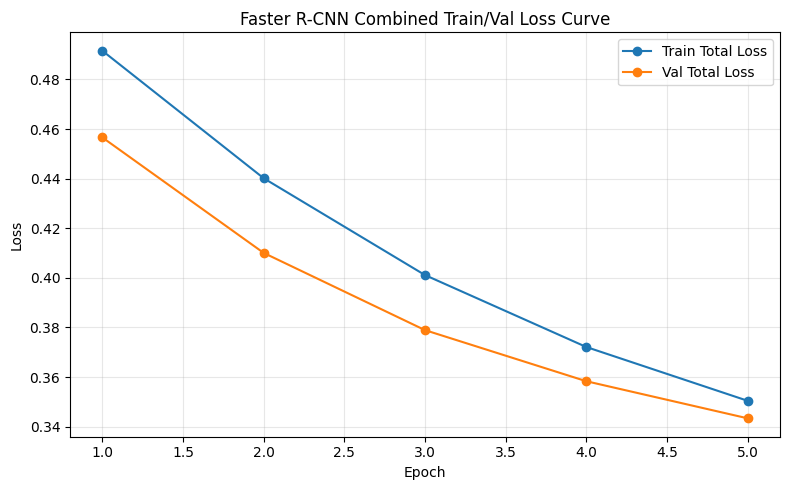

Saved figure to: /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/faster_rcnn_combined_train_val_loss_curve.png


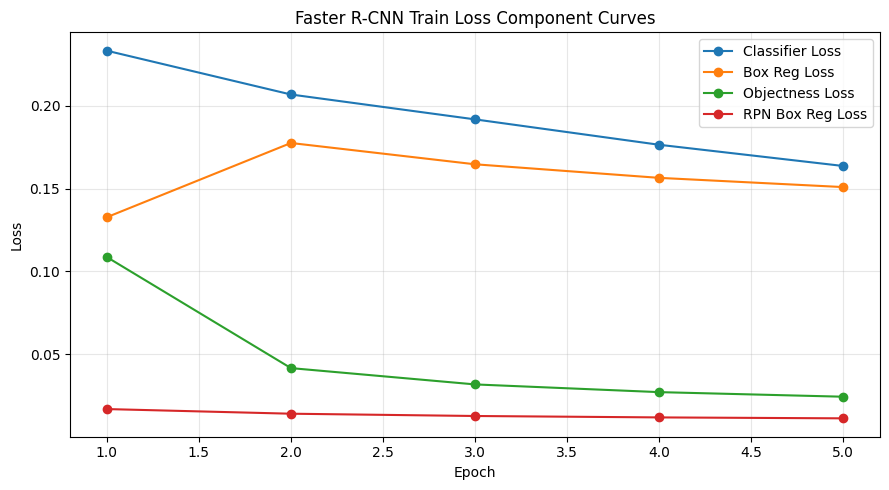

Saved figure to: /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/faster_rcnn_loss_component_curves.png


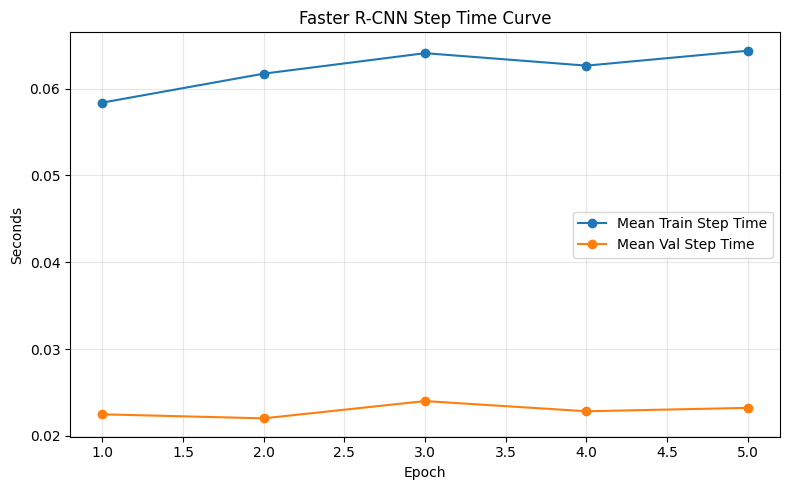

Saved figure to: /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/faster_rcnn_step_time_curve.png


In [49]:
# ============================
# Load saved logs and plot curves (aligned with YOLO baseline outputs)
# ============================
import matplotlib.pyplot as plt

train_steps_path = SERVER_METRICS_DIR / "train_step_losses.csv"
val_steps_path = SERVER_METRICS_DIR / "val_step_losses.csv"
epoch_summary_path = SERVER_METRICS_DIR / "epoch_summary.csv"

train_steps_df = pd.read_csv(train_steps_path) if train_steps_path.exists() else pd.DataFrame()
val_steps_df = pd.read_csv(val_steps_path) if val_steps_path.exists() else pd.DataFrame()
epoch_summary_df = pd.read_csv(epoch_summary_path) if epoch_summary_path.exists() else pd.DataFrame()

print("train_steps_df shape :", train_steps_df.shape)
print("val_steps_df shape   :", val_steps_df.shape)
print("epoch_summary_df shape:", epoch_summary_df.shape)

display(epoch_summary_df)

if len(epoch_summary_df) > 0:
    # 1) combined train/val total loss curve
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epoch_summary_df["epoch"], epoch_summary_df["mean_loss_total"], marker="o", label="Train Total Loss")
    ax.plot(epoch_summary_df["epoch"], epoch_summary_df["mean_val_loss_total"], marker="o", label="Val Total Loss")
    ax.set_title("Faster R-CNN Combined Train/Val Loss Curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    combined_loss_path = SERVER_METRICS_DIR / "faster_rcnn_combined_train_val_loss_curve.png"
    plt.savefig(combined_loss_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved figure to:", combined_loss_path)

    # 2) train loss component curves
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(epoch_summary_df["epoch"], epoch_summary_df["mean_loss_classifier"], marker="o", label="Classifier Loss")
    ax.plot(epoch_summary_df["epoch"], epoch_summary_df["mean_loss_box_reg"], marker="o", label="Box Reg Loss")
    ax.plot(epoch_summary_df["epoch"], epoch_summary_df["mean_loss_objectness"], marker="o", label="Objectness Loss")
    ax.plot(epoch_summary_df["epoch"], epoch_summary_df["mean_loss_rpn_box_reg"], marker="o", label="RPN Box Reg Loss")
    ax.set_title("Faster R-CNN Train Loss Component Curves")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    component_loss_path = SERVER_METRICS_DIR / "faster_rcnn_loss_component_curves.png"
    plt.savefig(component_loss_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved figure to:", component_loss_path)

    # 3) training speed curve
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epoch_summary_df["epoch"], epoch_summary_df["mean_step_time_sec"], marker="o", label="Mean Train Step Time")
    ax.plot(epoch_summary_df["epoch"], epoch_summary_df["mean_val_step_time_sec"], marker="o", label="Mean Val Step Time")
    ax.set_title("Faster R-CNN Step Time Curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Seconds")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    speed_curve_path = SERVER_METRICS_DIR / "faster_rcnn_step_time_curve.png"
    plt.savefig(speed_curve_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved figure to:", speed_curve_path)
else:
    print("No epoch summary found, so no curves were plotted.")

In [50]:
# ============================
# Save final training summary and aligned output manifests
# ============================
final_summary = {
    "experiment_name": SERVER_FRCNN_CONFIG["experiment_name"],
    "best_checkpoint_path_exp": str(SERVER_CKPT_DIR / "best_by_val_loss.pth"),
    "last_checkpoint_path_exp": str(SERVER_CKPT_DIR / "last.pth"),
    "final_model_weights_path_exp": str(SERVER_CKPT_DIR / "final_model_weights.pth"),

    "best_checkpoint_path_models_dir": str(CNN_MODELS_DIR / f"{SERVER_FRCNN_CONFIG['experiment_name']}_best_by_val_loss.pth"),
    "last_checkpoint_path_models_dir": str(CNN_MODELS_DIR / f"{SERVER_FRCNN_CONFIG['experiment_name']}_last.pth"),
    "final_model_weights_path_models_dir": str(CNN_MODELS_DIR / f"{SERVER_FRCNN_CONFIG['experiment_name']}_final_model_weights.pth"),

    "epoch_summary_csv": str(SERVER_METRICS_DIR / "epoch_summary.csv"),
    "train_step_losses_csv": str(SERVER_METRICS_DIR / "train_step_losses.csv"),
    "val_step_losses_csv": str(SERVER_METRICS_DIR / "val_step_losses.csv"),
    "epoch_log_csv": str(SERVER_METRICS_DIR / "faster_rcnn_epoch_log.csv"),
    "baseline_initial_summary_csv": str(SERVER_METRICS_DIR / "faster_rcnn_baseline_initial_summary.csv"),

    "combined_loss_curve_png": str(SERVER_METRICS_DIR / "faster_rcnn_combined_train_val_loss_curve.png"),
    "loss_component_curves_png": str(SERVER_METRICS_DIR / "faster_rcnn_loss_component_curves.png"),
    "step_time_curve_png": str(SERVER_METRICS_DIR / "faster_rcnn_step_time_curve.png"),

    "config_json": str(SERVER_METRICS_DIR / "faster_rcnn_baseline_initial_config.json"),
    "experiment_log_json": str(SERVER_METRICS_DIR / "experiment_log.json"),
}

final_summary_path = SERVER_METRICS_DIR / "final_training_summary.json"
with open(final_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=2, ensure_ascii=False)

print("Saved final training summary to:")
print(final_summary_path)
print(json.dumps(final_summary, indent=2, ensure_ascii=False))

# also update a global experiment log csv for cross-model comparison later
global_experiment_log_path = OUTPUT_ROOT / "experiment_log.csv"

row = pd.DataFrame([{
    "experiment_name": SERVER_FRCNN_CONFIG["experiment_name"],
    "model_name": "fasterrcnn_resnet50_fpn",
    "device": "cuda_or_current_runtime",
    "batch_size": SERVER_FRCNN_CONFIG["batch_size"],
    "learning_rate": SERVER_FRCNN_CONFIG["learning_rate"],
    "num_epochs": SERVER_FRCNN_CONFIG["num_epochs"],
    "config_json": str(SERVER_METRICS_DIR / "faster_rcnn_baseline_initial_config.json"),
    "final_summary_json": str(final_summary_path),
    "baseline_initial_summary_csv": str(SERVER_METRICS_DIR / "faster_rcnn_baseline_initial_summary.csv"),
    "best_checkpoint_path": str(CNN_MODELS_DIR / f"{SERVER_FRCNN_CONFIG['experiment_name']}_best_by_val_loss.pth"),
    "last_checkpoint_path": str(CNN_MODELS_DIR / f"{SERVER_FRCNN_CONFIG['experiment_name']}_last.pth"),
    "final_model_weights_path": str(CNN_MODELS_DIR / f"{SERVER_FRCNN_CONFIG['experiment_name']}_final_model_weights.pth"),
}])

if global_experiment_log_path.exists():
    old_df = pd.read_csv(global_experiment_log_path)
    new_df = pd.concat([old_df, row], ignore_index=True)
    # optional: drop duplicated experiment_name and keep last
    new_df = new_df.drop_duplicates(subset=["experiment_name"], keep="last")
else:
    new_df = row

new_df.to_csv(global_experiment_log_path, index=False)

print("\nUpdated global experiment log:")
print(global_experiment_log_path)
display(new_df.tail(5))

Saved final training summary to:
/root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/final_training_summary.json
{
  "experiment_name": "faster_rcnn_server_baseline_light_v1",
  "best_checkpoint_path_exp": "/root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/checkpoints/best_by_val_loss.pth",
  "last_checkpoint_path_exp": "/root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/checkpoints/last.pth",
  "final_model_weights_path_exp": "/root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/checkpoints/final_model_weights.pth",
  "best_checkpoint_path_models_dir": "/root/AIDL/output/cnn/models/faster_rcnn_server_baseline_light_v1_best_by_val_loss.pth",
  "last_checkpoint_path_models_dir": "/root/AIDL/output/cnn/models/faster_rcnn_server_baseline_light_v1_last.pth",
  "final_model_weights_path_models_dir": "/root/AIDL/output/cnn/models/faster_rcnn_server_baseline_light_v1_final_model_weights.pth",
  "epoch_summary_csv": "/root/AIDL/output/cnn/faster_rcnn_serve

,experiment_name,model_name,device,batch_size,learning_rate,num_epochs,config_json,final_summary_json,baseline_initial_summary_csv,best_checkpoint_path,last_checkpoint_path,final_model_weights_path
0,faster_rcnn_server_baseline_light_v1,fasterrcnn_resnet50_fpn,cuda_or_current_runtime,2,0.0001,5,/root/AIDL/output/cnn/faster_rcnn_server_basel...,/root/AIDL/output/cnn/faster_rcnn_server_basel...,/root/AIDL/output/cnn/faster_rcnn_server_basel...,/root/AIDL/output/cnn/models/faster_rcnn_serve...,/root/AIDL/output/cnn/models/faster_rcnn_serve...,/root/AIDL/output/cnn/models/faster_rcnn_serve...


In [8]:
# ============================
# Final detection evaluation on official val2017
# (self-contained version with path redefinition)
# ============================
import os
import json
import time
from pathlib import Path

import torch
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np

# ----------------------------
# Re-define all required paths
# ----------------------------
PROJECT_ROOT = Path(".").resolve()

DATASET_ROOT = PROJECT_ROOT / "DsPCBSD+"
COCO_ROOT = DATASET_ROOT / "Data_COCO"

TRAIN_JSON = COCO_ROOT / "annotations" / "instances_train2017.json"
VAL_JSON = COCO_ROOT / "annotations" / "instances_val2017.json"
TRAIN_IMG_DIR = COCO_ROOT / "train2017"
VAL_IMG_DIR = COCO_ROOT / "val2017"

OUTPUT_ROOT = PROJECT_ROOT / "output"
CNN_OUTPUT_DIR = OUTPUT_ROOT / "cnn"
CNN_MODELS_DIR = CNN_OUTPUT_DIR / "models"
CNN_METRICS_DIR = CNN_OUTPUT_DIR / "metrics"

PRETRAINED_WEIGHTS_DIR = PROJECT_ROOT / "pretrained_weights"
FRCNN_WEIGHT_PATH = PRETRAINED_WEIGHTS_DIR / "fasterrcnn_resnet50_fpn_coco-258fb6c6.pth"

# your trained experiment name
EXPERIMENT_NAME = "faster_rcnn_server_baseline_light_v1"

# trained model path (priority: archived best model in output/cnn/models/)
BEST_MODEL_PATH = CNN_MODELS_DIR / f"{EXPERIMENT_NAME}_best_by_val_loss.pth"

# fallback: if you want to load from experiment checkpoints instead
EXP_DIR = CNN_OUTPUT_DIR / EXPERIMENT_NAME
EXP_CKPT_DIR = EXP_DIR / "checkpoints"
if not BEST_MODEL_PATH.exists():
    fallback_best = EXP_CKPT_DIR / "best_by_val_loss.pth"
    if fallback_best.exists():
        BEST_MODEL_PATH = fallback_best

print("PROJECT_ROOT       :", PROJECT_ROOT)
print("DATASET_ROOT       :", DATASET_ROOT)
print("COCO_ROOT          :", COCO_ROOT)
print("VAL_JSON           :", VAL_JSON)
print("VAL_IMG_DIR        :", VAL_IMG_DIR)
print("FRCNN_WEIGHT_PATH  :", FRCNN_WEIGHT_PATH)
print("BEST_MODEL_PATH    :", BEST_MODEL_PATH)

required_paths = {
    "VAL_JSON": VAL_JSON,
    "VAL_IMG_DIR": VAL_IMG_DIR,
    "FRCNN_WEIGHT_PATH": FRCNN_WEIGHT_PATH,
    "BEST_MODEL_PATH": BEST_MODEL_PATH,
}
missing = [name for name, p in required_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required paths:\n- " + "\n- ".join(missing))

# ----------------------------
# Imports that may be needed after kernel restart
# ----------------------------
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# ----------------------------
# Helper functions
# ----------------------------
def get_preferred_device():
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

def build_faster_rcnn_model_from_local(num_classes, local_weight_path):
    if not Path(local_weight_path).exists():
        raise FileNotFoundError(f"Local pretrained weight not found: {local_weight_path}")

    model = fasterrcnn_resnet50_fpn(weights=None, weights_backbone=None)
    state_dict = torch.load(local_weight_path, map_location="cpu")
    model.load_state_dict(state_dict)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def detection_collate_fn(batch):
    return tuple(zip(*batch))

# ----------------------------
# Reload COCO tables
# ----------------------------
with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    train_coco = json.load(f)

with open(VAL_JSON, "r", encoding="utf-8") as f:
    val_coco = json.load(f)

train_images_df = pd.DataFrame(train_coco["images"])
train_ann_df = pd.DataFrame(train_coco["annotations"])
train_cat_df = pd.DataFrame(train_coco["categories"]).rename(columns={"id": "category_id", "name": "category_name"})

val_images_df = pd.DataFrame(val_coco["images"])
val_ann_df = pd.DataFrame(val_coco["annotations"])
val_cat_df = pd.DataFrame(val_coco["categories"]).rename(columns={"id": "category_id", "name": "category_name"})

cat_id_to_name = dict(zip(train_cat_df["category_id"], train_cat_df["category_name"]))

# ----------------------------
# Rebuild Dataset class
# ----------------------------
class PCBDetectionDataset(Dataset):
    def __init__(self, images_df, ann_df, img_dir, transforms=None):
        self.images_df = images_df.copy().reset_index(drop=True)
        self.ann_df = ann_df.copy()
        self.img_dir = Path(img_dir)
        self.transforms = transforms

        self.ann_by_image = {}
        for _, row in self.ann_df.iterrows():
            image_id = row["image_id"]
            self.ann_by_image.setdefault(image_id, []).append(row)

    def __len__(self):
        return len(self.images_df)

    def _clip_and_filter_boxes(self, boxes_xyxy, labels, img_w, img_h):
        clipped_boxes = []
        clipped_labels = []
        areas = []

        for box, label in zip(boxes_xyxy, labels):
            x1, y1, x2, y2 = box

            x1 = max(0.0, min(float(x1), float(img_w)))
            y1 = max(0.0, min(float(y1), float(img_h)))
            x2 = max(0.0, min(float(x2), float(img_w)))
            y2 = max(0.0, min(float(y2), float(img_h)))

            w = x2 - x1
            h = y2 - y1

            if w > 0 and h > 0:
                clipped_boxes.append([x1, y1, x2, y2])
                clipped_labels.append(int(label))
                areas.append(float(w * h))

        return clipped_boxes, clipped_labels, areas

    def __getitem__(self, idx):
        img_row = self.images_df.iloc[idx]

        image_id = int(img_row["id"])
        file_name = img_row["file_name"]
        img_w = int(img_row["width"])
        img_h = int(img_row["height"])

        img_path = self.img_dir / file_name
        image = Image.open(img_path).convert("RGB")

        ann_rows = self.ann_by_image.get(image_id, [])

        boxes_xyxy = []
        labels = []
        iscrowd = []

        for ann in ann_rows:
            x, y, w, h = ann["bbox"]
            x1 = x
            y1 = y
            x2 = x + w
            y2 = y + h

            boxes_xyxy.append([x1, y1, x2, y2])
            labels.append(int(ann["category_id"]))
            iscrowd.append(int(ann.get("iscrowd", 0)))

        boxes_xyxy, labels, areas = self._clip_and_filter_boxes(boxes_xyxy, labels, img_w, img_h)

        if len(boxes_xyxy) == len(iscrowd):
            kept_iscrowd = iscrowd
        else:
            kept_iscrowd = [0] * len(boxes_xyxy)

        boxes = torch.as_tensor(boxes_xyxy, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(kept_iscrowd, dtype=torch.int64)

        if boxes.numel() == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id], dtype=torch.int64),
            "area": areas,
            "iscrowd": iscrowd,
        }

        image = torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 255.0
        return image, target

# ----------------------------
# Build official val2017 test dataset/loader
# ----------------------------
test_dataset = PCBDetectionDataset(
    images_df=val_images_df,
    ann_df=val_ann_df,
    img_dir=VAL_IMG_DIR,
    transforms=None
)

BATCH_SIZE = 2
NUM_WORKERS = 2

eval_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=detection_collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Number of test batches:", len(eval_test_loader))
print("Number of test images :", len(test_dataset))

# ----------------------------
# Rebuild and load trained model
# ----------------------------
eval_device = get_preferred_device()
print("Evaluation device:", eval_device)

NUM_CLASSES = 10

eval_model = build_faster_rcnn_model_from_local(
    num_classes=NUM_CLASSES,
    local_weight_path=FRCNN_WEIGHT_PATH
)

ckpt = torch.load(BEST_MODEL_PATH, map_location="cpu")
if "model_state_dict" in ckpt:
    eval_model.load_state_dict(ckpt["model_state_dict"])
else:
    eval_model.load_state_dict(ckpt)

eval_model.to(eval_device)
eval_model.eval()

# ----------------------------
# Metric object
# ----------------------------
metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="bbox",
    class_metrics=True,
    backend="faster_coco_eval"
)

# ----------------------------
# Run evaluation
# ----------------------------
all_predictions = []
all_targets = []

num_images = 0
inference_times = []

with torch.no_grad():
    for batch_idx, (images, targets) in enumerate(eval_test_loader, start=1):
        images = [img.to(eval_device) for img in images]

        start_time = time.time()
        outputs = eval_model(images)
        batch_infer_time = time.time() - start_time

        inference_times.append(batch_infer_time / len(images))
        num_images += len(images)

        outputs_cpu = []
        for out in outputs:
            outputs_cpu.append({
                "boxes": out["boxes"].detach().cpu(),
                "scores": out["scores"].detach().cpu(),
                "labels": out["labels"].detach().cpu(),
            })

        targets_cpu = []
        for tgt in targets:
            targets_cpu.append({
                "boxes": tgt["boxes"].detach().cpu(),
                "labels": tgt["labels"].detach().cpu(),
            })

        metric.update(outputs_cpu, targets_cpu)

        for out, tgt in zip(outputs_cpu, targets_cpu):
            all_predictions.append({
                "boxes": out["boxes"].tolist(),
                "scores": out["scores"].tolist(),
                "labels": out["labels"].tolist(),
            })
            all_targets.append({
                "boxes": tgt["boxes"].tolist(),
                "labels": tgt["labels"].tolist(),
            })

        if batch_idx == 1 or batch_idx % 50 == 0:
            print(f"Processed batch {batch_idx}/{len(eval_test_loader)}")

metrics = metric.compute()

# ----------------------------
# Parse overall metrics
# ----------------------------
overall_metrics = {
    "model_name": "fasterrcnn_resnet50_fpn",
    "experiment_name": EXPERIMENT_NAME,
    "map_50": float(metrics["map_50"].item()),
    "map_50_95": float(metrics["map"].item()),
    "mar_100": float(metrics["mar_100"].item()),
    "inference_time_per_image_sec": float(sum(inference_times) / len(inference_times)) if len(inference_times) > 0 else None,
    "num_test_images": int(num_images),
}

param_count = sum(p.numel() for p in eval_model.parameters())
model_file_size_mb = round(BEST_MODEL_PATH.stat().st_size / (1024 * 1024), 4)

overall_metrics["num_parameters"] = int(param_count)
overall_metrics["model_file_size_mb"] = float(model_file_size_mb)

print("\n=== Overall Detection Metrics ===")
for k, v in overall_metrics.items():
    print(f"{k}: {v}")

# ----------------------------
# Parse per-class AP
# ----------------------------
per_class_rows = []
if "classes" in metrics and "map_per_class" in metrics:
    classes = metrics["classes"].tolist()
    map_per_class = metrics["map_per_class"].tolist()
    mar_per_class = metrics["mar_100_per_class"].tolist() if "mar_100_per_class" in metrics else [None] * len(classes)

    for cls_id, cls_map, cls_mar in zip(classes, map_per_class, mar_per_class):
        per_class_rows.append({
            "category_id": int(cls_id),
            "category_name": cat_id_to_name.get(int(cls_id), str(cls_id)),
            "ap_50_95": float(cls_map),
            "mar_100": float(cls_mar) if cls_mar is not None else None,
        })

per_class_df = pd.DataFrame(per_class_rows).sort_values("category_id").reset_index(drop=True)

print("\n=== Per-class AP ===")
display(per_class_df)

# ----------------------------
# Save metrics
# ----------------------------
raw_metrics_serializable = {}
for k, v in metrics.items():
    if torch.is_tensor(v):
        if v.ndim == 0:
            raw_metrics_serializable[k] = float(v.item())
        else:
            raw_metrics_serializable[k] = v.detach().cpu().tolist()
    else:
        raw_metrics_serializable[k] = v

raw_metrics_path = CNN_METRICS_DIR / "faster_rcnn_eval_raw.json"
with open(raw_metrics_path, "w", encoding="utf-8") as f:
    json.dump(raw_metrics_serializable, f, indent=2, ensure_ascii=False)

overall_metrics_df = pd.DataFrame([overall_metrics])
overall_metrics_path = CNN_METRICS_DIR / "faster_rcnn_overall_metrics.csv"
overall_metrics_df.to_csv(overall_metrics_path, index=False)

per_class_metrics_path = CNN_METRICS_DIR / "faster_rcnn_per_class_ap.csv"
per_class_df.to_csv(per_class_metrics_path, index=False)

overall_summary_path = OUTPUT_ROOT / "overall_metrics_summary.csv"
if overall_summary_path.exists():
    old_df = pd.read_csv(overall_summary_path)
    new_df = pd.concat([old_df, overall_metrics_df], ignore_index=True)
    new_df = new_df.drop_duplicates(subset=["experiment_name", "model_name"], keep="last")
else:
    new_df = overall_metrics_df.copy()
new_df.to_csv(overall_summary_path, index=False)

per_class_global_df = per_class_df.copy()
per_class_global_df["model_name"] = "fasterrcnn_resnet50_fpn"
per_class_global_df["experiment_name"] = EXPERIMENT_NAME

per_class_summary_path = OUTPUT_ROOT / "per_class_metrics_summary.csv"
if per_class_summary_path.exists():
    old_pc_df = pd.read_csv(per_class_summary_path)
    new_pc_df = pd.concat([old_pc_df, per_class_global_df], ignore_index=True)
    new_pc_df = new_pc_df.drop_duplicates(subset=["experiment_name", "model_name", "category_id"], keep="last")
else:
    new_pc_df = per_class_global_df.copy()
new_pc_df.to_csv(per_class_summary_path, index=False)

print("\nSaved files:")
print("Raw metrics JSON        :", raw_metrics_path)
print("Overall metrics CSV     :", overall_metrics_path)
print("Per-class AP CSV        :", per_class_metrics_path)
print("Global overall summary  :", overall_summary_path)
print("Global per-class summary:", per_class_summary_path)

PROJECT_ROOT       : /root/AIDL
DATASET_ROOT       : /root/AIDL/DsPCBSD+
COCO_ROOT          : /root/AIDL/DsPCBSD+/Data_COCO
VAL_JSON           : /root/AIDL/DsPCBSD+/Data_COCO/annotations/instances_val2017.json
VAL_IMG_DIR        : /root/AIDL/DsPCBSD+/Data_COCO/val2017
FRCNN_WEIGHT_PATH  : /root/AIDL/pretrained_weights/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
BEST_MODEL_PATH    : /root/AIDL/output/cnn/models/faster_rcnn_server_baseline_light_v1_best_by_val_loss.pth
Number of test batches: 1026
Number of test images : 2051
Evaluation device: cuda
Processed batch 1/1026
Processed batch 50/1026
Processed batch 100/1026
Processed batch 150/1026
Processed batch 200/1026
Processed batch 250/1026
Processed batch 300/1026
Processed batch 350/1026
Processed batch 400/1026
Processed batch 450/1026
Processed batch 500/1026
Processed batch 550/1026
Processed batch 600/1026
Processed batch 650/1026
Processed batch 700/1026
Processed batch 750/1026
Processed batch 800/1026
Processed batch 850/1026
P

,category_id,category_name,ap_50_95,mar_100
0,1,SH,0.118159,0.357988
1,2,SP,0.133423,0.329171
2,3,SC,0.274126,0.495789
3,4,OP,0.084765,0.328994
4,5,MB,0.137726,0.317766
5,6,HB,0.638719,0.750000
6,7,CS,0.070346,0.315179
7,8,CFO,0.141056,0.352955
8,9,BMFO,0.295643,0.451734



Saved files:
Raw metrics JSON        : /root/AIDL/output/cnn/metrics/faster_rcnn_eval_raw.json
Overall metrics CSV     : /root/AIDL/output/cnn/metrics/faster_rcnn_overall_metrics.csv
Per-class AP CSV        : /root/AIDL/output/cnn/metrics/faster_rcnn_per_class_ap.csv
Global overall summary  : /root/AIDL/output/overall_metrics_summary.csv
Global per-class summary: /root/AIDL/output/per_class_metrics_summary.csv


### Faster R-CNN baseline 正式评估结果分析

本次 Faster R-CNN 轻量 baseline 在官方 `val2017` 上的正式评估结果表明，该模型已经具备了明确的缺陷检测能力，但整体仍属于“可用 baseline”而非充分优化后的强模型。总体上，模型取得了 `mAP@0.50 = 0.4324`、`mAP@0.50:0.95 = 0.2104`、`mAR@100 = 0.4111`。其中，`mAP@0.50` 明显高于 `mAP@0.50:0.95`，说明模型在较宽松 IoU 条件下能够较好地发现目标，但在更严格的定位要求下性能下降较明显。这表明当前模型已经能够找到目标的大致位置，但边界框的精细定位能力仍然不足。

从类别层面来看，模型表现出明显的类别间差异。`HB` 的 `AP@0.50:0.95` 达到 `0.6387`，`mAR@100` 也达到 `0.7500`，是当前检测效果最好的类别，说明该类缺陷的视觉模式可能更稳定、可分性更强。相比之下，`BMFO` 和 `SC` 的表现处于中等水平，而 `SH`、`SP`、`MB`、`CFO` 和 `OP` 的 AP 整体较低，说明这些类别仍然受到小目标、类别不平衡、边界模糊或视觉相似性等因素影响。尤其值得注意的是，`CS` 的 `AP@0.50:0.95` 仅为 `0.0703`，表现最弱之一。结合前面的 EDA，可以推测 `CS` 虽然往往具有较大的标注框，但其特殊的标注模式和视觉结构并没有转化为更容易的检测任务，说明“目标更大”并不必然意味着“更容易检测”。

从召回角度看，整体 `mAR@100 = 0.4111` 仍然不高，说明模型对不少缺陷仍存在较明显的漏检问题。这对于 PCB 质检任务尤其值得关注，因为工业质检场景通常更重视缺陷不要被漏掉。工程层面上，该模型的单张图推理时间约为 `0.0090 s`，参数量约为 `41.39M`，模型文件大小约为 `316.19 MB`。这说明 Faster R-CNN 作为 two-stage 检测器，在当前任务中属于相对较重的模型，其后续价值更多体现在与 YOLOv8n 的架构对比、类别差异分析以及工程 trade-off 讨论中，而不是作为唯一主力模型进行大规模优化。

综合来看，这次 Faster R-CNN baseline 训练与正式评估都是成功的。它已经能够作为一个稳定且有代表性的 two-stage detection baseline，为后续与 YOLO 的比较提供参考。但从当前结果来看，该模型在高 IoU 条件下的定位精度仍有限，类别间性能差异明显，且整体召回水平还有提升空间。因此，下一步最有价值的工作不是立刻增加训练预算，而是结合预测可视化和错误样本分析，进一步解释哪些类别失败最多、失败模式是什么，以及这些问题是否与小目标检测和类别不平衡直接相关。

In [ ]:
### Analysis of Faster R-CNN Baseline Final Evaluation Results

The final evaluation of the lightweight Faster R-CNN baseline on the official `val2017` split shows that the model has learned meaningful defect detection patterns, but it should still be regarded as a usable baseline rather than a fully optimised detector. Overall, the model achieved `mAP@0.50 = 0.4324`, `mAP@0.50:0.95 = 0.2104`, and `mAR@100 = 0.4111`. The clear gap between `mAP@0.50` and `mAP@0.50:0.95` indicates that the model can often localise defects approximately under a loose IoU threshold, but its performance drops substantially when stricter localisation quality is required. In other words, the model is able to find defects to a certain extent, but its bounding box precision is still limited.

At the class level, the model shows strong performance variation across categories. `HB` is the best-performing class, with `AP@0.50:0.95 = 0.6387` and `mAR@100 = 0.7500`, suggesting that this defect type is visually more consistent and easier for the detector to learn. `BMFO` and `SC` perform at a moderate level, while `SH`, `SP`, `MB`, `CFO`, and `OP` remain relatively weak. These lower values are likely influenced by a combination of small-object difficulty, class imbalance, blurry boundaries, and visual similarity between defect types. A particularly interesting finding is that `CS` performs poorly, with `AP@0.50:0.95 = 0.0703`, even though earlier EDA showed that this class often has very large bounding boxes. This suggests that larger object size does not automatically make a category easier to detect, and that class-specific annotation patterns and visual structure also play an important role.

From the recall perspective, the overall `mAR@100 = 0.4111` is still moderate, which means the model is missing a noticeable proportion of defects. This is especially important in PCB inspection scenarios, where missed defects are often more critical than false alarms. From an engineering perspective, the model runs at approximately `0.0090 s` per image, with about `41.39M` parameters and a model file size of around `316.19 MB`. This confirms that Faster R-CNN is a relatively heavy two-stage detector in this task setting. Therefore, its main value in this coursework is likely to be as a representative comparison baseline against YOLOv8n, especially for analysing architectural differences, category-specific behaviour, and engineering trade-offs.

Overall, this Faster R-CNN baseline run and final evaluation can be considered successful. The model provides a stable and meaningful two-stage detection baseline for later comparison with YOLO. However, the current results also show that localisation quality under stricter IoU thresholds remains limited, class-dependent performance variation is strong, and recall still leaves room for improvement. Therefore, the most useful next step is not immediately to increase the training budget, but to conduct prediction visualisation and error analysis in order to identify which failure modes dominate and how strongly they relate to small-object difficulty and class imbalance.

In [12]:
# ============================
# Prediction visualisation + error case mining
# (self-contained version with path redefinition)
# ============================
import os
import json
import time
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# ----------------------------
# Re-define required paths
# ----------------------------
PROJECT_ROOT = Path(".").resolve()

DATASET_ROOT = PROJECT_ROOT / "DsPCBSD+"
COCO_ROOT = DATASET_ROOT / "Data_COCO"

TRAIN_JSON = COCO_ROOT / "annotations" / "instances_train2017.json"
VAL_JSON = COCO_ROOT / "annotations" / "instances_val2017.json"
TRAIN_IMG_DIR = COCO_ROOT / "train2017"
VAL_IMG_DIR = COCO_ROOT / "val2017"

OUTPUT_ROOT = PROJECT_ROOT / "output"
CNN_OUTPUT_DIR = OUTPUT_ROOT / "cnn"
CNN_MODELS_DIR = CNN_OUTPUT_DIR / "models"
CNN_METRICS_DIR = CNN_OUTPUT_DIR / "metrics"

EXPERIMENT_NAME = "faster_rcnn_server_baseline_light_v1"
SERVER_EXP_DIR = CNN_OUTPUT_DIR / EXPERIMENT_NAME
SERVER_CKPT_DIR = SERVER_EXP_DIR / "checkpoints"
SERVER_METRICS_DIR = SERVER_EXP_DIR / "metrics"
SERVER_PRED_DIR = SERVER_EXP_DIR / "predictions"

PRETRAINED_WEIGHTS_DIR = PROJECT_ROOT / "pretrained_weights"
FRCNN_WEIGHT_PATH = PRETRAINED_WEIGHTS_DIR / "fasterrcnn_resnet50_fpn_coco-258fb6c6.pth"

BEST_MODEL_PATH = CNN_MODELS_DIR / f"{EXPERIMENT_NAME}_best_by_val_loss.pth"
if not BEST_MODEL_PATH.exists():
    fallback_best = SERVER_CKPT_DIR / "best_by_val_loss.pth"
    if fallback_best.exists():
        BEST_MODEL_PATH = fallback_best

print("PROJECT_ROOT    :", PROJECT_ROOT)
print("DATASET_ROOT    :", DATASET_ROOT)
print("VAL_JSON        :", VAL_JSON)
print("VAL_IMG_DIR     :", VAL_IMG_DIR)
print("FRCNN_WEIGHT    :", FRCNN_WEIGHT_PATH)
print("BEST_MODEL_PATH :", BEST_MODEL_PATH)
print("SERVER_PRED_DIR :", SERVER_PRED_DIR)

required_paths = {
    "VAL_JSON": VAL_JSON,
    "VAL_IMG_DIR": VAL_IMG_DIR,
    "FRCNN_WEIGHT_PATH": FRCNN_WEIGHT_PATH,
    "BEST_MODEL_PATH": BEST_MODEL_PATH,
}
missing = [name for name, p in required_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required paths:\n- " + "\n- ".join(missing))

# ----------------------------
# Helper functions
# ----------------------------
def get_preferred_device():
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

def build_faster_rcnn_model_from_local(num_classes, local_weight_path):
    if not Path(local_weight_path).exists():
        raise FileNotFoundError(f"Local pretrained weight not found: {local_weight_path}")

    model = fasterrcnn_resnet50_fpn(weights=None, weights_backbone=None)
    state_dict = torch.load(local_weight_path, map_location="cpu")
    model.load_state_dict(state_dict)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def detection_collate_fn(batch):
    return tuple(zip(*batch))

def compute_iou_xyxy(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter = inter_w * inter_h

    area1 = max(0.0, box1[2] - box1[0]) * max(0.0, box1[3] - box1[1])
    area2 = max(0.0, box2[2] - box2[0]) * max(0.0, box2[3] - box2[1])

    union = area1 + area2 - inter
    if union <= 0:
        return 0.0
    return inter / union

# ----------------------------
# Reload COCO tables
# ----------------------------
with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    train_coco = json.load(f)

with open(VAL_JSON, "r", encoding="utf-8") as f:
    val_coco = json.load(f)

train_images_df = pd.DataFrame(train_coco["images"])
train_ann_df = pd.DataFrame(train_coco["annotations"])
train_cat_df = pd.DataFrame(train_coco["categories"]).rename(columns={"id": "category_id", "name": "category_name"})

val_images_df = pd.DataFrame(val_coco["images"])
val_ann_df = pd.DataFrame(val_coco["annotations"])

cat_id_to_name = dict(zip(train_cat_df["category_id"], train_cat_df["category_name"]))

# ----------------------------
# Rebuild Dataset class
# ----------------------------
class PCBDetectionDataset(Dataset):
    def __init__(self, images_df, ann_df, img_dir, transforms=None):
        self.images_df = images_df.copy().reset_index(drop=True)
        self.ann_df = ann_df.copy()
        self.img_dir = Path(img_dir)
        self.transforms = transforms

        self.ann_by_image = {}
        for _, row in self.ann_df.iterrows():
            image_id = row["image_id"]
            self.ann_by_image.setdefault(image_id, []).append(row)

    def __len__(self):
        return len(self.images_df)

    def _clip_and_filter_boxes(self, boxes_xyxy, labels, img_w, img_h):
        clipped_boxes = []
        clipped_labels = []
        areas = []

        for box, label in zip(boxes_xyxy, labels):
            x1, y1, x2, y2 = box

            x1 = max(0.0, min(float(x1), float(img_w)))
            y1 = max(0.0, min(float(y1), float(img_h)))
            x2 = max(0.0, min(float(x2), float(img_w)))
            y2 = max(0.0, min(float(y2), float(img_h)))

            w = x2 - x1
            h = y2 - y1

            if w > 0 and h > 0:
                clipped_boxes.append([x1, y1, x2, y2])
                clipped_labels.append(int(label))
                areas.append(float(w * h))

        return clipped_boxes, clipped_labels, areas

    def __getitem__(self, idx):
        img_row = self.images_df.iloc[idx]

        image_id = int(img_row["id"])
        file_name = img_row["file_name"]
        img_w = int(img_row["width"])
        img_h = int(img_row["height"])

        img_path = self.img_dir / file_name
        image = Image.open(img_path).convert("RGB")

        ann_rows = self.ann_by_image.get(image_id, [])

        boxes_xyxy = []
        labels = []
        iscrowd = []

        for ann in ann_rows:
            x, y, w, h = ann["bbox"]
            x1 = x
            y1 = y
            x2 = x + w
            y2 = y + h

            boxes_xyxy.append([x1, y1, x2, y2])
            labels.append(int(ann["category_id"]))
            iscrowd.append(int(ann.get("iscrowd", 0)))

        boxes_xyxy, labels, areas = self._clip_and_filter_boxes(boxes_xyxy, labels, img_w, img_h)

        if len(boxes_xyxy) == len(iscrowd):
            kept_iscrowd = iscrowd
        else:
            kept_iscrowd = [0] * len(boxes_xyxy)

        boxes = torch.as_tensor(boxes_xyxy, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(kept_iscrowd, dtype=torch.int64)

        if boxes.numel() == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id], dtype=torch.int64),
            "area": areas,
            "iscrowd": iscrowd,
        }

        image = torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 255.0
        return image, target

# ----------------------------
# Build test dataset/loader
# ----------------------------
test_dataset = PCBDetectionDataset(
    images_df=val_images_df,
    ann_df=val_ann_df,
    img_dir=VAL_IMG_DIR,
    transforms=None
)

vis_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=detection_collate_fn,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# ----------------------------
# Output dirs
# ----------------------------
PRED_ROOT = SERVER_PRED_DIR
GOOD_CASE_DIR = PRED_ROOT / "good_cases"
ERROR_ROOT = PRED_ROOT / "errors"
FP_DIR = ERROR_ROOT / "false_positive_cases"
FN_DIR = ERROR_ROOT / "false_negative_cases"
SMALL_OBJ_FAIL_DIR = ERROR_ROOT / "small_object_failure_cases"

for d in [PRED_ROOT, GOOD_CASE_DIR, ERROR_ROOT, FP_DIR, FN_DIR, SMALL_OBJ_FAIL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Reload trained model
# ----------------------------
infer_device = get_preferred_device()
print("Inference device:", infer_device)

vis_model = build_faster_rcnn_model_from_local(
    num_classes=10,
    local_weight_path=FRCNN_WEIGHT_PATH
)

ckpt = torch.load(BEST_MODEL_PATH, map_location="cpu")
if "model_state_dict" in ckpt:
    vis_model.load_state_dict(ckpt["model_state_dict"])
else:
    vis_model.load_state_dict(ckpt)

vis_model.to(infer_device)
vis_model.eval()

# ----------------------------
# Drawing helper
# ----------------------------
def draw_prediction_figure(
    image_tensor,
    gt_boxes,
    gt_labels,
    pred_boxes,
    pred_labels,
    pred_scores,
    title,
    save_path
):
    img_np = image_tensor.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img_np)

    # GT boxes
    for box, label in zip(gt_boxes, gt_labels):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(
            x1, max(y1 - 2, 2),
            f"GT:{cat_id_to_name.get(int(label), label)}",
            color="lime",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.5, pad=1)
        )

    # Pred boxes
    for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(
            x1, min(y2 + 8, img_np.shape[0] - 2),
            f"P:{cat_id_to_name.get(int(label), label)} {score:.2f}",
            color="yellow",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.5, pad=1)
        )

    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

# ----------------------------
# Mining settings
# ----------------------------
CONF_THRESH = 0.30
IOU_MATCH_THRESH = 0.50
SMALL_OBJ_AREA_RATIO_THRESH = 0.01

MAX_GOOD_CASES = 12
MAX_FP_CASES = 12
MAX_FN_CASES = 12
MAX_SMALL_FAIL_CASES = 12

good_count = 0
fp_count = 0
fn_count = 0
small_fail_count = 0

case_records = []

# ----------------------------
# Run mining
# ----------------------------
with torch.no_grad():
    for idx, (images, targets) in enumerate(vis_loader):
        image = images[0]
        target = targets[0]

        image_id = int(target["image_id"].item())
        gt_boxes = target["boxes"].cpu().numpy()
        gt_labels = target["labels"].cpu().numpy()

        img_for_model = [image.to(infer_device)]
        output = vis_model(img_for_model)[0]

        pred_boxes = output["boxes"].detach().cpu().numpy()
        pred_scores = output["scores"].detach().cpu().numpy()
        pred_labels = output["labels"].detach().cpu().numpy()

        keep = pred_scores >= CONF_THRESH
        pred_boxes = pred_boxes[keep]
        pred_scores = pred_scores[keep]
        pred_labels = pred_labels[keep]

        matched_gt = set()
        matched_pred = set()

        for p_idx, (p_box, p_label) in enumerate(zip(pred_boxes, pred_labels)):
            best_iou = 0.0
            best_gt_idx = None

            for g_idx, (g_box, g_label) in enumerate(zip(gt_boxes, gt_labels)):
                if int(p_label) != int(g_label):
                    continue
                iou = compute_iou_xyxy(p_box, g_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = g_idx

            if best_gt_idx is not None and best_iou >= IOU_MATCH_THRESH:
                matched_pred.add(p_idx)
                matched_gt.add(best_gt_idx)

        num_gt = len(gt_boxes)
        num_pred = len(pred_boxes)
        num_tp = len(matched_gt)
        num_fp = num_pred - len(matched_pred)
        num_fn = num_gt - len(matched_gt)

        # small object failure
        small_gt_indices = []
        h, w = image.shape[1], image.shape[2]
        image_area = h * w
        for g_idx, g_box in enumerate(gt_boxes):
            gx1, gy1, gx2, gy2 = g_box
            g_area = max(0.0, gx2 - gx1) * max(0.0, gy2 - gy1)
            if image_area > 0 and (g_area / image_area) < SMALL_OBJ_AREA_RATIO_THRESH:
                small_gt_indices.append(g_idx)

        has_small_obj_fn = any(g_idx not in matched_gt for g_idx in small_gt_indices)

        is_good_case = (num_gt > 0 and num_fp == 0 and num_fn == 0)
        is_fp_case = (num_fp > 0)
        is_fn_case = (num_fn > 0)

        case_records.append({
            "image_id": image_id,
            "num_gt": num_gt,
            "num_pred": num_pred,
            "num_tp": num_tp,
            "num_fp": num_fp,
            "num_fn": num_fn,
            "has_small_obj_fn": has_small_obj_fn,
        })

        base_title = f"image_id={image_id} | GT={num_gt}, Pred={num_pred}, TP={num_tp}, FP={num_fp}, FN={num_fn}"
        filename = f"image_{image_id}.png"

        if is_good_case and good_count < MAX_GOOD_CASES:
            draw_prediction_figure(
                image, gt_boxes, gt_labels, pred_boxes, pred_labels, pred_scores,
                title="[Good Case] " + base_title,
                save_path=GOOD_CASE_DIR / filename
            )
            good_count += 1

        if is_fp_case and fp_count < MAX_FP_CASES:
            draw_prediction_figure(
                image, gt_boxes, gt_labels, pred_boxes, pred_labels, pred_scores,
                title="[False Positive Case] " + base_title,
                save_path=FP_DIR / filename
            )
            fp_count += 1

        if is_fn_case and fn_count < MAX_FN_CASES:
            draw_prediction_figure(
                image, gt_boxes, gt_labels, pred_boxes, pred_labels, pred_scores,
                title="[False Negative Case] " + base_title,
                save_path=FN_DIR / filename
            )
            fn_count += 1

        if has_small_obj_fn and small_fail_count < MAX_SMALL_FAIL_CASES:
            draw_prediction_figure(
                image, gt_boxes, gt_labels, pred_boxes, pred_labels, pred_scores,
                title="[Small-object Failure Case] " + base_title,
                save_path=SMALL_OBJ_FAIL_DIR / filename
            )
            small_fail_count += 1

        if (
            good_count >= MAX_GOOD_CASES and
            fp_count >= MAX_FP_CASES and
            fn_count >= MAX_FN_CASES and
            small_fail_count >= MAX_SMALL_FAIL_CASES
        ):
            break

# ----------------------------
# Save index CSV
# ----------------------------
case_df = pd.DataFrame(case_records)
case_index_path = SERVER_METRICS_DIR / "prediction_case_index.csv"
case_df.to_csv(case_index_path, index=False)

print("Saved case index to:", case_index_path)
print("\nSaved counts:")
print("Good cases              :", good_count)
print("False positive cases    :", fp_count)
print("False negative cases    :", fn_count)
print("Small-object fail cases :", small_fail_count)

print("\nOutput dirs:")
print("Good cases      :", GOOD_CASE_DIR)
print("FP cases        :", FP_DIR)
print("FN cases        :", FN_DIR)
print("Small fail cases:", SMALL_OBJ_FAIL_DIR)

display(case_df.head(10))

PROJECT_ROOT    : /root/AIDL
DATASET_ROOT    : /root/AIDL/DsPCBSD+
VAL_JSON        : /root/AIDL/DsPCBSD+/Data_COCO/annotations/instances_val2017.json
VAL_IMG_DIR     : /root/AIDL/DsPCBSD+/Data_COCO/val2017
FRCNN_WEIGHT    : /root/AIDL/pretrained_weights/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
BEST_MODEL_PATH : /root/AIDL/output/cnn/models/faster_rcnn_server_baseline_light_v1_best_by_val_loss.pth
SERVER_PRED_DIR : /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/predictions
Inference device: cuda
Saved case index to: /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/prediction_case_index.csv

Saved counts:
Good cases              : 12
False positive cases    : 12
False negative cases    : 12
Small-object fail cases : 12

Output dirs:
Good cases      : /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/predictions/good_cases
FP cases        : /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/predictions/errors/false_positive_cases
FN cases   

,image_id,num_gt,num_pred,num_tp,num_fp,num_fn,has_small_obj_fn
0,0,4,3,3,0,1,False
1,1,5,4,1,3,4,True
2,2,3,7,1,6,2,True
3,3,2,5,2,3,0,False
4,4,1,3,1,2,0,False
5,5,1,2,0,2,1,True
6,6,2,8,2,6,0,False
7,7,7,15,4,10,3,True
8,8,1,0,0,0,1,True
9,9,1,1,1,0,0,False


### 预测可视化与错误样本挖掘结果分析

本次重新运行后的预测可视化与错误样本挖掘流程运行正常，并成功分别保存了 `12` 张 good cases、`12` 张 false positive cases、`12` 张 false negative cases 和 `12` 张 small-object failure cases。这说明当前 Faster R-CNN baseline 在官方 `val2017` 上已经产生了足够丰富的预测结果，能够支持后续从定性角度分析模型的成功模式与失败模式，而不仅仅停留在总体指标和每类 AP 的数值比较上。

从 `prediction_case_index.csv` 的前几行可以看出，当前模型的错误并不是单一类型，而是误检和漏检同时存在。例如，`image_id=1` 对应 `5` 个真实目标，但模型只正确匹配了 `1` 个，同时产生了 `3` 个 false positives 和 `4` 个 false negatives；`image_id=2` 对应 `3` 个真实目标，却给出了 `7` 个预测，其中只有 `1` 个是真正匹配成功的；`image_id=7` 更明显，真实目标数为 `7`，模型却输出了 `15` 个预测，其中只有 `4` 个被匹配为 true positives，同时产生了 `10` 个 false positives 和 `3` 个 false negatives。这说明当前 Faster R-CNN baseline 在部分复杂图像上存在明显的“过检”倾向，同时又没有覆盖全部真实缺陷，因此其问题表现为误检与漏检并存，而不是仅在某一侧失衡。

此外，小目标失败问题仍然十分突出。`has_small_obj_fn` 在多个样本中为 `True`，例如 `image_id=1`、`2`、`5`、`7` 和 `8`。这表明前面在 EDA 中识别出的“小目标占比较高”已经在错误分析阶段得到了进一步验证：小目标不仅在数据集中大量存在，而且确实是当前 Faster R-CNN baseline 频繁漏检的重要来源之一。特别是像 `image_id=8` 这类样本，模型没有给出任何预测框，但仍然存在 `1` 个真实目标，且该样本被标记为 small-object failure，这说明某些极小缺陷在当前检测器下会被完全忽略。

综合来看，这次重新运行后的结果进一步强化了一个结论：当前 Faster R-CNN baseline 已经具备一定检测能力，但其失败模式主要集中在两类问题上。第一类是对复杂图像或局部纹理的过度响应，导致冗余预测偏多；第二类是对小目标或难检测类别的覆盖不足，导致漏检频繁发生。因此，下一步最有价值的工作是结合已保存的 good cases、false positive cases、false negative cases 和 small-object failure cases 图像，继续做细粒度错误模式分析，并将这些现象与类别不平衡、小目标检测难点以及类别间视觉相似性结合起来解释。

### 预测可视化与错误样本挖掘结果分析

本次重新运行后的预测可视化与错误样本挖掘流程运行正常，并成功分别保存了 `12` 张 good cases、`12` 张 false positive cases、`12` 张 false negative cases 和 `12` 张 small-object failure cases。这说明当前 Faster R-CNN baseline 在官方 `val2017` 上已经产生了足够丰富的预测结果，能够支持后续从定性角度分析模型的成功模式与失败模式，而不仅仅停留在总体指标和每类 AP 的数值比较上。

从 `prediction_case_index.csv` 的前几行可以看出，当前模型的错误并不是单一类型，而是误检和漏检同时存在。例如，`image_id=1` 对应 `5` 个真实目标，但模型只正确匹配了 `1` 个，同时产生了 `3` 个 false positives 和 `4` 个 false negatives；`image_id=2` 对应 `3` 个真实目标，却给出了 `7` 个预测，其中只有 `1` 个是真正匹配成功的；`image_id=7` 更明显，真实目标数为 `7`，模型却输出了 `15` 个预测，其中只有 `4` 个被匹配为 true positives，同时产生了 `10` 个 false positives 和 `3` 个 false negatives。这说明当前 Faster R-CNN baseline 在部分复杂图像上存在明显的“过检”倾向，同时又没有覆盖全部真实缺陷，因此其问题表现为误检与漏检并存，而不是仅在某一侧失衡。

此外，小目标失败问题仍然十分突出。`has_small_obj_fn` 在多个样本中为 `True`，例如 `image_id=1`、`2`、`5`、`7` 和 `8`。这表明前面在 EDA 中识别出的“小目标占比较高”已经在错误分析阶段得到了进一步验证：小目标不仅在数据集中大量存在，而且确实是当前 Faster R-CNN baseline 频繁漏检的重要来源之一。特别是像 `image_id=8` 这类样本，模型没有给出任何预测框，但仍然存在 `1` 个真实目标，且该样本被标记为 small-object failure，这说明某些极小缺陷在当前检测器下会被完全忽略。

综合来看，这次重新运行后的结果进一步强化了一个结论：当前 Faster R-CNN baseline 已经具备一定检测能力，但其失败模式主要集中在两类问题上。第一类是对复杂图像或局部纹理的过度响应，导致冗余预测偏多；第二类是对小目标或难检测类别的覆盖不足，导致漏检频繁发生。因此，下一步最有价值的工作是结合已保存的 good cases、false positive cases、false negative cases 和 small-object failure cases 图像，继续做细粒度错误模式分析，并将这些现象与类别不平衡、小目标检测难点以及类别间视觉相似性结合起来解释。

In [13]:
# ============================
# Compute overall / per-class Precision, Recall, F1
# at a fixed operating point
# ============================
import os
import json
import time
from pathlib import Path
from collections import defaultdict

import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# ----------------------------
# Re-define required paths
# ----------------------------
PROJECT_ROOT = Path(".").resolve()

DATASET_ROOT = PROJECT_ROOT / "DsPCBSD+"
COCO_ROOT = DATASET_ROOT / "Data_COCO"

TRAIN_JSON = COCO_ROOT / "annotations" / "instances_train2017.json"
VAL_JSON = COCO_ROOT / "annotations" / "instances_val2017.json"
VAL_IMG_DIR = COCO_ROOT / "val2017"

OUTPUT_ROOT = PROJECT_ROOT / "output"
CNN_OUTPUT_DIR = OUTPUT_ROOT / "cnn"
CNN_MODELS_DIR = CNN_OUTPUT_DIR / "models"

EXPERIMENT_NAME = "faster_rcnn_server_baseline_light_v1"
SERVER_EXP_DIR = CNN_OUTPUT_DIR / EXPERIMENT_NAME
SERVER_CKPT_DIR = SERVER_EXP_DIR / "checkpoints"
SERVER_METRICS_DIR = SERVER_EXP_DIR / "metrics"

PRETRAINED_WEIGHTS_DIR = PROJECT_ROOT / "pretrained_weights"
FRCNN_WEIGHT_PATH = PRETRAINED_WEIGHTS_DIR / "fasterrcnn_resnet50_fpn_coco-258fb6c6.pth"

BEST_MODEL_PATH = CNN_MODELS_DIR / f"{EXPERIMENT_NAME}_best_by_val_loss.pth"
if not BEST_MODEL_PATH.exists():
    fallback_best = SERVER_CKPT_DIR / "best_by_val_loss.pth"
    if fallback_best.exists():
        BEST_MODEL_PATH = fallback_best

print("PROJECT_ROOT    :", PROJECT_ROOT)
print("VAL_JSON        :", VAL_JSON)
print("VAL_IMG_DIR     :", VAL_IMG_DIR)
print("FRCNN_WEIGHT    :", FRCNN_WEIGHT_PATH)
print("BEST_MODEL_PATH :", BEST_MODEL_PATH)

required_paths = {
    "VAL_JSON": VAL_JSON,
    "VAL_IMG_DIR": VAL_IMG_DIR,
    "FRCNN_WEIGHT_PATH": FRCNN_WEIGHT_PATH,
    "BEST_MODEL_PATH": BEST_MODEL_PATH,
}
missing = [name for name, p in required_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required paths:\n- " + "\n- ".join(missing))

# ----------------------------
# Helper functions
# ----------------------------
def get_preferred_device():
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

def build_faster_rcnn_model_from_local(num_classes, local_weight_path):
    if not Path(local_weight_path).exists():
        raise FileNotFoundError(f"Local pretrained weight not found: {local_weight_path}")

    model = fasterrcnn_resnet50_fpn(weights=None, weights_backbone=None)
    state_dict = torch.load(local_weight_path, map_location="cpu")
    model.load_state_dict(state_dict)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def detection_collate_fn(batch):
    return tuple(zip(*batch))

def compute_iou_xyxy(box1, box2):
    x1 = max(float(box1[0]), float(box2[0]))
    y1 = max(float(box1[1]), float(box2[1]))
    x2 = min(float(box1[2]), float(box2[2]))
    y2 = min(float(box1[3]), float(box2[3]))

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter = inter_w * inter_h

    area1 = max(0.0, float(box1[2]) - float(box1[0])) * max(0.0, float(box1[3]) - float(box1[1]))
    area2 = max(0.0, float(box2[2]) - float(box2[0])) * max(0.0, float(box2[3]) - float(box2[1]))

    union = area1 + area2 - inter
    if union <= 0:
        return 0.0
    return inter / union

def safe_div(a, b):
    return a / b if b > 0 else 0.0

def compute_f1(p, r):
    return (2 * p * r / (p + r)) if (p + r) > 0 else 0.0

# ----------------------------
# Reload category tables
# ----------------------------
with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    train_coco = json.load(f)

with open(VAL_JSON, "r", encoding="utf-8") as f:
    val_coco = json.load(f)

train_cat_df = pd.DataFrame(train_coco["categories"]).rename(columns={"id": "category_id", "name": "category_name"})
val_images_df = pd.DataFrame(val_coco["images"])
val_ann_df = pd.DataFrame(val_coco["annotations"])

cat_id_to_name = dict(zip(train_cat_df["category_id"], train_cat_df["category_name"]))
all_category_ids = sorted(train_cat_df["category_id"].tolist())

# ----------------------------
# Dataset
# ----------------------------
class PCBDetectionDataset(Dataset):
    def __init__(self, images_df, ann_df, img_dir):
        self.images_df = images_df.copy().reset_index(drop=True)
        self.ann_df = ann_df.copy()
        self.img_dir = Path(img_dir)

        self.ann_by_image = {}
        for _, row in self.ann_df.iterrows():
            image_id = row["image_id"]
            self.ann_by_image.setdefault(image_id, []).append(row)

    def __len__(self):
        return len(self.images_df)

    def _clip_and_filter_boxes(self, boxes_xyxy, labels, img_w, img_h):
        clipped_boxes = []
        clipped_labels = []
        areas = []

        for box, label in zip(boxes_xyxy, labels):
            x1, y1, x2, y2 = box
            x1 = max(0.0, min(float(x1), float(img_w)))
            y1 = max(0.0, min(float(y1), float(img_h)))
            x2 = max(0.0, min(float(x2), float(img_w)))
            y2 = max(0.0, min(float(y2), float(img_h)))

            w = x2 - x1
            h = y2 - y1

            if w > 0 and h > 0:
                clipped_boxes.append([x1, y1, x2, y2])
                clipped_labels.append(int(label))
                areas.append(float(w * h))

        return clipped_boxes, clipped_labels, areas

    def __getitem__(self, idx):
        img_row = self.images_df.iloc[idx]

        image_id = int(img_row["id"])
        file_name = img_row["file_name"]
        img_w = int(img_row["width"])
        img_h = int(img_row["height"])

        img_path = self.img_dir / file_name
        image = Image.open(img_path).convert("RGB")

        ann_rows = self.ann_by_image.get(image_id, [])

        boxes_xyxy = []
        labels = []
        iscrowd = []

        for ann in ann_rows:
            x, y, w, h = ann["bbox"]
            boxes_xyxy.append([x, y, x + w, y + h])
            labels.append(int(ann["category_id"]))
            iscrowd.append(int(ann.get("iscrowd", 0)))

        boxes_xyxy, labels, areas = self._clip_and_filter_boxes(boxes_xyxy, labels, img_w, img_h)

        kept_iscrowd = iscrowd if len(boxes_xyxy) == len(iscrowd) else [0] * len(boxes_xyxy)

        boxes = torch.as_tensor(boxes_xyxy, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(kept_iscrowd, dtype=torch.int64)

        if boxes.numel() == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id], dtype=torch.int64),
            "area": areas,
            "iscrowd": iscrowd,
        }

        image = torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 255.0
        return image, target

test_dataset = PCBDetectionDataset(
    images_df=val_images_df,
    ann_df=val_ann_df,
    img_dir=VAL_IMG_DIR
)

eval_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=detection_collate_fn,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Number of eval images:", len(test_dataset))

# ----------------------------
# Load trained model
# ----------------------------
device = get_preferred_device()
print("Evaluation device:", device)

model = build_faster_rcnn_model_from_local(
    num_classes=10,
    local_weight_path=FRCNN_WEIGHT_PATH
)

ckpt = torch.load(BEST_MODEL_PATH, map_location="cpu")
if "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(ckpt)

model.to(device)
model.eval()

# ----------------------------
# Fixed operating point
# ----------------------------
CONF_THRESH = 0.30
IOU_MATCH_THRESH = 0.50

print("CONF_THRESH     :", CONF_THRESH)
print("IOU_MATCH_THRESH:", IOU_MATCH_THRESH)

# ----------------------------
# Accumulators
# ----------------------------
overall_tp = 0
overall_fp = 0
overall_fn = 0

per_class_counts = {
    cid: {"tp": 0, "fp": 0, "fn": 0}
    for cid in all_category_ids
}

image_level_records = []

# ----------------------------
# Evaluation loop
# ----------------------------
with torch.no_grad():
    for batch_idx, (images, targets) in enumerate(eval_loader, start=1):
        image = images[0].to(device)
        target = targets[0]

        image_id = int(target["image_id"].item())

        gt_boxes = target["boxes"].cpu().numpy()
        gt_labels = target["labels"].cpu().numpy()

        output = model([image])[0]

        pred_boxes = output["boxes"].detach().cpu().numpy()
        pred_scores = output["scores"].detach().cpu().numpy()
        pred_labels = output["labels"].detach().cpu().numpy()

        keep = pred_scores >= CONF_THRESH
        pred_boxes = pred_boxes[keep]
        pred_scores = pred_scores[keep]
        pred_labels = pred_labels[keep]

        # match predictions to GT within each class
        matched_gt = set()
        matched_pred = set()

        for cid in all_category_ids:
            gt_idx_for_class = [i for i, lab in enumerate(gt_labels) if int(lab) == int(cid)]
            pred_idx_for_class = [i for i, lab in enumerate(pred_labels) if int(lab) == int(cid)]

            # greedy matching by best IoU
            pairs = []
            for p_idx in pred_idx_for_class:
                for g_idx in gt_idx_for_class:
                    iou = compute_iou_xyxy(pred_boxes[p_idx], gt_boxes[g_idx])
                    if iou >= IOU_MATCH_THRESH:
                        pairs.append((iou, p_idx, g_idx))

            pairs.sort(reverse=True, key=lambda x: x[0])

            used_pred = set()
            used_gt = set()

            for iou, p_idx, g_idx in pairs:
                if p_idx in used_pred or g_idx in used_gt:
                    continue
                used_pred.add(p_idx)
                used_gt.add(g_idx)

                matched_pred.add(p_idx)
                matched_gt.add(g_idx)

                overall_tp += 1
                per_class_counts[cid]["tp"] += 1

            # unmatched preds for this class -> FP
            fp_count = len([p for p in pred_idx_for_class if p not in used_pred])
            fn_count = len([g for g in gt_idx_for_class if g not in used_gt])

            overall_fp += fp_count
            overall_fn += fn_count

            per_class_counts[cid]["fp"] += fp_count
            per_class_counts[cid]["fn"] += fn_count

        image_level_records.append({
            "image_id": image_id,
            "num_gt": int(len(gt_boxes)),
            "num_pred_after_thresh": int(len(pred_boxes)),
        })

        if batch_idx == 1 or batch_idx % 200 == 0:
            print(f"Processed {batch_idx}/{len(eval_loader)} images")

# ----------------------------
# Overall Precision / Recall / F1
# ----------------------------
overall_precision = safe_div(overall_tp, overall_tp + overall_fp)
overall_recall = safe_div(overall_tp, overall_tp + overall_fn)
overall_f1 = compute_f1(overall_precision, overall_recall)

overall_prf_df = pd.DataFrame([{
    "model_name": "fasterrcnn_resnet50_fpn",
    "experiment_name": EXPERIMENT_NAME,
    "conf_thresh": CONF_THRESH,
    "iou_match_thresh": IOU_MATCH_THRESH,
    "tp": overall_tp,
    "fp": overall_fp,
    "fn": overall_fn,
    "precision": overall_precision,
    "recall": overall_recall,
    "f1": overall_f1,
}])

print("\n=== Overall Precision / Recall / F1 ===")
display(overall_prf_df)

# ----------------------------
# Per-class Precision / Recall / F1
# ----------------------------
per_class_rows = []
for cid in all_category_ids:
    tp = per_class_counts[cid]["tp"]
    fp = per_class_counts[cid]["fp"]
    fn = per_class_counts[cid]["fn"]

    p = safe_div(tp, tp + fp)
    r = safe_div(tp, tp + fn)
    f1 = compute_f1(p, r)

    per_class_rows.append({
        "category_id": cid,
        "category_name": cat_id_to_name.get(cid, str(cid)),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": p,
        "recall": r,
        "f1": f1,
    })

per_class_prf_df = pd.DataFrame(per_class_rows).sort_values("category_id").reset_index(drop=True)

print("\n=== Per-class Precision / Recall / F1 ===")
display(per_class_prf_df)

# ----------------------------
# Save results
# ----------------------------
overall_prf_path = SERVER_METRICS_DIR / "faster_rcnn_overall_prf.csv"
per_class_prf_path = SERVER_METRICS_DIR / "faster_rcnn_per_class_prf.csv"

overall_prf_df.to_csv(overall_prf_path, index=False)
per_class_prf_df.to_csv(per_class_prf_path, index=False)

print("\nSaved:")
print(overall_prf_path)
print(per_class_prf_path)

# ----------------------------
# Merge into existing summary tables
# ----------------------------
cnn_overall_summary_path = SERVER_METRICS_DIR / "cnn_overall_summary_with_f1.csv"
cnn_per_class_summary_path = SERVER_METRICS_DIR / "cnn_per_class_summary_with_f1.csv"

# overall merge
if cnn_overall_summary_path.exists():
    cnn_overall_summary_df = pd.read_csv(cnn_overall_summary_path)
    cnn_overall_summary_df["precision"] = overall_precision
    cnn_overall_summary_df["recall"] = overall_recall
    cnn_overall_summary_df["f1"] = overall_f1
else:
    # fallback minimal table
    cnn_overall_summary_df = overall_prf_df.copy()

cnn_overall_summary_df.to_csv(cnn_overall_summary_path, index=False)

# per-class merge
if cnn_per_class_summary_path.exists():
    cnn_per_class_summary_df = pd.read_csv(cnn_per_class_summary_path)
    cnn_per_class_summary_df = cnn_per_class_summary_df.drop(columns=["precision", "recall", "f1"], errors="ignore")
    cnn_per_class_summary_df = cnn_per_class_summary_df.merge(
        per_class_prf_df[["category_id", "precision", "recall", "f1"]],
        on="category_id",
        how="left"
    )
else:
    cnn_per_class_summary_df = per_class_prf_df.copy()

cnn_per_class_summary_df.to_csv(cnn_per_class_summary_path, index=False)

print("\nUpdated summary tables:")
print(cnn_overall_summary_path)
print(cnn_per_class_summary_path)

print("\n=== Updated CNN overall summary ===")
display(cnn_overall_summary_df)

print("\n=== Updated CNN per-class summary ===")
display(cnn_per_class_summary_df)

PROJECT_ROOT    : /root/AIDL
VAL_JSON        : /root/AIDL/DsPCBSD+/Data_COCO/annotations/instances_val2017.json
VAL_IMG_DIR     : /root/AIDL/DsPCBSD+/Data_COCO/val2017
FRCNN_WEIGHT    : /root/AIDL/pretrained_weights/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
BEST_MODEL_PATH : /root/AIDL/output/cnn/models/faster_rcnn_server_baseline_light_v1_best_by_val_loss.pth
Number of eval images: 2051
Evaluation device: cuda
CONF_THRESH     : 0.3
IOU_MATCH_THRESH: 0.5
Processed 1/2051 images
Processed 200/2051 images
Processed 400/2051 images
Processed 600/2051 images
Processed 800/2051 images
Processed 1000/2051 images
Processed 1200/2051 images
Processed 1400/2051 images
Processed 1600/2051 images
Processed 1800/2051 images
Processed 2000/2051 images

=== Overall Precision / Recall / F1 ===


,model_name,experiment_name,conf_thresh,iou_match_thresh,tp,fp,fn,precision,recall,f1
0,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,0.3,0.5,2251,4023,1841,0.358782,0.550098,0.434304



=== Per-class Precision / Recall / F1 ===


,category_id,category_name,tp,fp,fn,precision,recall,f1
0,1,SH,16,6,153,0.727273,0.094675,0.167539
1,2,SP,500,1047,429,0.323206,0.538213,0.403877
2,3,SC,165,182,120,0.475504,0.578947,0.522152
3,4,OP,142,400,196,0.261993,0.420118,0.322727
4,5,MB,271,526,275,0.340025,0.496337,0.403574
5,6,HB,548,300,60,0.646226,0.901316,0.752747
6,7,CS,197,1061,251,0.156598,0.439732,0.230950
7,8,CFO,159,239,264,0.399497,0.375887,0.387333
8,9,BMFO,253,262,93,0.491262,0.731214,0.587689



Saved:
/root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/faster_rcnn_overall_prf.csv
/root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/faster_rcnn_per_class_prf.csv

Updated summary tables:
/root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/cnn_overall_summary_with_f1.csv
/root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/cnn_per_class_summary_with_f1.csv

=== Updated CNN overall summary ===


,model_name,experiment_name,conf_thresh,iou_match_thresh,tp,fp,fn,precision,recall,f1
0,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,0.3,0.5,2251,4023,1841,0.358782,0.550098,0.434304



=== Updated CNN per-class summary ===


,category_id,category_name,tp,fp,fn,precision,recall,f1
0,1,SH,16,6,153,0.727273,0.094675,0.167539
1,2,SP,500,1047,429,0.323206,0.538213,0.403877
2,3,SC,165,182,120,0.475504,0.578947,0.522152
3,4,OP,142,400,196,0.261993,0.420118,0.322727
4,5,MB,271,526,275,0.340025,0.496337,0.403574
5,6,HB,548,300,60,0.646226,0.901316,0.752747
6,7,CS,197,1061,251,0.156598,0.439732,0.230950
7,8,CFO,159,239,264,0.399497,0.375887,0.387333
8,9,BMFO,253,262,93,0.491262,0.731214,0.587689


### Faster R-CNN 的 Precision / Recall / F1 结果分析

在固定评估规则 `confidence threshold = 0.30` 和 `IoU match threshold = 0.50` 下，当前 Faster R-CNN baseline 的整体表现为：`TP = 2251`、`FP = 4023`、`FN = 1841`，对应 `Precision = 0.3588`、`Recall = 0.5501`、`F1 = 0.4343`。这一结果说明当前模型整体上更偏向于“尽量检出目标”，因此 recall 高于 precision，但代价是产生了较多误检。换言之，这一版本的 Faster R-CNN baseline 已经具有一定的缺陷覆盖能力，但检测结果中仍然包含较多冗余预测，模型在误检控制方面还有明显提升空间。

从类别层面来看，模型的表现差异非常明显。`HB` 是当前最稳定、最容易检测的类别之一，其 `Precision = 0.6462`、`Recall = 0.9013`、`F1 = 0.7527`，显著高于其他类别。这说明 `HB` 在当前数据集中具有更清晰、更一致的视觉模式，模型能够较稳定地识别并定位这一类缺陷。`BMFO` 和 `SC` 也表现相对较好，其中 `BMFO` 的 `F1 = 0.5877`，`SC` 的 `F1 = 0.5222`，说明这两类已经具备中等以上的检测可行性。

相比之下，`SH`、`OP`、`CS` 等类别表现较弱。特别是 `SH` 的 precision 很高（`0.7273`），但 recall 极低（`0.0947`），这说明模型一旦给出 `SH` 预测时通常较为可靠，但它几乎漏掉了大部分真实的 `SH` 缺陷，因此整体 `F1` 只有 `0.1675`。这类现象说明模型对 `SH` 的识别非常保守，更偏向于“少报但漏掉很多”。`CS` 的问题则不同，它的 recall 并不算最低（`0.4397`），但 precision 很低（`0.1566`），导致 `F1 = 0.2310`。这表明模型虽然会经常给出 `CS` 相关预测，但误检很多，说明该类别的视觉模式可能更容易与背景结构或其他类别混淆。`OP` 的 `F1 = 0.3227`，整体也偏弱，说明它既存在一定漏检，也存在明显误检。

综合来看，这组 Precision / Recall / F1 结果与前面的 AP 和错误样本分析是一致的。当前 Faster R-CNN baseline 的核心特点可以概括为：对部分结构明显的类别具有较强识别能力，但在类别不平衡、小目标检测以及视觉相似类别区分上仍然存在明显不足。尤其是一些弱类要么表现为“检测非常保守、严重漏检”，要么表现为“预测较多但误检严重”，这说明模型的失败模式并不统一，而是具有明显的类别依赖性。这一点会对后面与 YOLO 的比较非常重要，因为它不仅能比较整体指标高低，还能比较两个架构在不同类别上的错误偏向是否不同。

### Analysis of Faster R-CNN Precision / Recall / F1 Results

Under the fixed evaluation setting of `confidence threshold = 0.30` and `IoU match threshold = 0.50`, the current Faster R-CNN baseline achieved `TP = 2251`, `FP = 4023`, and `FN = 1841`, resulting in `Precision = 0.3588`, `Recall = 0.5501`, and `F1 = 0.4343`. This indicates that the detector is currently more biased towards recovering objects than suppressing false alarms, which explains why recall is noticeably higher than precision. In practical terms, the model has developed a meaningful ability to cover defects, but this comes at the cost of a considerable number of redundant detections.

At the class level, performance variation is substantial. `HB` is the strongest and most stable class, with `Precision = 0.6462`, `Recall = 0.9013`, and `F1 = 0.7527`, clearly outperforming all other categories. This suggests that `HB` has a more distinctive and consistent visual pattern, making it easier for the detector to identify and localise reliably. `BMFO` and `SC` also perform relatively well, with `F1 = 0.5877` and `F1 = 0.5222`, respectively, indicating that these classes are already moderately well learned by the model.

In contrast, classes such as `SH`, `OP`, and `CS` remain much weaker. `SH` is particularly interesting because its precision is high (`0.7273`), but its recall is extremely low (`0.0947`), which means that when the detector predicts `SH`, it is usually correct, but it misses most real `SH` defects. As a result, its overall `F1` remains very low (`0.1675`). This suggests that the model behaves very conservatively on this class. `CS` shows a different pattern: its recall is not the worst (`0.4397`), but its precision is very low (`0.1566`), leading to `F1 = 0.2310`. This means the detector frequently produces `CS`-related predictions, but many of them are wrong, implying strong confusion with background structures or visually similar categories. `OP` also remains weak, with `F1 = 0.3227`, showing both missed detections and false alarms.

Overall, these Precision / Recall / F1 results are consistent with the earlier AP-based evaluation and the qualitative error analysis. The current Faster R-CNN baseline can detect some visually distinctive classes reasonably well, but it still struggles with class imbalance, small-object detection, and subtle inter-class differences. Importantly, weak classes do not all fail in the same way: some suffer from overly conservative detection and severe missed detections, while others suffer from frequent false positives. This class-dependent failure pattern will be highly valuable later when comparing Faster R-CNN against YOLO, because it allows not only a comparison of overall performance, but also a comparison of how the two architectures fail differently across defect categories.

Loaded AP table from   : /root/AIDL/output/cnn/metrics/faster_rcnn_per_class_ap.csv
Loaded PR/F1 table from: /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/cnn_per_class_summary_with_f1.csv

=== AP table columns ===
['category_id', 'category_name', 'ap_50_95', 'mar_100']

=== PR/F1 table columns ===
['category_id', 'category_name', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1']

=== Plot dataframe ===


,category_id,category_name,ap_50_95,mar_100,precision,recall,f1,tp,fp,fn
0,1,SH,0.118159,0.357988,0.727273,0.094675,0.167539,16,6,153
1,2,SP,0.133423,0.329171,0.323206,0.538213,0.403877,500,1047,429
2,3,SC,0.274126,0.495789,0.475504,0.578947,0.522152,165,182,120
3,4,OP,0.084765,0.328994,0.261993,0.420118,0.322727,142,400,196
4,5,MB,0.137726,0.317766,0.340025,0.496337,0.403574,271,526,275
5,6,HB,0.638719,0.750000,0.646226,0.901316,0.752747,548,300,60
6,7,CS,0.070346,0.315179,0.156598,0.439732,0.230950,197,1061,251
7,8,CFO,0.141056,0.352955,0.399497,0.375887,0.387333,159,239,264
8,9,BMFO,0.295643,0.451734,0.491262,0.731214,0.587689,253,262,93


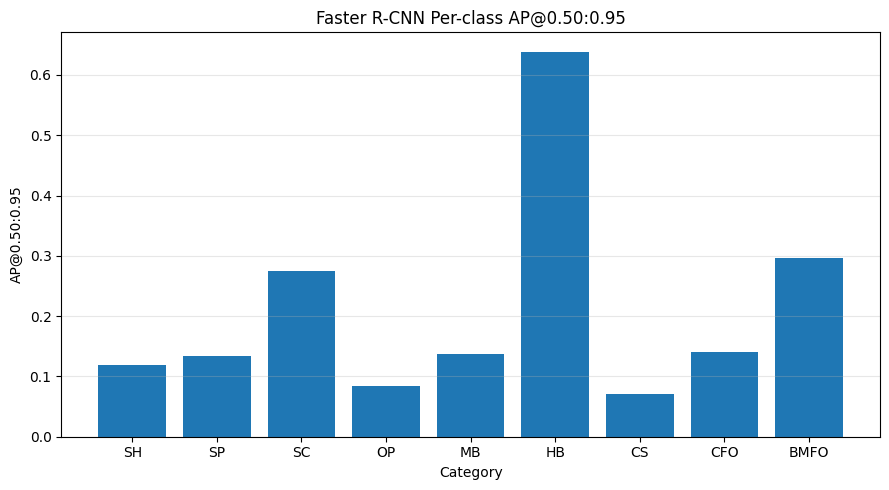

Saved: /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/faster_rcnn_per_class_ap_chart.png


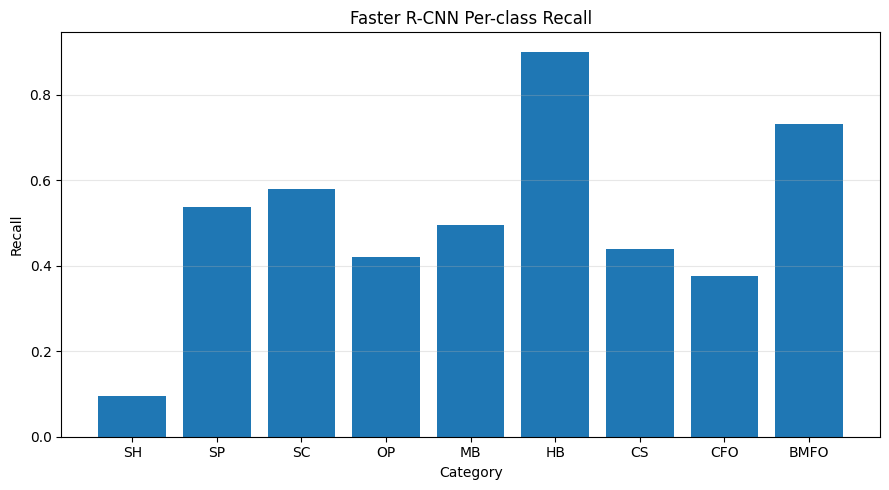

Saved: /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/faster_rcnn_per_class_recall_chart.png


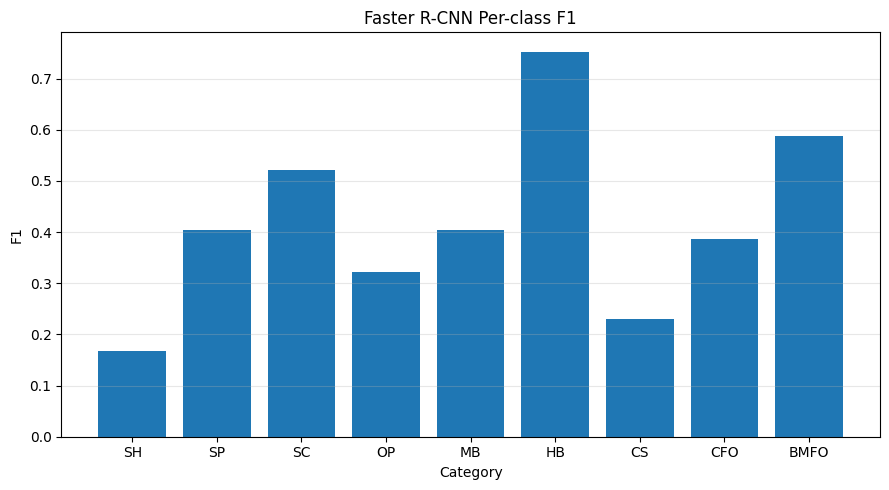

Saved: /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/faster_rcnn_per_class_f1_chart.png


In [16]:
# ============================
# Plot updated per-class AP / Recall / F1 charts
# (robust version: search AP file in both global and experiment metrics dirs)
# ============================
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
OUTPUT_ROOT = PROJECT_ROOT / "output"
CNN_OUTPUT_DIR = OUTPUT_ROOT / "cnn"

EXPERIMENT_NAME = "faster_rcnn_server_baseline_light_v1"
SERVER_EXP_DIR = CNN_OUTPUT_DIR / EXPERIMENT_NAME
SERVER_METRICS_DIR = SERVER_EXP_DIR / "metrics"
CNN_GLOBAL_METRICS_DIR = CNN_OUTPUT_DIR / "metrics"

# candidate paths
ap_candidates = [
    SERVER_METRICS_DIR / "faster_rcnn_per_class_ap.csv",
    CNN_GLOBAL_METRICS_DIR / "faster_rcnn_per_class_ap.csv",
]

prf_candidates = [
    SERVER_METRICS_DIR / "cnn_per_class_summary_with_f1.csv",
]

ap_path = next((p for p in ap_candidates if p.exists()), None)
prf_path = next((p for p in prf_candidates if p.exists()), None)

if ap_path is None:
    raise FileNotFoundError(
        "Missing AP file. Checked:\n- " + "\n- ".join(str(p) for p in ap_candidates)
    )

if prf_path is None:
    raise FileNotFoundError(
        "Missing PR/F1 file. Checked:\n- " + "\n- ".join(str(p) for p in prf_candidates)
    )

ap_df = pd.read_csv(ap_path)
prf_df = pd.read_csv(prf_path)

print("Loaded AP table from   :", ap_path)
print("Loaded PR/F1 table from:", prf_path)

print("\n=== AP table columns ===")
print(ap_df.columns.tolist())

print("\n=== PR/F1 table columns ===")
print(prf_df.columns.tolist())

# keep needed columns
ap_keep_cols = [c for c in ["category_id", "category_name", "ap_50_95", "mar_100"] if c in ap_df.columns]
prf_keep_cols = [c for c in ["category_id", "category_name", "precision", "recall", "f1", "tp", "fp", "fn"] if c in prf_df.columns]

ap_df_small = ap_df[ap_keep_cols].copy()
prf_df_small = prf_df[prf_keep_cols].copy()

if "category_name" in prf_df_small.columns:
    prf_df_small = prf_df_small.drop(columns=["category_name"])

plot_df = ap_df_small.merge(prf_df_small, on="category_id", how="left")

if "category_name" not in plot_df.columns and "category_name" in prf_df.columns:
    plot_df = plot_df.merge(
        prf_df[["category_id", "category_name"]].drop_duplicates(),
        on="category_id",
        how="left"
    )

plot_df = plot_df.sort_values("category_id").reset_index(drop=True)

print("\n=== Plot dataframe ===")
display(plot_df)

# 1) AP chart
if "ap_50_95" in plot_df.columns:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(plot_df["category_name"], plot_df["ap_50_95"])
    ax.set_title("Faster R-CNN Per-class AP@0.50:0.95")
    ax.set_xlabel("Category")
    ax.set_ylabel("AP@0.50:0.95")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()

    ap_chart_path = SERVER_METRICS_DIR / "faster_rcnn_per_class_ap_chart.png"
    plt.savefig(ap_chart_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", ap_chart_path)
else:
    print("Column 'ap_50_95' not found, so AP chart was skipped.")

# 2) Recall chart
if "recall" in plot_df.columns:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(plot_df["category_name"], plot_df["recall"])
    ax.set_title("Faster R-CNN Per-class Recall")
    ax.set_xlabel("Category")
    ax.set_ylabel("Recall")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()

    recall_chart_path = SERVER_METRICS_DIR / "faster_rcnn_per_class_recall_chart.png"
    plt.savefig(recall_chart_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", recall_chart_path)
else:
    print("Column 'recall' not found, so Recall chart was skipped.")

# 3) F1 chart
if "f1" in plot_df.columns:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(plot_df["category_name"], plot_df["f1"])
    ax.set_title("Faster R-CNN Per-class F1")
    ax.set_xlabel("Category")
    ax.set_ylabel("F1")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()

    f1_chart_path = SERVER_METRICS_DIR / "faster_rcnn_per_class_f1_chart.png"
    plt.savefig(f1_chart_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", f1_chart_path)
else:
    print("Column 'f1' not found, so F1 chart was skipped.")

### Faster R-CNN 每类 AP、Recall 与 F1 可视化分析

从每类指标表和对应柱状图可以看出，当前 Faster R-CNN baseline 在不同类别上的表现差异非常明显，而且这种差异在 AP、Recall 和 F1 三个维度上是一致存在的。首先，`HB` 是最突出的优势类别。它不仅在 `AP@0.50:0.95` 上达到最高值 `0.6387`，同时在 `Recall = 0.9013` 和 `F1 = 0.7527` 上也明显领先于其他类别。这说明 `HB` 不仅更容易被模型正确识别，而且定位和类别判断也相对稳定，是当前模型学习最成功的缺陷类型。

除 `HB` 之外，`BMFO` 和 `SC` 也表现较好。`BMFO` 的 `AP@0.50:0.95 = 0.2956`、`Recall = 0.7312`、`F1 = 0.5877`，而 `SC` 的 `AP@0.50:0.95 = 0.2741`、`Recall = 0.5789`、`F1 = 0.5222`。这说明这两个类别虽然不像 `HB` 那样强，但已经具备了较好的可检测性。特别是 `BMFO`，其 recall 较高，说明模型对该类目标覆盖较充分；而 `SC` 则在 precision、recall 和 F1 上表现相对均衡，说明该类缺陷的检测稳定性比弱类更好。

相比之下，`SH`、`OP` 和 `CS` 的表现明显较弱。`SH` 的 `AP@0.50:0.95 = 0.1182`，虽然 precision 很高，但 recall 只有 `0.0947`，导致 `F1 = 0.1675`。这说明模型对 `SH` 的预测非常保守：一旦预测出来通常是对的，但大部分真实目标都没有被检出。`CS` 则呈现出另外一种失败模式，它的 recall 并不算最低（`0.4397`），但 precision 非常低（`0.1566`），导致 `F1 = 0.2310`。这说明模型会频繁给出 `CS` 相关预测，但其中很多是误检，表明该类别很可能和背景结构或其他类别存在明显混淆。`OP` 的整体表现也偏弱，说明该类既存在漏检，也存在误检。

这些图形结果与前面的定量评估和错误样本分析相互印证。整体来看，当前 Faster R-CNN baseline 更擅长处理视觉模式较稳定、结构更突出的类别，而对小目标、类别边界不清晰或视觉相似度较高的类别表现较弱。因此，这组图不仅是结果展示，更为后续与 YOLO 的类别级对比提供了非常清晰的参照基础。

### Analysis of Faster R-CNN Per-class AP, Recall, and F1 Visualisations

The per-class metric table and bar charts clearly show that the current Faster R-CNN baseline behaves very differently across categories, and this variation is consistently reflected in AP, Recall, and F1. `HB` is the strongest class by a large margin. It achieves the highest `AP@0.50:0.95` at `0.6387`, while also leading in `Recall = 0.9013` and `F1 = 0.7527`. This indicates that `HB` is not only easier for the detector to recognise, but also more stable in localisation and classification, making it the most successfully learned defect category in the current model.

Beyond `HB`, `BMFO` and `SC` also perform relatively well. `BMFO` reaches `AP@0.50:0.95 = 0.2956`, `Recall = 0.7312`, and `F1 = 0.5877`, while `SC` reaches `AP@0.50:0.95 = 0.2741`, `Recall = 0.5789`, and `F1 = 0.5222`. These values suggest that both classes are already reasonably detectable, even though they are still clearly below `HB`. In particular, `BMFO` benefits from relatively strong recall, meaning that the model covers many true instances of this class, while `SC` appears more balanced across precision, recall, and F1.

In contrast, `SH`, `OP`, and `CS` remain clearly weak classes. `SH` has `AP@0.50:0.95 = 0.1182`, and although its precision is high, its recall is only `0.0947`, resulting in `F1 = 0.1675`. This suggests that the detector is extremely conservative on `SH`: when it predicts the class, it is often correct, but it fails to detect most real `SH` instances. `CS` shows a different failure pattern. Its recall is not the lowest (`0.4397`), but its precision is extremely low (`0.1566`), which reduces its `F1` to `0.2310`. This implies that the detector frequently produces `CS` predictions, but many of them are false positives, indicating strong confusion with background structures or visually similar categories. `OP` also remains weak overall, suggesting that it suffers from both missed detections and false alarms.

These visual results are fully consistent with the earlier quantitative evaluation and qualitative error analysis. Overall, the current Faster R-CNN baseline performs best on visually stable and distinctive defect categories, while it remains much weaker on small objects, subtle defect types, or classes with stronger visual ambiguity. Therefore, these figures do not only serve as result presentation, but also provide a strong foundation for later class-level comparison with YOLO.

In [18]:
# ============================
# Rebuild and update global overall/per-class summary tables for CNN
# (fixed version)
# ============================
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
OUTPUT_ROOT = PROJECT_ROOT / "output"
CNN_OUTPUT_DIR = OUTPUT_ROOT / "cnn"

EXPERIMENT_NAME = "faster_rcnn_server_baseline_light_v1"
SERVER_EXP_DIR = CNN_OUTPUT_DIR / EXPERIMENT_NAME
SERVER_METRICS_DIR = SERVER_EXP_DIR / "metrics"
CNN_GLOBAL_METRICS_DIR = CNN_OUTPUT_DIR / "metrics"

# ----------------------------
# Source files
# ----------------------------
overall_ap_metrics_path = CNN_GLOBAL_METRICS_DIR / "faster_rcnn_overall_metrics.csv"
overall_prf_path = SERVER_METRICS_DIR / "faster_rcnn_overall_prf.csv"

per_class_ap_path = CNN_GLOBAL_METRICS_DIR / "faster_rcnn_per_class_ap.csv"
per_class_prf_path = SERVER_METRICS_DIR / "faster_rcnn_per_class_prf.csv"

for p in [overall_ap_metrics_path, overall_prf_path, per_class_ap_path, per_class_prf_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

# ----------------------------
# Load source tables
# ----------------------------
overall_ap_df = pd.read_csv(overall_ap_metrics_path)
overall_prf_df = pd.read_csv(overall_prf_path)

per_class_ap_df = pd.read_csv(per_class_ap_path)
per_class_prf_df = pd.read_csv(per_class_prf_path)

print("Loaded:")
print("overall AP metrics :", overall_ap_metrics_path)
print("overall PRF        :", overall_prf_path)
print("per-class AP       :", per_class_ap_path)
print("per-class PRF      :", per_class_prf_path)

print("\n=== overall_ap_df ===")
display(overall_ap_df)

print("\n=== overall_prf_df ===")
display(overall_prf_df)

print("\n=== per_class_ap_df ===")
display(per_class_ap_df)

print("\n=== per_class_prf_df ===")
display(per_class_prf_df)

# ----------------------------
# Rebuild CNN overall summary
# ----------------------------
cnn_overall_summary_df = overall_ap_df.merge(
    overall_prf_df,
    on=["model_name", "experiment_name"],
    how="left"
)

cnn_overall_summary_path = SERVER_METRICS_DIR / "cnn_overall_summary_with_f1.csv"
cnn_overall_summary_df.to_csv(cnn_overall_summary_path, index=False)

# ----------------------------
# Rebuild CNN per-class summary
# ----------------------------
# avoid duplicated category_name after merge
per_class_prf_small = per_class_prf_df.drop(columns=["category_name"], errors="ignore")

cnn_per_class_summary_df = per_class_ap_df.merge(
    per_class_prf_small,
    on="category_id",
    how="left"
)

# reorder columns if present
preferred_cols = [
    "category_id",
    "category_name",
    "ap_50_95",
    "mar_100",
    "tp",
    "fp",
    "fn",
    "precision",
    "recall",
    "f1",
]
existing_cols = [c for c in preferred_cols if c in cnn_per_class_summary_df.columns]
remaining_cols = [c for c in cnn_per_class_summary_df.columns if c not in existing_cols]
cnn_per_class_summary_df = cnn_per_class_summary_df[existing_cols + remaining_cols]

cnn_per_class_summary_path = SERVER_METRICS_DIR / "cnn_per_class_summary_with_f1.csv"
cnn_per_class_summary_df.to_csv(cnn_per_class_summary_path, index=False)

# ----------------------------
# Update global overall summary
# ----------------------------
global_overall_path = OUTPUT_ROOT / "overall_metrics_summary.csv"

if global_overall_path.exists():
    old_overall = pd.read_csv(global_overall_path)
    new_overall = pd.concat([old_overall, cnn_overall_summary_df], ignore_index=True)
    new_overall = new_overall.drop_duplicates(subset=["experiment_name", "model_name"], keep="last")
else:
    new_overall = cnn_overall_summary_df.copy()

new_overall.to_csv(global_overall_path, index=False)

# ----------------------------
# Update global per-class summary
# ----------------------------
global_per_class_path = OUTPUT_ROOT / "per_class_metrics_summary.csv"

per_class_rows = cnn_per_class_summary_df.copy()
per_class_rows["model_name"] = "fasterrcnn_resnet50_fpn"
per_class_rows["experiment_name"] = EXPERIMENT_NAME

if global_per_class_path.exists():
    old_pc = pd.read_csv(global_per_class_path)
    new_pc = pd.concat([old_pc, per_class_rows], ignore_index=True)
    new_pc = new_pc.drop_duplicates(subset=["experiment_name", "model_name", "category_id"], keep="last")
else:
    new_pc = per_class_rows.copy()

new_pc.to_csv(global_per_class_path, index=False)

print("\nSaved rebuilt CNN summary tables:")
print(cnn_overall_summary_path)
print(cnn_per_class_summary_path)

print("\nUpdated global summary files:")
print(global_overall_path)
print(global_per_class_path)

print("\n=== Rebuilt CNN overall summary ===")
display(cnn_overall_summary_df)

print("\n=== Rebuilt CNN per-class summary ===")
display(cnn_per_class_summary_df)

print("\n=== Global overall summary ===")
display(new_overall.tail(10))

print("\n=== Global per-class summary ===")
display(new_pc.tail(20))

Loaded:
overall AP metrics : /root/AIDL/output/cnn/metrics/faster_rcnn_overall_metrics.csv
overall PRF        : /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/faster_rcnn_overall_prf.csv
per-class AP       : /root/AIDL/output/cnn/metrics/faster_rcnn_per_class_ap.csv
per-class PRF      : /root/AIDL/output/cnn/faster_rcnn_server_baseline_light_v1/metrics/faster_rcnn_per_class_prf.csv

=== overall_ap_df ===


,model_name,experiment_name,map_50,map_50_95,mar_100,inference_time_per_image_sec,num_test_images,num_parameters,model_file_size_mb
0,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,0.432425,0.21044,0.411064,0.008989,2051,41393281,316.1851



=== overall_prf_df ===


,model_name,experiment_name,conf_thresh,iou_match_thresh,tp,fp,fn,precision,recall,f1
0,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,0.3,0.5,2251,4023,1841,0.358782,0.550098,0.434304



=== per_class_ap_df ===


...

,category_id,category_name,ap_50_95,mar_100,tp,fp,fn,precision,recall,f1
0,1,SH,0.118159,0.357988,16,6,153,0.727273,0.094675,0.167539
1,2,SP,0.133423,0.329171,500,1047,429,0.323206,0.538213,0.403877
2,3,SC,0.274126,0.495789,165,182,120,0.475504,0.578947,0.522152
3,4,OP,0.084765,0.328994,142,400,196,0.261993,0.420118,0.322727
4,5,MB,0.137726,0.317766,271,526,275,0.340025,0.496337,0.403574
5,6,HB,0.638719,0.750000,548,300,60,0.646226,0.901316,0.752747
6,7,CS,0.070346,0.315179,197,1061,251,0.156598,0.439732,0.230950
7,8,CFO,0.141056,0.352955,159,239,264,0.399497,0.375887,0.387333
8,9,BMFO,0.295643,0.451734,253,262,93,0.491262,0.731214,0.587689



=== Global overall summary ===


,model_name,experiment_name,map_50,map_50_95,mar_100,inference_time_per_image_sec,num_test_images,num_parameters,model_file_size_mb,conf_thresh,iou_match_thresh,tp,fp,fn,precision,recall,f1
1,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,0.432425,0.21044,0.411064,0.008989,2051.0,41393281.0,316.1851,0.3,0.5,2251.0,4023.0,1841.0,0.358782,0.550098,0.434304



=== Global per-class summary ===


,category_id,category_name,ap_50_95,mar_100,model_name,experiment_name,tp,fp,fn,precision,recall,f1
9,1,SH,0.118159,0.357988,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,16.0,6.0,153.0,0.727273,0.094675,0.167539
10,2,SP,0.133423,0.329171,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,500.0,1047.0,429.0,0.323206,0.538213,0.403877
11,3,SC,0.274126,0.495789,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,165.0,182.0,120.0,0.475504,0.578947,0.522152
12,4,OP,0.084765,0.328994,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,142.0,400.0,196.0,0.261993,0.420118,0.322727
13,5,MB,0.137726,0.317766,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,271.0,526.0,275.0,0.340025,0.496337,0.403574
14,6,HB,0.638719,0.750000,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,548.0,300.0,60.0,0.646226,0.901316,0.752747
15,7,CS,0.070346,0.315179,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,197.0,1061.0,251.0,0.156598,0.439732,0.230950
16,8,CFO,0.141056,0.352955,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,159.0,239.0,264.0,0.399497,0.375887,0.387333
17,9,BMFO,0.295643,0.451734,fasterrcnn_resnet50_fpn,faster_rcnn_server_baseline_light_v1,253.0,262.0,93.0,0.491262,0.731214,0.587689


### CNN 汇总结果表重建与整理分析

当前重建后的 CNN 汇总结果表已经恢复完整，说明 Faster R-CNN baseline 的整体指标与固定阈值下的 Precision / Recall / F1 指标已经被成功整合到统一结果表中。`cnn_overall_summary_with_f1.csv` 现在同时包含 `mAP@0.50`、`mAP@0.50:0.95`、`mAR@100`、推理时间、参数量、模型大小，以及固定 operating point 下的 `TP`、`FP`、`FN`、`Precision`、`Recall` 和 `F1`。这意味着当前 CNN 模型的结果已经具备了完整的“检测质量 + 工程代价 + 误检漏检统计”三层信息，能够直接支持后续与 YOLO 的横向比较。

从整体结果来看，当前 Faster R-CNN baseline 的主要特征已经相当清晰：在 COCO 风格指标下，模型取得了 `mAP@0.50 = 0.4324` 和 `mAP@0.50:0.95 = 0.2104`，说明模型已经具备中等程度的缺陷检测能力，但在更严格的 IoU 条件下定位精度仍然有限；在固定阈值评估下，模型表现为 `Precision = 0.3588`、`Recall = 0.5501`、`F1 = 0.4343`，说明该模型当前更偏向于提高检出率，而不是严格抑制误检。这种“recall 高于 precision”的特征与前面的错误分析是一致的，即模型并不是检测不到目标，而是在一些图像中会给出较多冗余预测。

类别级结果表也已经完整对齐。当前每个类别都同时具有 `AP@0.50:0.95`、`mAR@100`、`Precision`、`Recall` 和 `F1`，因此后续不仅可以比较哪些类别更容易检测，还可以进一步区分这些类别到底是因为“漏检严重”表现差，还是因为“误检过多”表现差。例如，`HB` 仍然是最强类别，而 `SH`、`CS` 等弱类则展现出明显不同的失败模式。这类表格对于后续报告撰写非常关键，因为它使得 CNN 结果不再只是单一总体分数，而是已经具备了完整的类别级解释能力。

综合来看，到这一阶段为止，Faster R-CNN baseline 的训练、正式评估、错误分析、结果汇总与图表整理都已经基本完成。后续 CNN 部分不再需要继续补充新的基础实验，而是可以直接作为与 YOLO 对比的 two-stage baseline 使用。

### Analysis of the Rebuilt CNN Summary Tables

The rebuilt CNN summary tables are now complete and internally consistent, which means that the Faster R-CNN baseline results have been successfully consolidated into a unified format. The file `cnn_overall_summary_with_f1.csv` now contains both COCO-style evaluation metrics and fixed-threshold operating-point statistics, including `mAP@0.50`, `mAP@0.50:0.95`, `mAR@100`, inference time, parameter count, model size, as well as `TP`, `FP`, `FN`, `Precision`, `Recall`, and `F1`. This is important because it provides a full three-layer view of the model: detection quality, engineering cost, and error-count-based behaviour. As a result, the CNN baseline is now ready for later comparison with YOLO in a consistent way.

At the overall level, the baseline behaviour is now clearly defined. Under COCO-style evaluation, the model achieved `mAP@0.50 = 0.4324` and `mAP@0.50:0.95 = 0.2104`, showing that it has learned meaningful detection capability but still suffers from limited localisation quality under stricter IoU thresholds. Under the fixed operating-point evaluation, it achieved `Precision = 0.3588`, `Recall = 0.5501`, and `F1 = 0.4343`. This indicates that the current Faster R-CNN baseline is more recall-oriented than precision-oriented: it tends to recover more targets, but also produces a substantial number of false positives. This is fully consistent with the earlier qualitative error analysis.

The rebuilt per-class summary is also now complete. Each category contains `AP@0.50:0.95`, `mAR@100`, `Precision`, `Recall`, and `F1`, which means that later analysis can go beyond simply identifying strong and weak classes. It is now possible to distinguish whether a weak class performs poorly mainly missed detections or because of frequent false positives. For example, `HB` remains the strongest class, while weaker classes such as `SH` and `CS` show clearly different failure patterns. This type of class-level summary will be highly valuable in the final report, because it provides a much more interpretable foundation than relying on overall scores alone.

Overall, at this stage, the Faster R-CNN baseline can be considered fully prepared as a two-stage comparison model. Training, formal evaluation, error analysis, result consolidation, and per-class visualisation have all been completed to a sufficient level for coursework purposes. Therefore, the CNN side no longer needs additional foundational analysis, and the next major step can shift to YOLO training and later cross-model comparison.